# Lección 14.1 · El gen 16S rRNA y las variantes de secuencia de amplicón (ASVs)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-14-metagenomica/14.1_16s_asv.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 14 — Metagenómica y microbioma** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 2.1 y 6.2 (FASTQ, calidad Phred, errores esperados), 5.1 (filogenia), 8.1 ($k$-mers); NumPy y pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué el gen del ARNr 16S funciona como "código de barras" de bacterias y arqueas, **localizar** sus nueve
   regiones hipervariables en coordenadas de *E. coli* y **medir** su variabilidad con secuencias reales.
2. **Evaluar** un par de cebadores (515F/806R) con una PCR *in silico* y **razonar** sobre el número de copias del
   operón ribosómico (las siete copias del genoma de *E. coli* K-12).
3. **Agrupar** lecturas en **OTUs al 97 %** y **enumerar** sus defectos con una comunidad sintética (*mock*) de composición conocida.
4. **Derivar y calcular** el modelo de error $\lambda_{ji}$ y el **valor $p$ de abundancia** de DADA2, reproduciendo el
   ejemplo del libro «¿Error o variante a un nucleótido?».
5. **Programar desde cero** un *denoising* tipo DADA2 (filtrado por errores esperados, modelo de error aprendido de los
   datos, algoritmo divisivo, unión de pares y eliminación de bimeras) sobre lecturas **reales** MiSeq de heces de ratón.
6. **Asignar taxonomía** con el **clasificador bayesiano ingenuo de 8-mers** del RDP, con confianza por remuestreo,
   reproduciendo el ejemplo «Tres géneros y cuatro palabras».
7. **Producir** la tabla ASV × muestra y la taxonomía, que la Lección 14.2 (diversidad alfa y beta) usará para validar
   su propia tabla.

## 🗺️ Mapa de la clase

1. El censo por el apellido: qué problema resolvemos
2. Un reloj molecular universal: el 16S de *E. coli*, copia por copia
3. Regiones hipervariables y cebadores (perfil de variabilidad real y PCR *in silico*) — 📊 interactivo
4. 🧪 Datos reales: el MiSeq SOP (heces de ratón tras el destete + comunidad *mock*)
5. OTUs: agrupar al 97 %
6. De los errores a las variantes: la idea de DADA2 (ejemplo del libro) — 📊 interactivo
7. Filtrado previo: errores esperados
8. *Denoising* real desde cero: modelo de error, particiones (🎬 animación) y unión de pares
9. Quimeras y el ajuste de cuentas OTU frente a ASV
10. Asignación taxonómica: el clasificador bayesiano ingenuo (🎬 animación, 📊 interactivo)
11. QIIME 2 y la tabla final para la Lección 14.2
12. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, math, time, collections
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, FancyBboxPatch
from scipy import sparse, stats
from scipy.special import gammaln, gammainc, logsumexp

try:
    from Bio import Align
except ImportError:
    %pip install -q biopython
    from Bio import Align

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=90):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def course_text(name, **kw):
    b = course_bytes(name, **kw)
    return gzip.decompress(b).decode() if name.endswith(".gz") else b.decode()

BASES = "ACGT"
COMP = str.maketrans("ACGTRYSWKMBDHVN", "TGCAYRSWMKVHDBN")
def revcomp(s):
    return s.translate(COMP)[::-1]

IUPAC = {"A": "A", "C": "C", "G": "G", "T": "T", "R": "[AG]", "Y": "[CT]", "S": "[CG]", "W": "[AT]",
         "K": "[GT]", "M": "[AC]", "B": "[CGT]", "D": "[AGT]", "H": "[ACT]", "V": "[ACG]", "N": "[ACGT]"}
def primer_regex(p):
    """Convierte un cebador con códigos IUPAC (Y = C/T, M = A/C, …) en una expresión regular."""
    return re.compile("".join(IUPAC[c] for c in p))

T_START = time.time()
print("Listo para la Lección 14.1")

Entorno listo ✔  |  Colab: False


Listo para la Lección 14.1


## 1. El censo por el apellido: qué problema resolvemos

Imagine que debe hacer el censo de una ciudad enorme, pero nadie le abre la puerta. Lo único que puede hacer es recoger
las cartas que llegan a los buzones y anotar los apellidos de los destinatarios. Con suerte, cada familia tiene un
apellido distintivo; en la práctica, algunos apellidos se repiten entre familias no emparentadas, el cartero a veces
escribe mal un nombre ("Gonzales" por "González") y, de vez en cuando, dos sobres pegados producen un apellido compuesto
que no existe. Si se toma en serio cada grafía distinta, el censo inventará cientos de familias ficticias; si se agrupan
los apellidos "parecidos", se fundirán familias reales.

El análisis de amplicones del 16S enfrenta exactamente este dilema:

| En el censo | En el laboratorio | Qué haremos hoy |
|---|---|---|
| el apellido | un fragmento del gen del ARNr 16S (región V4, 253 nt) | leerlo con Illumina MiSeq 2 × 250 |
| las erratas del cartero | errores de PCR y de secuenciación | modelarlos y separarlos de la variación real (DADA2) |
| dos sobres pegados | **quimeras** de PCR | detectarlas como "bimeras" |
| agrupar apellidos parecidos | **OTUs** al 97 % | ver por qué funden familias reales e inventan otras |
| la guía telefónica | base de referencia (RDP, SILVA) | poner nombre a cada variante con un clasificador bayesiano |

**El caso práctico de hoy.** En un gramo de heces hay más células bacterianas que personas en el planeta, y la mayoría no
se ha cultivado nunca. Usaremos las lecturas públicas del **MiSeq SOP** de mothur (Kozich *et al.*, 2013): heces de un
ratón muestreadas en los días 0–9 después del destete (**tempranas**) y en los días 141–150 (**tardías**), secuenciadas
en la región V4 con los cebadores 515F/806R. La pregunta biológica es sencilla: ¿cambia la microbiota intestinal cuando
el ratón pasa de la leche materna a la dieta sólida y madura? Para saber si nuestros métodos dicen la verdad, la misma
corrida incluye una **comunidad *mock***: una mezcla artificial de ADN de 21 cepas conocidas (la *mock* del Human
Microbiome Project). Es nuestra prueba de fuego: cualquier "especie" que aparezca en ella y no esté en la lista es un
artefacto del método.

> 🤔 **Antes de seguir, prediga.** Si agrupamos las lecturas de la *mock* al 97 % de identidad, ¿obtendremos más, menos o
> exactamente 21 grupos? Anote su respuesta; la comprobaremos en la sección 5.

## 2. Un reloj molecular universal: el 16S de *E. coli*, copia por copia

Todo organismo celular necesita ribosomas, y todo ribosoma contiene ARN. En bacterias y arqueas, la subunidad pequeña
del ribosoma lleva un ARN de unos 1500 nucleótidos, el **ARNr 16S** (la "S" es la unidad Svedberg de sedimentación).
Tres propiedades lo convierten en un marcador casi ideal:

1. **Es universal**: está presente en todos los procariotas.
2. **Buena parte de su secuencia evoluciona muy lentamente**: su función (ensamblar el ribosoma y reconocer el ARNm) es
   tan antigua y tan restrictiva que un cambio en las zonas estructurales suele ser letal. Eso permite alinear genes de
   organismos separados por miles de millones de años.
3. **Intercaladas entre esas regiones conservadas hay regiones hipervariables** que evolucionan mucho más rápido y
   distinguen linajes cercanos.

Woese y Fox (1977) explotaron esta combinación. Sin secuenciadores automáticos, compararon catálogos de oligonucleótidos
del ARNr 16S digerido con ribonucleasa T1 y encontraron que los metanógenos, clasificados hasta entonces como bacterias,
eran tan distintos de las bacterias típicas como estas de los eucariotas: propusieron una tercera línea primordial de la
vida, las arqueas, y con ella el árbol de tres dominios. Tres décadas después, Caporaso *et al.* (2011) secuenciaron la
región V4 con Illumina a millones de lecturas por corrida, combinando cientos de muestras con códigos de barras en los
cebadores. Con tantas lecturas, los errores del secuenciador dejaron de ser una curiosidad y pasaron a ser **la principal
fuente de diversidad falsa**: de eso trata esta lección.

### 2.1 Encontrar el gen en un genoma real

El 16S de *Escherichia coli* se usa como **sistema de coordenadas de referencia**: mide **1542 nucleótidos**, y cuando un
artículo dice "cebador 515F" quiere decir "el cebador directo que empieza en la posición 515 del 16S de *E. coli*". Vamos a
sacar el gen directamente del genoma de *E. coli* K-12 MG1655 (NC_000913.3, que ya usamos en módulos anteriores). No
necesitamos anotaciones: basta buscar el cebador universal **27F** (`AGAGTTTGATCMTGGCTCAG`, que se une a las posiciones
8–27) en las dos hebras. Cada coincidencia marca el inicio de una copia del gen.

In [2]:
# Genoma de E. coli K-12 MG1655 (4,6 Mb) desde el repositorio del curso
genome = "".join(l.strip() for l in course_text("NC_000913.3.fasta.gz").splitlines() if not l.startswith(">"))
print(f"Genoma: {len(genome):,} pb")

F27 = "AGAGTTTGATCMTGGCTCAG"          # cebador 27F (posiciones 8-27 del 16S de E. coli)
copies = []
for strand, seq in (("+", genome), ("−", revcomp(genome))):
    for m in primer_regex(F27).finditer(seq):
        start = m.start() - 7                     # el gen empieza 7 nt antes del cebador
        gene = seq[start:start + 1542]
        pos = start + 1 if strand == "+" else len(genome) - start   # coordenada 1-based en la hebra +
        copies.append({"strand": strand, "start": pos, "gene": gene})
copies = sorted(copies, key=lambda c: c["start"])
ecoli16s = copies[0]["gene"]
print(f"Copias del 16S encontradas: {len(copies)}")
for k, c in enumerate(copies, 1):
    print(f"  copia {k}: hebra {c['strand']}  posición {c['start']:>9,}   extremo 3′ …{c['gene'][-14:]}")

Genoma: 4,641,652 pb
Copias del 16S encontradas: 7
  copia 1: hebra +  posición   223,771   extremo 3′ …GGATCACCTCCTTA
  copia 2: hebra −  posición 2,731,157   extremo 3′ …GGATCACCTCCTTA
  copia 3: hebra −  posición 3,428,762   extremo 3′ …GGATCACCTCCTTA
  copia 4: hebra +  posición 3,941,808   extremo 3′ …GGATCACCTCCTTA
  copia 5: hebra +  posición 4,035,531   extremo 3′ …GGATCACCTCCTTA
  copia 6: hebra +  posición 4,166,659   extremo 3′ …GGATCACCTCCTTA
  copia 7: hebra +  posición 4,208,147   extremo 3′ …GGATCACCTCCTTA


> 🔎 **Qué observamos.** El genoma de *E. coli* K-12 lleva **siete** copias del gen (los operones *rrnA*, *B*, *C*, *D*,
> *E*, *G* y *H*). Todas terminan en `GGATCACCTCCTTA`: el extremo 3′ del 16S,
> cuya secuencia `CCTCC` se aparea con la secuencia de Shine–Dalgarno del ARNm para iniciar la traducción. Nuestro
> recorte de 1542 nt es, por tanto, el gen completo.

¿Son idénticas las siete copias? Si difieren, **un solo organismo podría aportar más de una variante de secuencia**:
un problema muy concreto para quien quiere contar organismos a partir de secuencias exactas.

Posiciones que difieren entre las 7 copias: 23
V6            9
V1            5
conservada    4
V2            4
V7            1

Amplicón V4 (sin cebadores): 253 nt · secuencias distintas entre copias: 1


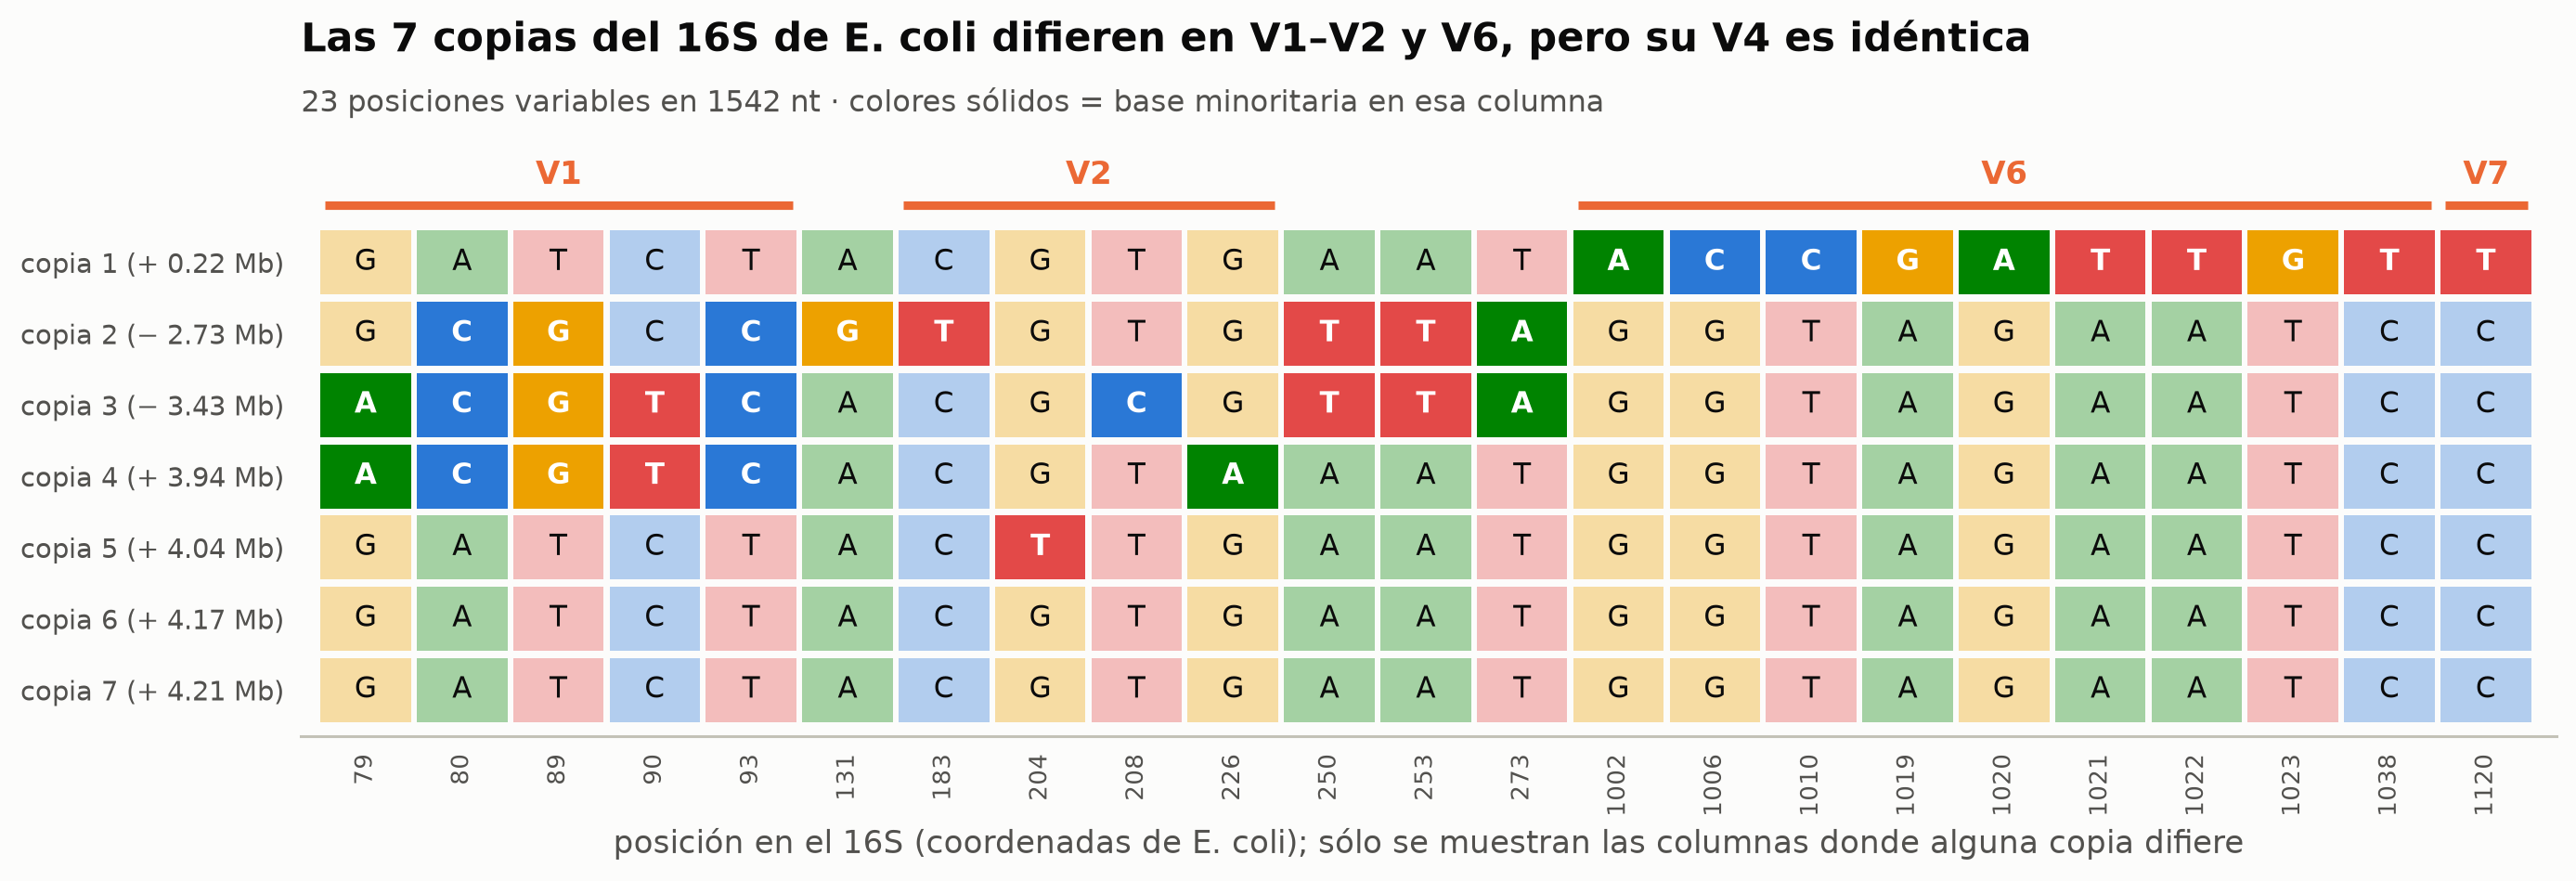

In [3]:
G = np.array([list(c["gene"]) for c in copies])
var_pos = np.where((G != G[0]).any(axis=0))[0]            # índices 0-based de columnas variables
V_REGIONS = {"V1": (69, 99), "V2": (137, 242), "V3": (433, 497), "V4": (576, 682), "V5": (822, 879),
             "V6": (986, 1043), "V7": (1117, 1173), "V8": (1243, 1294), "V9": (1435, 1465)}
def region_of(p):
    for v, (a, b) in V_REGIONS.items():
        if a <= p <= b:
            return v
    return "conservada"
print(f"Posiciones que difieren entre las 7 copias: {len(var_pos)}")
print(pd.Series([region_of(p + 1) for p in var_pos]).value_counts().to_string())

# El amplicón V4 (515F/806R sin cebadores) va de la posición 534 a la 786
v4_copies = [c["gene"][533:786] for c in copies]
print(f"\nAmplicón V4 (sin cebadores): {len(v4_copies[0])} nt · secuencias distintas entre copias: {len(set(v4_copies))}")

fig, ax = plt.subplots(figsize=(12.5, 4.2))
cols = {b: ec.NUC_COLORS[b] for b in "ACGT"}
for r in range(len(copies)):
    for k, p in enumerate(var_pos):
        b = G[r, p]
        same = b == pd.Series(G[:, p]).mode()[0]
        ax.add_patch(Rectangle((k, r), 0.94, 0.9, color=cols[b], alpha=0.35 if same else 1.0, lw=0))
        ax.text(k + 0.47, r + 0.45, b, ha="center", va="center", fontsize=10,
                color="white" if not same else ec.INK, fontweight="bold" if not same else "normal")
ax.set_xlim(-0.2, len(var_pos) + 0.2); ax.set_ylim(len(copies) + 0.1, -1.4)
ax.set_yticks(np.arange(len(copies)) + 0.45)
ax.set_yticklabels([f"copia {k+1} ({c['strand']} {c['start']/1e6:.2f} Mb)" for k, c in enumerate(copies)], fontsize=9.5)
ax.set_xticks(np.arange(len(var_pos)) + 0.47); ax.set_xticklabels(var_pos + 1, rotation=90, fontsize=8.5)
for v in ("V1", "V2", "V6", "V7"):
    ks = [k for k, p in enumerate(var_pos) if region_of(p + 1) == v]
    if ks:
        ax.plot([ks[0] + 0.05, ks[-1] + 0.9], [-0.35, -0.35], color=ec.ORANGE, lw=3, solid_capstyle="butt")
        ax.text((ks[0] + ks[-1] + 0.95) / 2, -0.55, v, ha="center", va="bottom", color=ec.ORANGE, fontweight="bold")
ax.set_xlabel("posición en el 16S (coordenadas de E. coli); sólo se muestran las columnas donde alguna copia difiere")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.grid(False)
ec.title(ax, "Las 7 copias del 16S de E. coli difieren en V1–V2 y V6, pero su V4 es idéntica",
         f"{len(var_pos)} posiciones variables en 1542 nt · colores sólidos = base minoritaria en esa columna")
plt.show()

> 🔎 **Qué observamos.** Las siete copias no son idénticas: difieren en una veintena de posiciones concentradas en las
> regiones hipervariables V1–V2 y V6. En cambio, el fragmento V4 que amplifican 515F/806R es **idéntico** en las siete.
> Con V4, *E. coli* K-12 produce **una sola** variante de secuencia; con V1–V3 produciría varias. Y hay una segunda
> consecuencia, más silenciosa: por cada célula de *E. coli* la PCR recibe **siete** moldes.

### 2.2 El número de copias distorsiona las abundancias

Un genoma bacteriano puede llevar entre una y más de una docena de copias del operón ribosómico. Ejemplo resuelto:
una muestra contiene **igual número de células** de *E. coli* (7 copias) y de una especie con 1 copia. La PCR "ve"
$7 + 1 = 8$ moldes por pareja de células, así que la tabla dirá:

$$\text{abundancia relativa de } E.\ coli = \frac{7}{7+1} = 87{,}5\,\%, \qquad \text{la otra} = \frac{1}{8} = 12{,}5\,\%,$$

aunque en células sean 50 % y 50 %. **Las abundancias de una tabla 16S son abundancias de genes, no de células.** Si
conociéramos el número de copias $c_k$ de cada taxón, la corrección sería dividir cada conteo por $c_k$ y renormalizar;
en la práctica $c_k$ es incierto para organismos no cultivados, y muchos estudios prefieren no corregir y comparar
**entre muestras** el mismo taxón, donde el sesgo se cancela.

> ✅ **Compruebe su comprensión.** Una tabla muestra 60 % de un taxón A (6 copias) y 40 % de un taxón B (2 copias).
> ¿Qué proporción de **células** hay de cada uno? *(Respuesta: 60/6 = 10 y 40/2 = 20 → A = 1/3, B = 2/3: la
> mayoría está invertida.)*

## 3. Regiones hipervariables y cebadores

Las lecturas cortas de Illumina (150–300 bases por extremo) no alcanzan para cubrir el gen completo, de modo que en la
práctica se amplifica una o dos regiones **hipervariables** contiguas con cebadores que se unen a las regiones
**conservadas** que las flanquean. El par **515F/806R** amplifica la región V4 (popularizado por Caporaso *et al.*,
2011); el par V3–V4 (≈ 341F/805R) produce un amplicón más largo, que requiere lecturas de 300 bases por extremo; el gen
completo (27F–1492R) sólo se lee con lecturas largas (PacBio HiFi, Nanopore).

### 3.1 Medir la variabilidad con secuencias reales

El libro dibuja un perfil **esquemático** de variabilidad. Aquí lo mediremos. Tomamos una secuencia 16S completa de cada
una de 560 familias bacterianas y arqueanas del conjunto de entrenamiento 18 del **RDP** (Ribosomal Database Project), y
alineamos una muestra de ellas contra el 16S de *E. coli* con un alineamiento global (Lección 3.2). Así cada base de cada
secuencia queda asignada a una posición de *E. coli*. En cada posición $\ell$ calculamos la **entropía de Shannon** de la
columna:

$$H(\ell) = -\sum_{b\in\{A,C,G,T,-\}} f_b(\ell)\,\log_2 f_b(\ell),$$

| Símbolo | Significado |
|---|---|
| $\ell$ | posición en el 16S, en coordenadas de *E. coli* (1–1542) |
| $f_b(\ell)$ | fracción de secuencias que tienen la base $b$ (o un hueco, "−") alineada a la posición $\ell$ |
| $H(\ell)$ | entropía en bits: 0 si todas las secuencias coinciden; hasta $\log_2 5 \approx 2{,}32$ si las cinco opciones son igual de frecuentes |

Ejemplo a mano: si en una columna 150 secuencias tienen G y 50 tienen A, $f_G = 0{,}75$, $f_A = 0{,}25$ y
$H = -(0{,}75\log_2 0{,}75 + 0{,}25\log_2 0{,}25) = 0{,}311 + 0{,}5 = 0{,}81$ bits.

> 🤔 **Antes de ejecutar, prediga.** ¿Dónde espera los picos de entropía? ¿Tendrá la región donde se une 515F
> (posiciones 515–533) entropía alta o baja?

In [4]:
# Panel: una secuencia 16S completa por familia (RDP, conjunto de entrenamiento 18)
panel = []
for line in course_text("141_rdp18_fulllength_families.fasta.gz").splitlines():
    if line.startswith(">"):
        acc, tax = line[1:].split(" ", 1)
        panel.append({"id": acc, "taxonomy": tax, "seq": ""})
    else:
        panel[-1]["seq"] += line.strip()
panel = pd.DataFrame(panel)
panel["domain"] = panel.taxonomy.str.split(";").str[0]
panel["phylum"] = panel.taxonomy.str.split(";").str[1]
print(f"{len(panel)} secuencias (una por familia) · dominios: {panel.domain.value_counts().to_dict()}")

aligner = Align.PairwiseAligner(mode="global", match_score=2, mismatch_score=-3,
                                open_gap_score=-5, extend_gap_score=-2)
aligner.end_gap_score = 0                         # extremos libres: las secuencias pueden estar recortadas

rng_panel = np.random.default_rng(141)
sub = panel.iloc[np.sort(rng_panel.choice(len(panel), 200, replace=False))]
t0 = time.time()
cols = np.full((len(sub), 1542), "-", dtype="<U1")   # base alineada a cada posición de E. coli
for r, s in enumerate(sub.seq):
    aln = aligner.align(ecoli16s, s)[0]
    for (a0, a1), (b0, b1) in zip(*aln.aligned):      # bloques alineados sin huecos
        cols[r, a0:a1] = np.array(list(s[b0:b1]))
# en los extremos recortados no hay información: los marcamos como faltantes
covered = np.zeros_like(cols, dtype=bool)
for r in range(len(sub)):
    idx = np.where(cols[r] != "-")[0]
    covered[r, idx.min():idx.max() + 1] = True
print(f"Alineadas {len(sub)} secuencias en {time.time() - t0:.1f} s")

entropy = np.zeros(1542)
for p in range(1542):
    c = cols[covered[:, p], p]
    _, n = np.unique(c, return_counts=True)
    f = n / n.sum()
    entropy[p] = -(f * np.log2(f)).sum()
smooth = np.convolve(entropy, np.ones(15) / 15, mode="same")
print(f"Entropía media en V4 (576-682): {entropy[575:682].mean():.2f} bits · en el sitio de 515F (515-533): "
      f"{entropy[514:533].mean():.2f} bits · en el de 806R (787-806): {entropy[786:806].mean():.2f} bits")

560 secuencias (una por familia) · dominios: {'Bacteria': 518, 'Archaea': 37, 'Eukaryota': 5}


Alineadas 200 secuencias en 9.7 s
Entropía media en V4 (576-682): 0.98 bits · en el sitio de 515F (515-533): 0.07 bits · en el de 806R (787-806): 0.12 bits


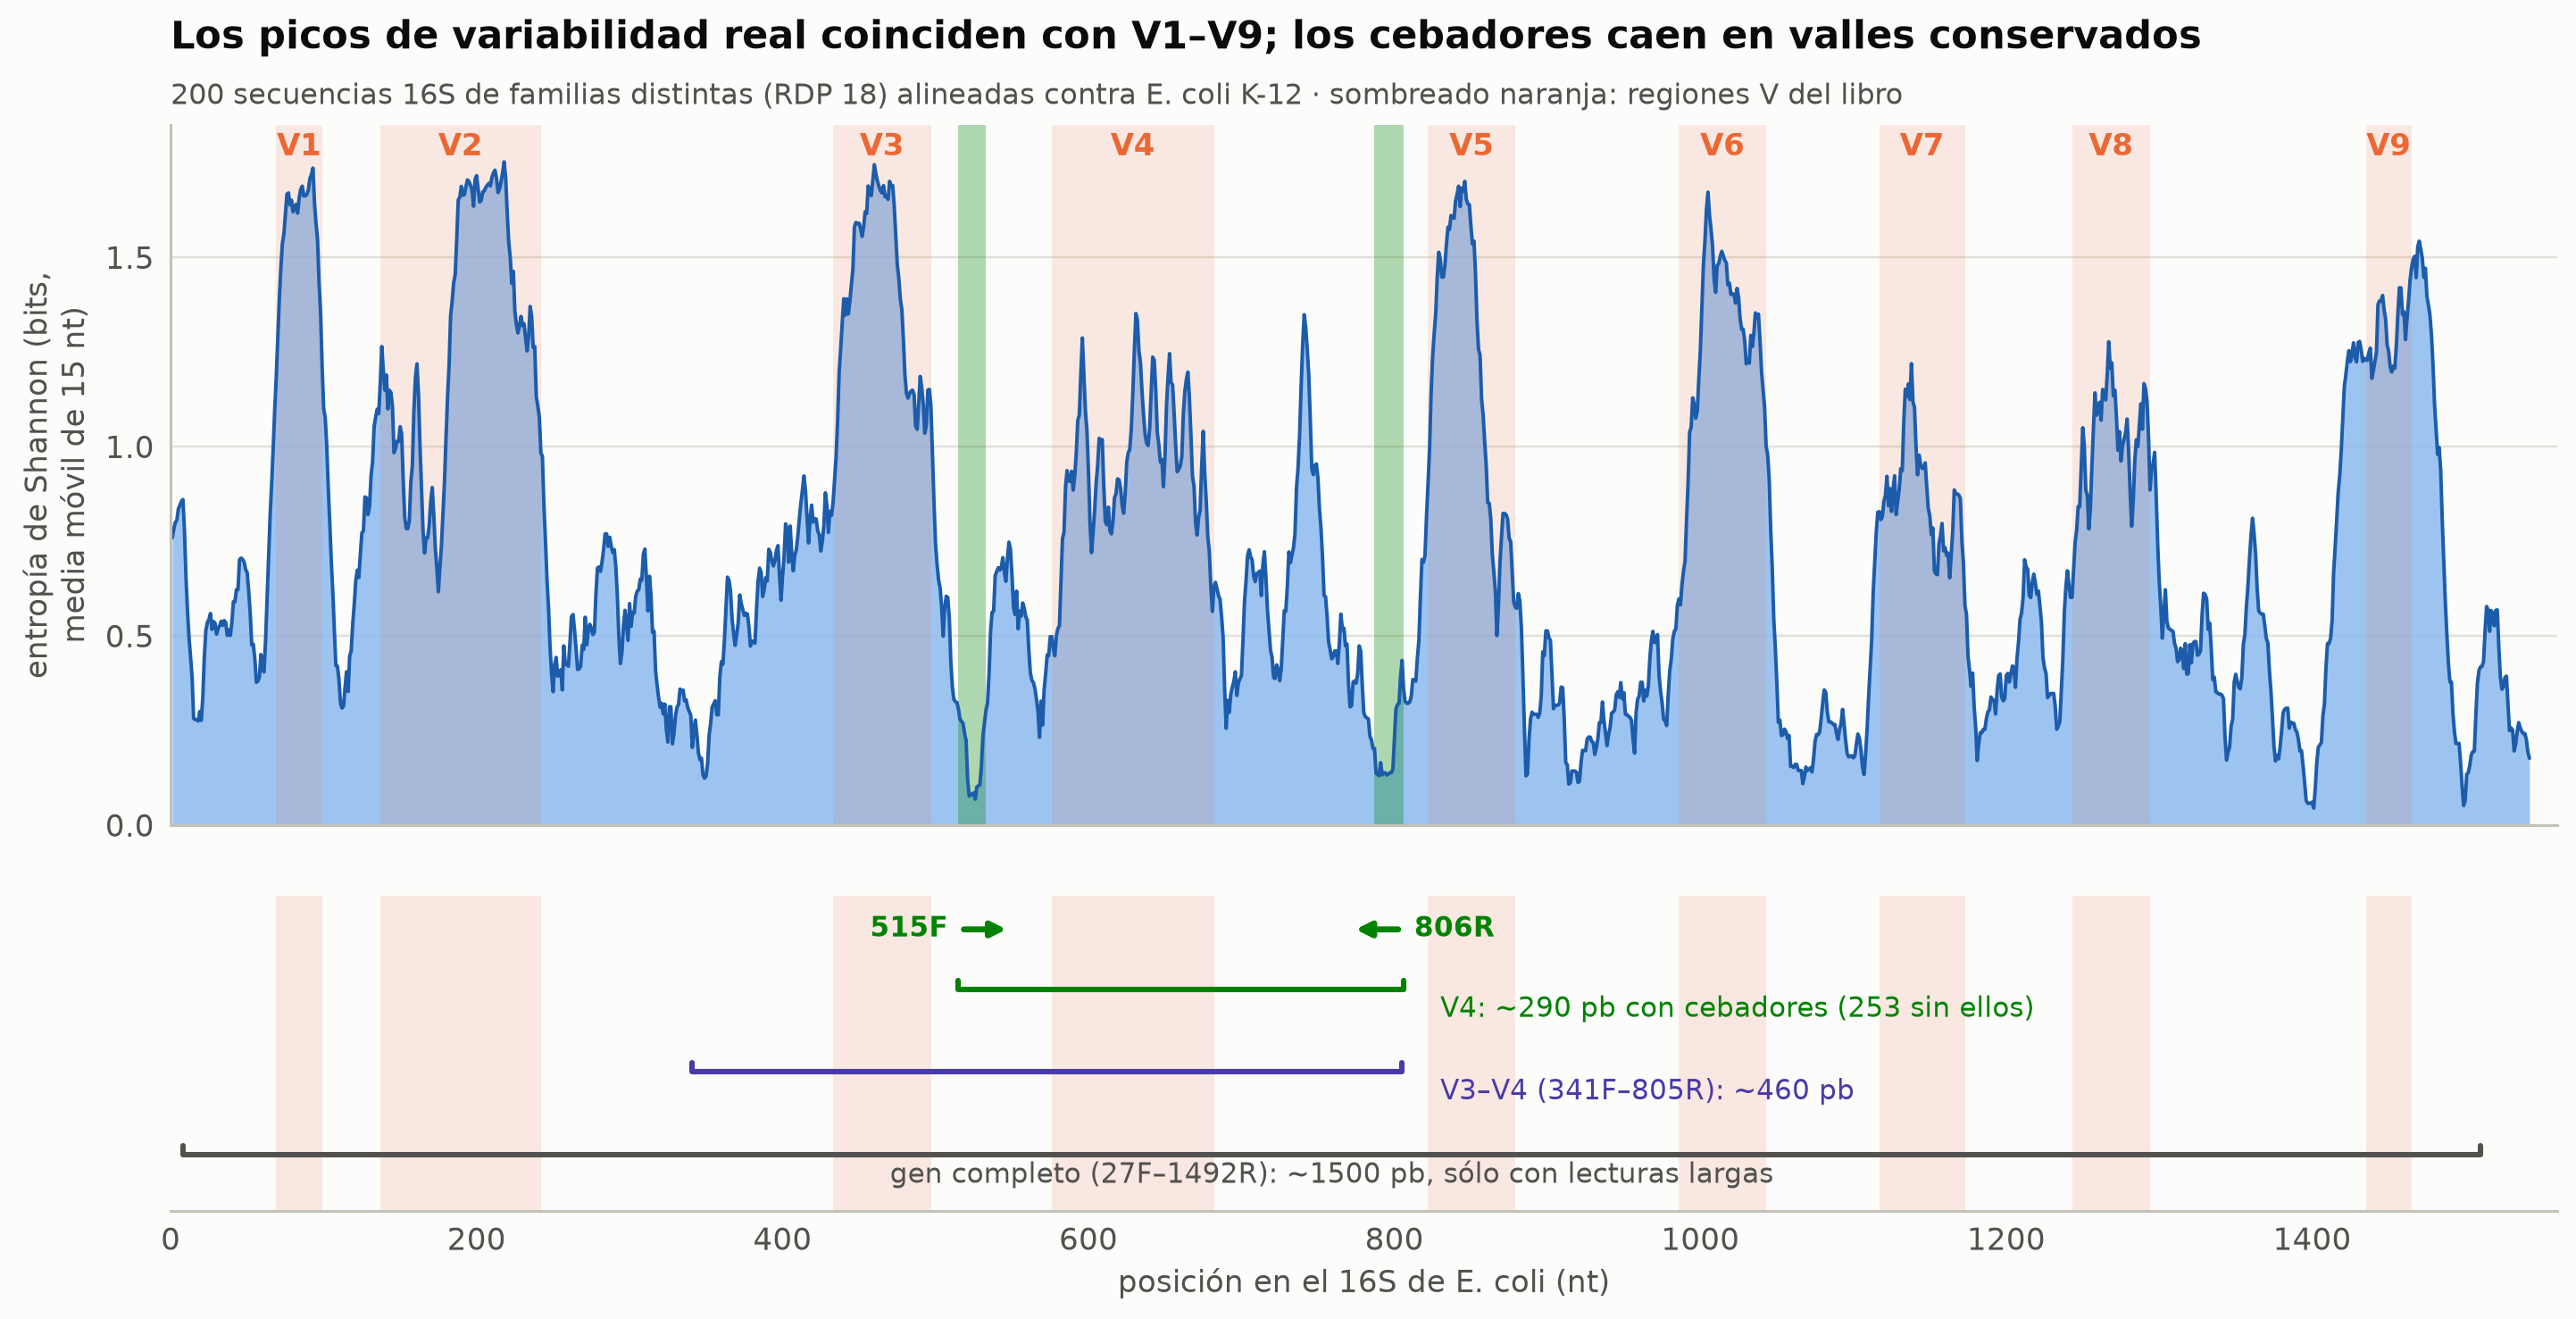

In [5]:
fig, (ax, axs) = plt.subplots(2, 1, figsize=(13, 6.6), sharex=True, gridspec_kw=dict(height_ratios=[3, 1.35], hspace=0.08))
x = np.arange(1, 1543)
ax.fill_between(x, 0, smooth, color=ec.SEQ_BLUE[3], alpha=0.8, lw=0)
ax.plot(x, smooth, color=ec.SEQ_BLUE[9], lw=1.3)
ytop = 1.85
for v, (a, b) in V_REGIONS.items():
    for axx in (ax, axs):
        axx.axvspan(a, b, color=ec.ORANGE, alpha=0.13, lw=0)
    ax.text((a + b) / 2, ytop - 0.02, v, ha="center", va="top", color=ec.ORANGE, fontweight="bold", fontsize=11)
for p0, p1 in ((515, 533), (787, 806)):
    ax.axvspan(p0, p1, color=ec.GREEN, alpha=0.3, lw=0)
ax.set_ylim(0, ytop); ax.set_yticks([0, 0.5, 1.0, 1.5])
ax.set_ylabel("entropía de Shannon (bits,\nmedia móvil de 15 nt)")
# esquema de cebadores y amplicones (panel inferior)
def bracket(x0, x1, y, color, label, lab_x=None, ha="center"):
    axs.plot([x0, x0, x1, x1], [y + 0.12, y, y, y + 0.12], color=color, lw=2)
    axs.text(lab_x if lab_x else (x0 + x1) / 2, y - 0.08, label, color=color, ha=ha, va="top", fontsize=10)
axs.annotate("", (550, 3.55), (515, 3.55), arrowprops=dict(arrowstyle="-|>", color=ec.GREEN, lw=2.2))
axs.annotate("", (771, 3.55), (806, 3.55), arrowprops=dict(arrowstyle="-|>", color=ec.GREEN, lw=2.2))
axs.text(508, 3.55, "515F", color=ec.GREEN, ha="right", va="center", fontsize=10, fontweight="bold")
axs.text(813, 3.55, "806R", color=ec.GREEN, ha="left", va="center", fontsize=10, fontweight="bold")
bracket(515, 806, 2.75, ec.GREEN, "V4: ~290 pb con cebadores (253 sin ellos)", lab_x=830, ha="left")
bracket(341, 805, 1.65, ec.VIOLET, "V3–V4 (341F–805R): ~460 pb", lab_x=830, ha="left")
bracket(8, 1510, 0.55, ec.INK_2, "gen completo (27F–1492R): ~1500 pb, sólo con lecturas largas")
axs.set_ylim(-0.2, 4.0); axs.set_yticks([])
for sp in ("left", "top", "right"): axs.spines[sp].set_visible(False)
axs.grid(False)
axs.set_xlim(0, 1560)
axs.set_xlabel("posición en el 16S de E. coli (nt)")
ec.title(ax, "Los picos de variabilidad real coinciden con V1–V9; los cebadores caen en valles conservados",
         f"{len(sub)} secuencias 16S de familias distintas (RDP 18) alineadas contra E. coli K-12 · sombreado naranja: regiones V del libro")
plt.show()

> 🔎 **Qué observamos.** La variabilidad real no es uniforme: se concentra en **picos** que caen dentro de las franjas
> V1–V9 (coordenadas del libro), separados por valles casi planos. Los sitios de unión de 515F y 806R están en valles
> (entropía muy baja): por eso un mismo par de cebadores amplifica a la mayoría de los procariotas. V4, entre ambos, tiene
> un pico moderado; V1–V2 y V6 son más variables, pero también menos conservados en los flancos. Elegir la región es un
> **compromiso**: una región más larga contiene más sitios informativos, pero exige lecturas más largas cuyo extremo 3′
> tiene peor calidad; una región corta se lee con precisión, pero puede no distinguir géneros cercanos.

El siguiente gráfico es interactivo: pase el cursor sobre el perfil para ver, en cada posición de *E. coli*, la base de
referencia, la entropía y la región.

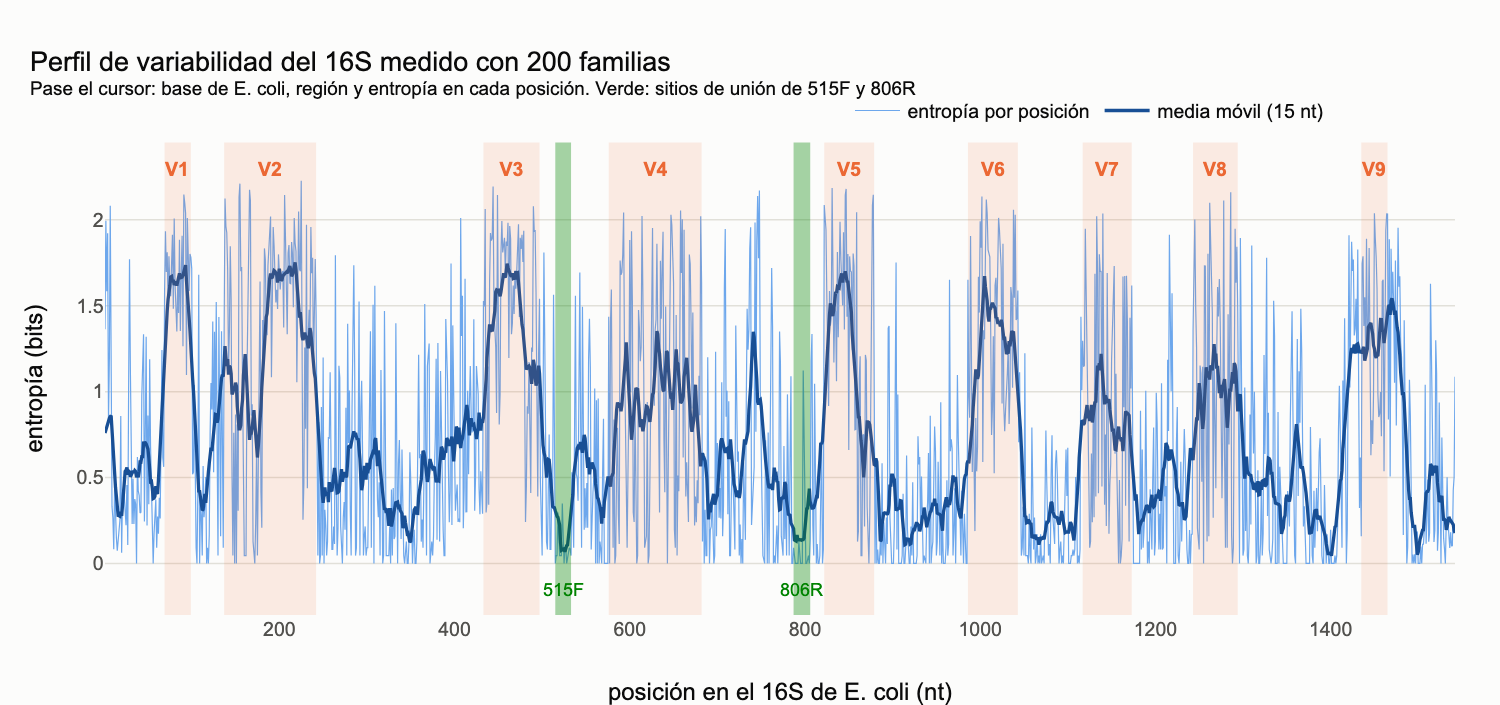

In [6]:
region_lab = np.array([region_of(p) for p in x])
ref_base = np.array(list(ecoli16s))
figp = go.Figure()
figp.add_trace(go.Scatter(
    x=x, y=entropy, mode="lines", line=dict(color=ec.SEQ_BLUE[4], width=0.8), name="entropía por posición",
    customdata=np.stack([ref_base, region_lab, smooth], axis=1),
    hovertemplate=("posición <b>%{x}</b> (E. coli: base %{customdata[0]})<br>región: <b>%{customdata[1]}</b>"
                   "<br>H = %{y:.2f} bits · media móvil %{customdata[2]:.2f}<extra></extra>")))
figp.add_trace(go.Scatter(x=x, y=smooth, mode="lines", line=dict(color=ec.SEQ_BLUE[10], width=2.2),
                          name="media móvil (15 nt)", hoverinfo="skip"))
for v, (a, b) in V_REGIONS.items():
    figp.add_vrect(x0=a, x1=b, fillcolor=ec.ORANGE, opacity=0.12, line_width=0)
    figp.add_annotation(x=(a + b) / 2, y=2.3, text=f"<b>{v}</b>", showarrow=False, font=dict(color=ec.ORANGE))
for p0, p1, lab in ((515, 533, "515F"), (787, 806, "806R")):
    figp.add_vrect(x0=p0, x1=p1, fillcolor=ec.GREEN, opacity=0.35, line_width=0)
    figp.add_annotation(x=(p0 + p1) / 2, y=-0.15, text=lab, showarrow=False, font=dict(color=ec.GREEN, size=12))
figp.update_layout(
    title="Perfil de variabilidad del 16S medido con 200 familias<br><sup>Pase el cursor: base de E. coli, región y "
          "entropía en cada posición. Verde: sitios de unión de 515F y 806R</sup>",
    xaxis_title="posición en el 16S de E. coli (nt)", yaxis_title="entropía (bits)", height=470,
    margin=dict(t=95, l=70, r=30, b=60), yaxis_range=[-0.3, 2.45],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.55))
figp.show()

### 3.2 PCR *in silico*: ¿son universales los cebadores?

Un cebador se une a su molde por complementariedad. Los cebadores "universales" llevan **bases degeneradas** (códigos
IUPAC) para tolerar la variación conocida: en `GTGYCAGCMGCCGCGGTAA`, `Y` significa C o T y `M` significa A o C, así que
el tubo contiene en realidad $2 \times 2 = 4$ oligonucleótidos distintos. El cebador reverso 806R se une a la hebra
complementaria, por lo que en el molde buscamos su **reverso complementario**.

Compararemos las versiones originales (Caporaso *et al.*, 2011) con las modificadas que hoy recomienda el Earth
Microbiome Project: **515F-Y** (Parada *et al.*, 2016), que añade la degeneración `Y` en la posición 4, y **806RB**
(Apprill *et al.*, 2015), que cambia `H` por `N`. Contamos qué fracción de las 560 familias contiene un sitio de unión
**exacto** (una aproximación estricta: en el tubo, uno o dos desajustes lejos del extremo 3′ a veces se toleran).

In [7]:
PRIMERS = {"515F (2011)": "GTGCCAGCMGCCGCGGTAA", "515F-Y (2016)": "GTGYCAGCMGCCGCGGTAA",
           "806R (2011)": "GGACTACHVGGGTWTCTAAT", "806RB (2015)": "GGACTACNVGGGTWTCTAAT"}
for name, p in PRIMERS.items():
    target = p if "515" in name else revcomp(p)          # 806R: se busca su reverso complementario
    panel[name] = panel.seq.str.contains(primer_regex(target).pattern, regex=True)
groups = {"Bacteria (todas)": panel.domain == "Bacteria", "Archaea (todas)": panel.domain == "Archaea"}
for ph in ["Proteobacteria", "Firmicutes", "Actinobacteria", "Bacteroidetes", "Cyanobacteria/Chloroplast",
           "Euryarchaeota", "Thaumarchaeota"]:
    groups[ph] = panel.phylum == ph
cov = pd.DataFrame({g: panel.loc[m, list(PRIMERS)].mean() * 100 for g, m in groups.items()}).T
cov["n familias"] = [int(m.sum()) for m in groups.values()]
print(cov.round(1).to_string())

                           515F (2011)  515F-Y (2016)  806R (2011)  806RB (2015)  n familias
Bacteria (todas)                  96.7           96.7         96.3          96.5         518
Archaea (todas)                   62.2           86.5         86.5          89.2          37
Proteobacteria                    98.9           98.9         98.3          98.9         180
Firmicutes                       100.0          100.0         96.9          96.9          65
Actinobacteria                    96.8           96.8         98.4          98.4          63
Bacteroidetes                    100.0          100.0        100.0         100.0          35
Cyanobacteria/Chloroplast        100.0          100.0         86.7          86.7          30
Euryarchaeota                     85.7           85.7        100.0         100.0          21
Thaumarchaeota                     0.0          100.0        100.0         100.0           2


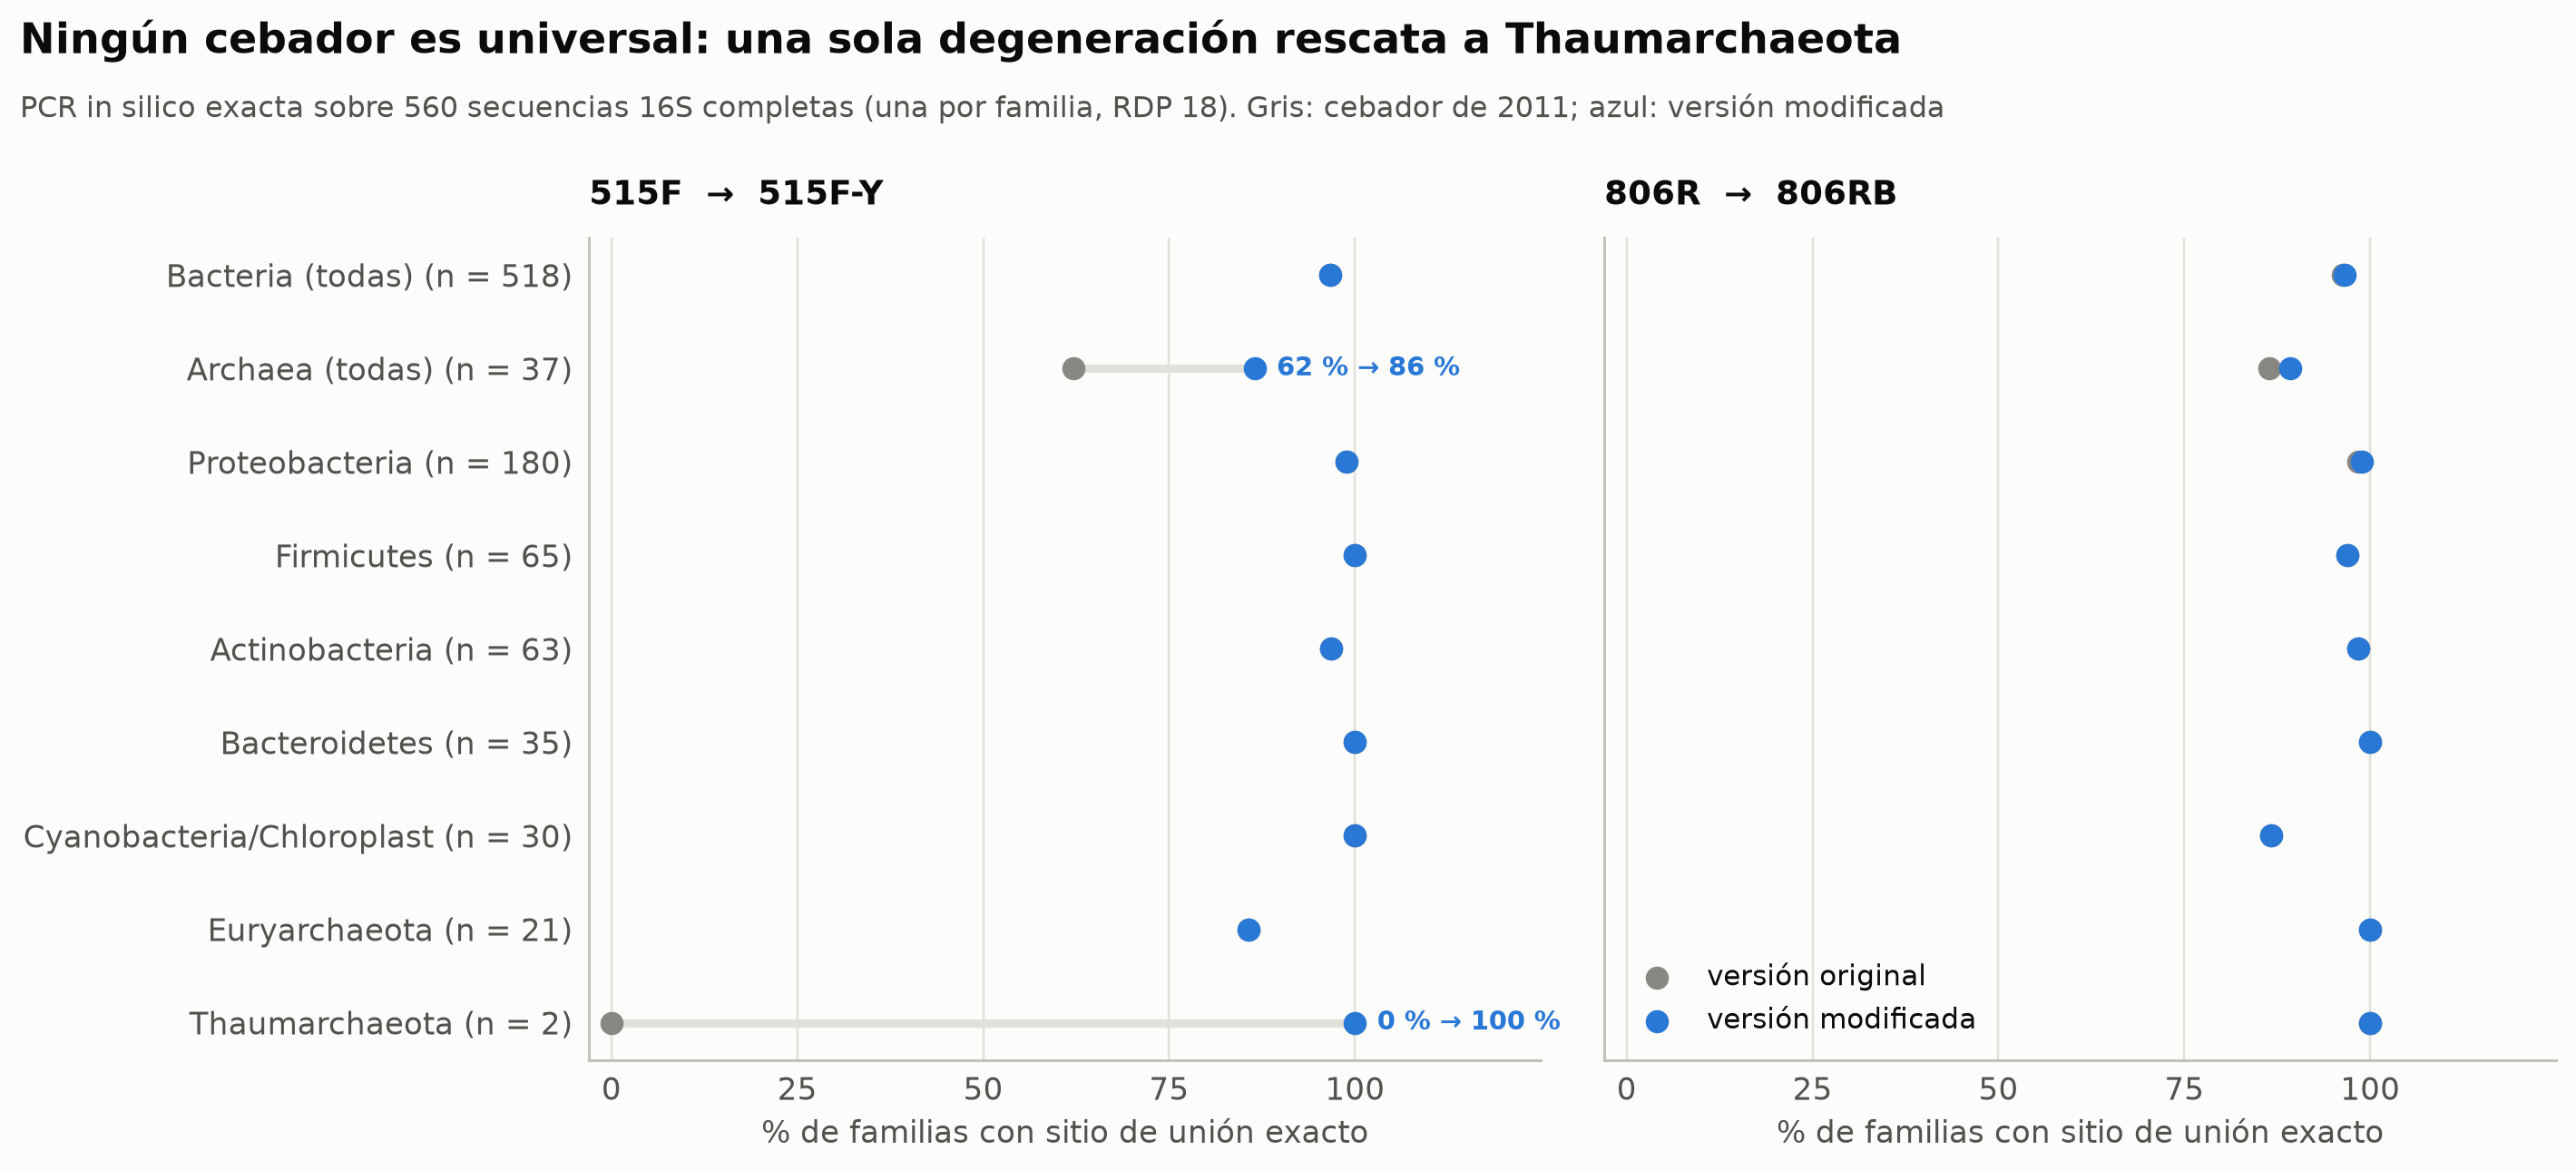

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
ylab = list(cov.index)
yy = np.arange(len(ylab))
for ax, (old, new) in zip(axes, [("515F (2011)", "515F-Y (2016)"), ("806R (2011)", "806RB (2015)")]):
    for i, g in enumerate(ylab):
        a, b = cov.loc[g, old], cov.loc[g, new]
        ax.plot([a, b], [i, i], color=ec.GRID, lw=3, zorder=1)
    ax.scatter(cov[old], yy, s=70, color=ec.MUTED, zorder=2, label="versión original")
    ax.scatter(cov[new], yy, s=70, color=ec.BLUE, zorder=3, label="versión modificada")
    for i, g in enumerate(ylab):
        a, b = cov.loc[g, old], cov.loc[g, new]
        if abs(a - b) > 3:
            ax.annotate(f"{a:.0f} % → {b:.0f} %", (max(a, b), i), xytext=(8, 0), textcoords="offset points",
                        va="center", fontsize=9.5, color=ec.BLUE, fontweight="bold")
    ax.set_xlim(-3, 125); ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("% de familias con sitio de unión exacto")
    ax.set_title(f"{old.split()[0]}  →  {new.split()[0]}", loc="left", fontsize=12)
    ax.grid(axis="x", color=ec.GRID); ax.grid(axis="y", visible=False)
axes[0].set_yticks(yy); axes[0].set_yticklabels([f"{g} (n = {cov.loc[g, 'n familias']})" for g in ylab])
axes[0].invert_yaxis()
axes[1].legend(loc="lower left", frameon=False)
ec.fig_title(fig, "Ningún cebador es universal: una sola degeneración rescata a Thaumarchaeota",
             "PCR in silico exacta sobre 560 secuencias 16S completas (una por familia, RDP 18). Gris: cebador de 2011; azul: versión modificada")
fig.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Ambos cebadores reconocen casi todas las familias bacterianas, pero el 515F original **no**
> tiene sitio de unión exacto en ninguna familia de Thaumarchaeota (arqueas oxidantes de amonio, abundantes en océanos y
> suelos); la degeneración `Y` de 515F-Y las recupera. Si dos estudios usan cebadores distintos, sus tablas pueden
> diferir por la química y no por la biología: **nunca compare abundancias obtenidas con cebadores distintos**. En el
> intestino de ratón, dominado por Firmicutes y Bacteroidetes, cualquiera de las versiones funciona bien.

> ✅ **Compruebe su comprensión.** ¿Cuántos oligonucleótidos distintos contiene un tubo del cebador 806RB
> (`GGACTACNVGGGTWTCTAAT`)? *(N = 4, V = 3, W = 2 → 4 × 3 × 2 = 24.)*

## 4. 🧪 Datos reales: el MiSeq SOP de mothur

Kozich *et al.* (2013) diseñaron una estrategia de doble índice para secuenciar la región V4 en el MiSeq y publicaron,
como material de entrenamiento, las lecturas de un ratón muestreado a lo largo del tiempo después del destete. Es el
conjunto de datos del tutorial oficial de mothur y del de DADA2, así que podremos contrastar nuestros resultados con los
que conoce toda la comunidad. Para que la clase corra en segundos, el repositorio del curso guarda una **submuestra
aleatoria de 1500 pares de lecturas por muestra** (semilla fija) de las 20 muestras de la corrida:

* 9 muestras **tempranas** (días 0, 1, 2, 3, 5, 6, 7, 8 y 9 después del destete),
* 10 muestras **tardías** (días 141 a 150),
* 1 comunidad ***mock*** (ADN de 21 cepas mezclado en el laboratorio).

Las lecturas ya vienen **demultiplexadas** (una muestra por archivo; aquí, una muestra por prefijo del nombre) y **sin
cebadores**: la lectura directa empieza justo después de 515F, en la posición 534 del 16S de *E. coli*.

In [9]:
LUT = np.full(256, 4, np.uint8)                      # A,C,G,T -> 0..3 ; N u otro -> 4
for i, b in enumerate(BASES):
    LUT[ord(b)] = i

def read_fastq(name, length=251):
    """Lee un FASTQ.gz del curso y devuelve nombres, bases codificadas (n x length) y calidades Phred."""
    lines = course_text(name).split("\n")
    names = [l[1:] for l in lines[0::4] if l]
    S = np.full((len(names), length), 4, np.uint8)
    Q = np.zeros((len(names), length), np.int16)
    for k in range(len(names)):
        s, q = lines[4 * k + 1], lines[4 * k + 3]
        m = min(length, len(s))
        S[k, :m] = LUT[np.frombuffer(s[:m].encode(), np.uint8)]
        Q[k, :m] = np.frombuffer(q[:m].encode(), np.uint8) - 33
    return np.array(names), S, Q

names1, S1, Q1 = read_fastq("141_miseqsop_sub_R1.fastq.gz")
names2, S2, Q2 = read_fastq("141_miseqsop_sub_R2.fastq.gz")
assert (names1 == names2).all()
read_sample = np.array([n.split(".")[0] for n in names1])
SAMPLES = list(pd.unique(read_sample))

# Metadatos: días después del destete (dpw) y periodo, como en mouse.dpw.metadata / mouse.time.design de mothur
meta = pd.DataFrame({"sample": SAMPLES})
meta["dpw"] = [int(s[3:]) if s.startswith("F3D") else np.nan for s in SAMPLES]
meta["time"] = ["Mock" if s == "Mock" else ("Early" if d <= 9 else "Late") for s, d in zip(SAMPLES, meta.dpw)]
meta["dpw"] = meta["dpw"].astype("Int64")
print(f"{len(names1):,} pares de lecturas · {len(SAMPLES)} muestras · longitud R1 = R2 = {S1.shape[1]} ciclos")
print(meta.set_index("sample").T.to_string())

30,000 pares de lecturas · 20 muestras · longitud R1 = R2 = 251 ciclos
sample   F3D0   F3D1   F3D2   F3D3   F3D5   F3D6   F3D7   F3D8   F3D9 F3D141 F3D142 F3D143 F3D144 F3D145 F3D146 F3D147 F3D148 F3D149 F3D150  Mock
dpw         0      1      2      3      5      6      7      8      9    141    142    143    144    145    146    147    148    149    150  <NA>
time    Early  Early  Early  Early  Early  Early  Early  Early  Early   Late   Late   Late   Late   Late   Late   Late   Late   Late   Late  Mock


Antes de hacer nada con las lecturas hay que **mirarlas**. El gráfico de calidad por posición (Lección 6.2) nos dirá dónde
recortar. Aquí la decisión tiene una restricción adicional: el amplicón V4 sin cebadores mide unos **253 nt**, y para
reconstruirlo uniremos la lectura directa con la reversa por su **solapamiento**. Si recortamos R1 a $L_1$ bases y R2 a
$L_2$, el solapamiento es

$$o = L_1 + L_2 - 253,$$

que debe ser cómodamente mayor que el mínimo que exige el programa de unión (aquí usaremos 12 nt). Con los recortes que
propone el tutorial de DADA2 para estos datos, $L_1 = 240$ y $L_2 = 160$: $o = 240 + 160 - 253 = 147$ nt, un margen
amplísimo. ¿Por qué no dejar las lecturas completas? Porque, como veremos, la cola de R2 es de mala calidad, y cada base
mala añade errores que el modelo tendrá que explicar.

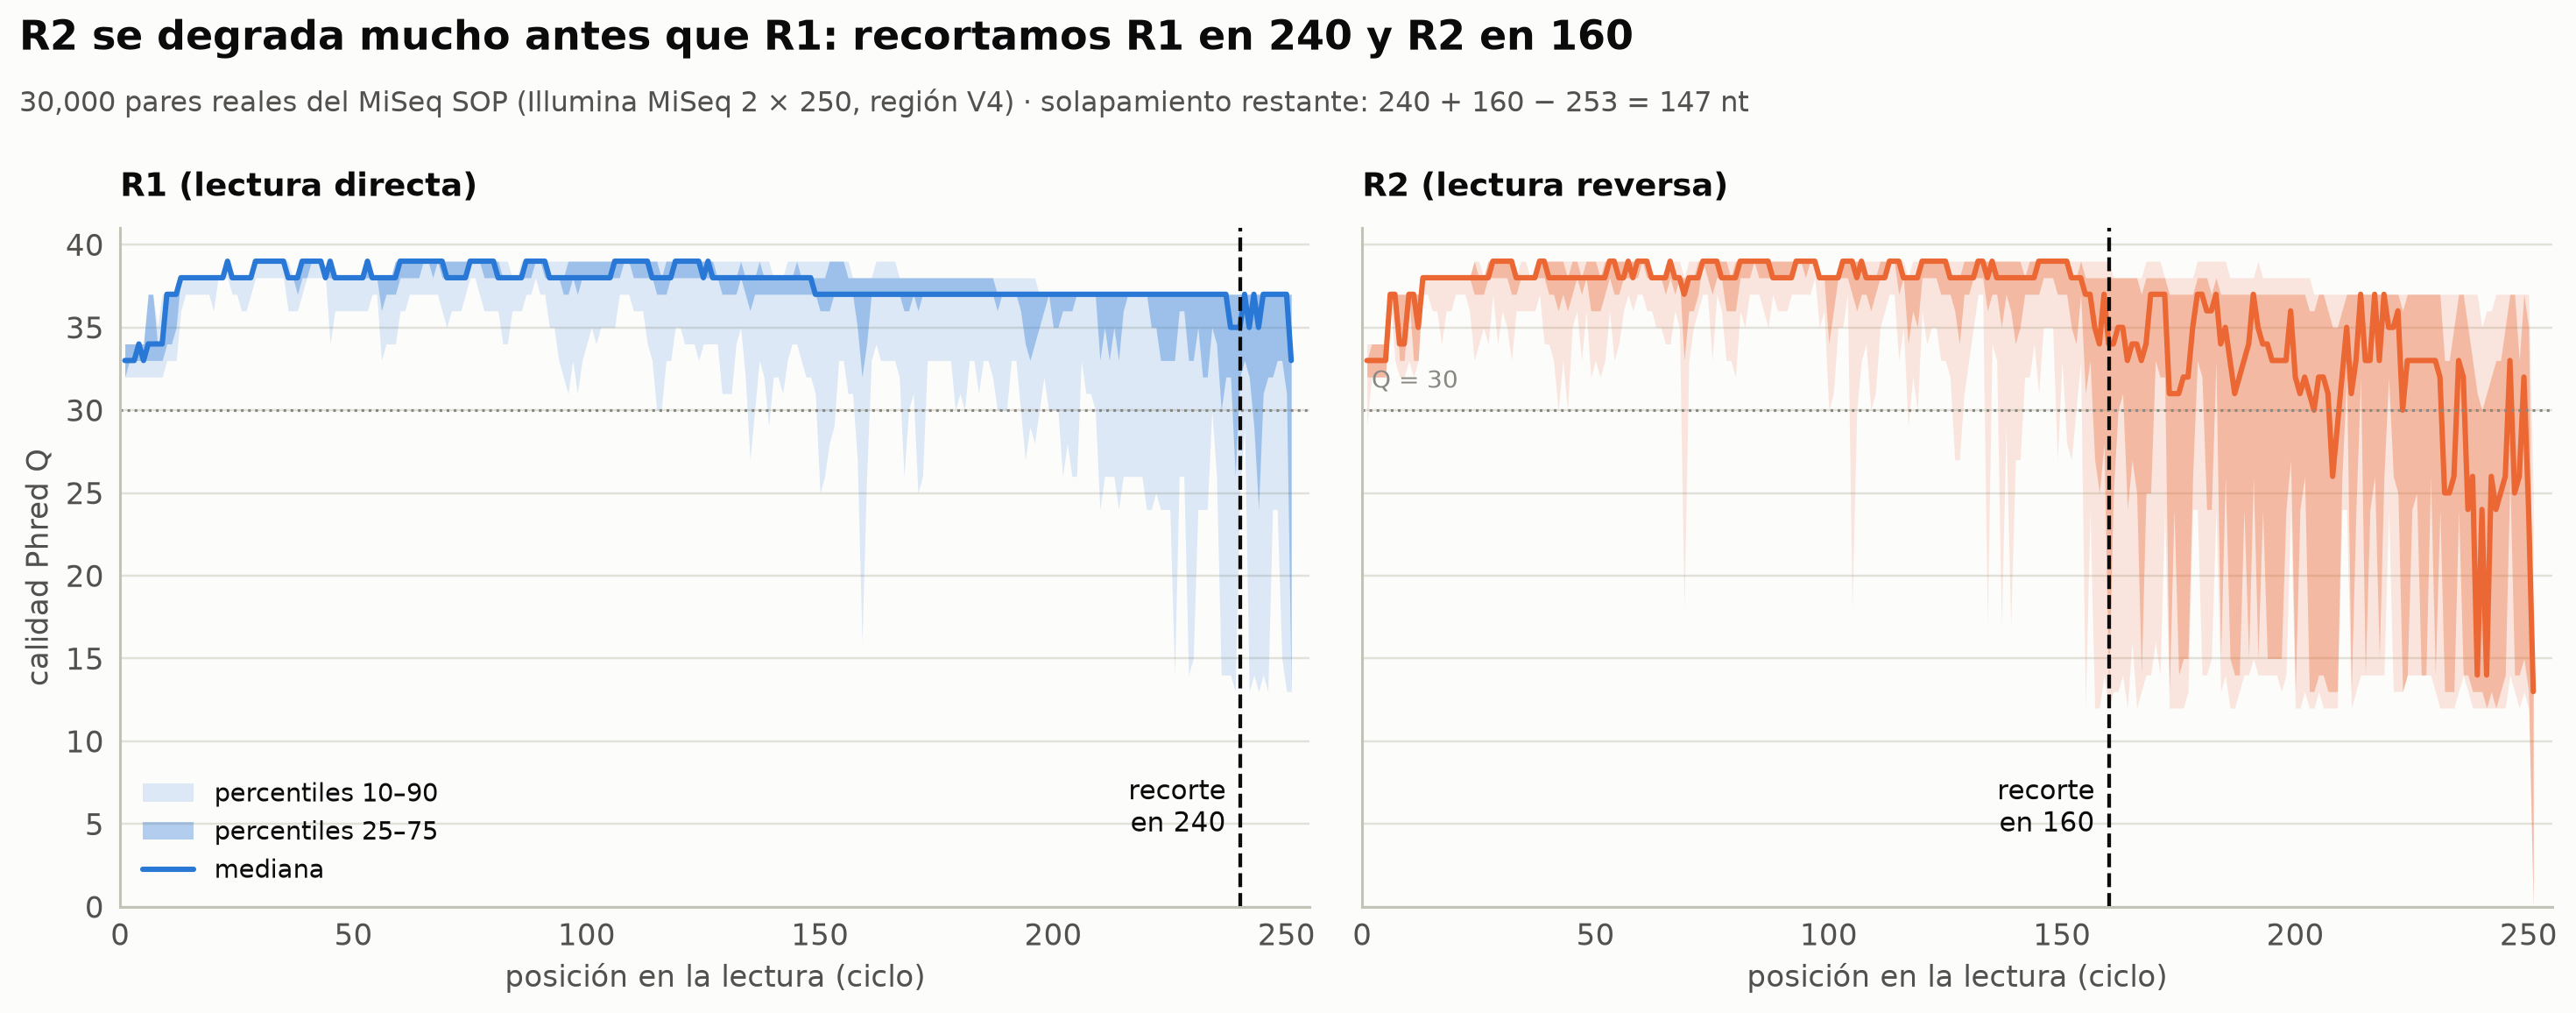

In [10]:
def quality_summary(Q):
    return np.percentile(Q, [10, 25, 50, 75, 90], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
for ax, Q, lab, cut, col in ((axes[0], Q1, "R1 (lectura directa)", 240, ec.BLUE),
                             (axes[1], Q2, "R2 (lectura reversa)", 160, ec.ORANGE)):
    p10, p25, p50, p75, p90 = quality_summary(Q)
    xx = np.arange(1, Q.shape[1] + 1)
    ax.fill_between(xx, p10, p90, color=col, alpha=0.15, lw=0, label="percentiles 10–90")
    ax.fill_between(xx, p25, p75, color=col, alpha=0.35, lw=0, label="percentiles 25–75")
    ax.plot(xx, p50, color=col, lw=2, label="mediana")
    ax.axhline(30, color=ec.MUTED, ls=":", lw=1)
    ax.axvline(cut, color=ec.INK, ls="--", lw=1.4)
    ax.text(cut - 3, 4, f"recorte\nen {cut}", ha="right", va="bottom", fontsize=10, color=ec.INK)
    ax.set_xlim(0, 255); ax.set_ylim(0, 41)
    ax.set_xlabel("posición en la lectura (ciclo)")
    ax.set_title(lab, loc="left", fontsize=12)
axes[0].set_ylabel("calidad Phred Q")
axes[0].legend(loc="lower left", frameon=False, fontsize=9.5)
axes[1].text(2, 31, "Q = 30", color=ec.MUTED, fontsize=9, va="bottom")
ec.fig_title(fig, "R2 se degrada mucho antes que R1: recortamos R1 en 240 y R2 en 160",
             f"{len(Q1):,} pares reales del MiSeq SOP (Illumina MiSeq 2 × 250, región V4) · solapamiento restante: 240 + 160 − 253 = 147 nt")
fig.tight_layout()
plt.show()

> 🔎 **Qué observamos.** R1 conserva una mediana cercana a Q35 hasta el ciclo ~240 y sólo después se abre el abanico de
> percentiles. R2 empieza a caer hacia el ciclo 150 y su percentil 10 se desploma por debajo de Q20: es el patrón típico
> del MiSeq, donde la lectura reversa sufre más el desfase acumulado. Los recortes 240/160 eliminan las colas malas sin
> comprometer la unión de los pares.

> ✅ **Compruebe su comprensión.** Si el amplicón fuera V3–V4 (~460 nt) con lecturas de 2 × 250, ¿cuánto solapamiento
> quedaría sin recortar nada? *(250 + 250 − 460 = 40 nt: poco margen; por eso V3–V4 exige 2 × 300.)*

## 5. OTUs: agrupar al 97 %

Durante una década, el procedimiento estándar para convertir millones de lecturas en una tabla de "especies" fue
agruparlas en **unidades taxonómicas operativas** (OTUs).

> **Definición (OTU).** Una OTU al nivel $\theta$ es un grupo de secuencias tal que cada miembro tiene una identidad de al
> menos $\theta$ con la secuencia representativa (**centroide**) del grupo. El umbral clásico es $\theta = 97\,\%$, que se
> tomó como aproximación a la "especie" bacteriana.

Para un amplicón V4 de 253 nucleótidos, el 97 % de identidad admite hasta

$$d_{\max} = \lfloor (1-\theta)\,L \rfloor = \lfloor 0{,}03 \times 253 \rfloor = \lfloor 7{,}59 \rfloor = 7 \text{ diferencias.}$$

| Símbolo | Significado |
|---|---|
| $\theta$ | umbral de identidad (0,97) |
| $L$ | longitud del amplicón comparado |
| $d_{\max}$ | máximo número de diferencias permitidas con el centroide |

Usaremos el algoritmo **voraz por centroides** (el de UCLUST/VSEARCH, simplificado): se ordenan las secuencias únicas
de mayor a menor abundancia; la primera es el centroide de la OTU 1; cada secuencia siguiente se une al primer centroide
que esté a $\le d_{\max}$ diferencias o, si no hay ninguno, funda una OTU nueva. Para no complicar el ejemplo trabajamos
con las lecturas directas recortadas a 240 nt (donde también $\lfloor 0{,}03 \times 240 \rfloor = 7$) y medimos la
distancia de Hamming (los errores de Illumina son casi todos sustituciones). Las lecturas con alguna base `N` se descartan.

In [11]:
def dereplicate(S, Q=None):
    """Secuencias únicas ordenadas por abundancia. Devuelve (únicas, abundancias, calidad media redondeada,
    índice de la única que corresponde a cada lectura)."""
    uniq, inv, cnt = np.unique(S, axis=0, return_inverse=True, return_counts=True)
    inv = inv.ravel()
    order = np.argsort(-cnt, kind="stable")
    rank = np.empty_like(order); rank[order] = np.arange(len(order))
    qmean = None
    if Q is not None:
        qsum = np.zeros((len(uniq), S.shape[1])); np.add.at(qsum, inv, Q)
        qmean = np.rint(qsum / cnt[:, None]).astype(np.int16)[order]
    return uniq[order], cnt[order], qmean, rank[inv]

def greedy_otus(U, dmax=7):
    """Agrupamiento voraz por centroides (U ya ordenado por abundancia). Devuelve centroides y etiqueta de OTU."""
    C = np.empty((0, U.shape[1]), np.uint8); cents = []; lab = np.empty(len(U), int)
    for k in range(len(U)):
        if cents:
            d = (C != U[k]).sum(1); m = int(d.argmin())
            if d[m] <= dmax:
                lab[k] = m; continue
        cents.append(k); C = np.vstack([C, U[k]]); lab[k] = len(cents) - 1
    return np.array(cents), lab

# Referencia de la mock: 32 copias del 16S (región V3–V5) de las 21 cepas
mock_ref = []
for line in course_text("141_hmp_mock_v35.fasta").splitlines():
    if line.startswith(">"):
        mock_ref.append([line[1:].strip(), ""])
    else:
        mock_ref[-1][1] += line.strip().upper().replace("-", "").replace(".", "")
mock_species = sorted({n.rsplit(".", 1)[0] for n, _ in mock_ref})
print(f"Referencia mock: {len(mock_ref)} secuencias de {len(mock_species)} cepas: {', '.join(mock_species)}")

def decode(u):
    return "".join(np.array(list("ACGTN"))[u])
def mock_match(seq):
    """Cepas de la mock que contienen exactamente esta secuencia (o lista vacía)."""
    return sorted({n.rsplit(".", 1)[0] for n, r in mock_ref if seq in r})

F240 = S1[:, :240]
noN = (F240 != 4).all(1)
otu_res = {}
for name, mask in (("Mock", (read_sample == "Mock") & noN), ("20 muestras", noN)):
    U, cnt, _, _ = dereplicate(F240[mask])
    cents, lab = greedy_otus(U)
    size = np.bincount(lab, weights=cnt).astype(int)
    otu_res[name] = (U, cnt, cents, lab, size)
    print(f"{name:12s}: {mask.sum():,} lecturas · {len(U):,} secuencias únicas · {len(cents)} OTUs "
          f"({(size == 1).sum()} con una sola lectura, {(size >= 10).sum()} con ≥ 10 lecturas)")

Referencia mock: 32 secuencias de 21 cepas: A.baumannii, A.odontolyticus, B.cereus, B.vulgatus, C.beijerinckii, D.radiodurans, E.coli, E.faecalis, H.pylori, L.gasseri, L.monocytogenes, N.meningitidis, P.acnes, P.aeruginosa, P.gingivalis, R.sphaeroides, S.agalactiae, S.aureus, S.epidermidis, S.mutans, S.pneumoniae
Mock        : 1,498 lecturas · 426 secuencias únicas · 67 OTUs (46 con una sola lectura, 18 con ≥ 10 lecturas)


20 muestras : 29,943 lecturas · 8,088 secuencias únicas · 1433 OTUs (1098 con una sola lectura, 160 con ≥ 10 lecturas)


OTUs de la mock cuyo centroide coincide exactamente con una cepa: 19 de 67 (20 cepas distintas)


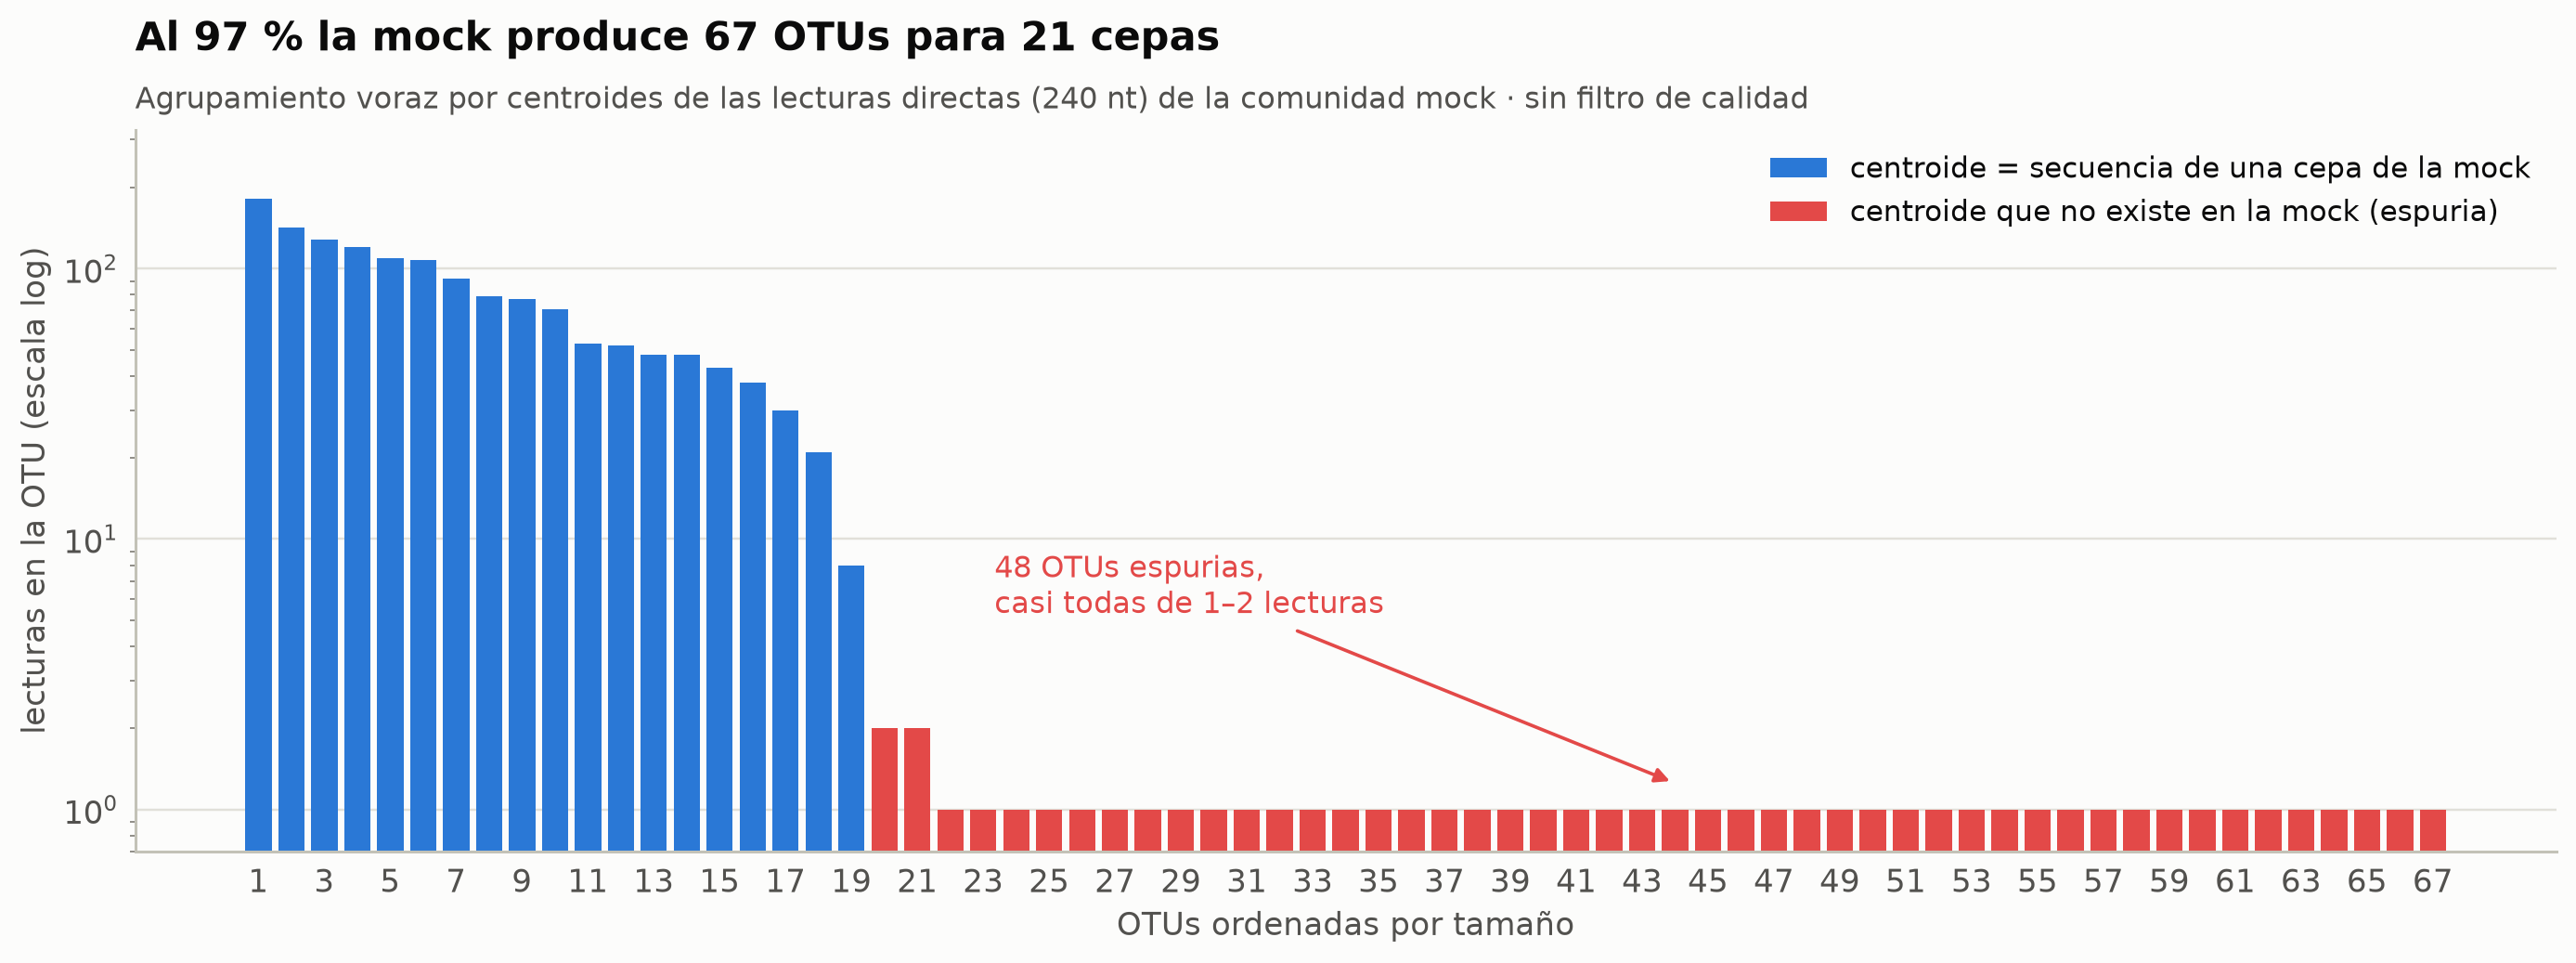

In [12]:
U, cnt, cents, lab, size = otu_res["Mock"]
order = np.argsort(-size)
hit = [mock_match(decode(U[cents[o]])) for o in order]
is_real = np.array([len(h) > 0 for h in hit])
strains_seen = sorted({s for h in hit for s in h})
print(f"OTUs de la mock cuyo centroide coincide exactamente con una cepa: {is_real.sum()} de {len(cents)} "
      f"({len(strains_seen)} cepas distintas)")

fig, ax = plt.subplots(figsize=(12.5, 4.6))
xr = np.arange(1, len(order) + 1)
ax.bar(xr[is_real], size[order][is_real], color=ec.BLUE, width=0.8, label="centroide = secuencia de una cepa de la mock")
ax.bar(xr[~is_real], size[order][~is_real], color=ec.RED, width=0.8, label="centroide que no existe en la mock (espuria)")
ax.set_yscale("log"); ax.set_ylim(0.7, size.max() * 1.8)
ax.set_xlabel("OTUs ordenadas por tamaño"); ax.set_ylabel("lecturas en la OTU (escala log)")
ax.legend(loc="upper right", frameon=False)
n_sp = (~is_real).sum()
ax.annotate(f"{n_sp} OTUs espurias,\ncasi todas de 1–2 lecturas", (xr[~is_real][len(xr[~is_real]) // 2], 1.25),
            xytext=(-240, 60), textcoords="offset points", fontsize=10.5, color=ec.RED,
            arrowprops=dict(arrowstyle="-|>", color=ec.RED, lw=1.2))
ax.set_xticks(xr[::2])
ec.title(ax, f"Al 97 % la mock produce {len(cents)} OTUs para {len(mock_species)} cepas",
         "Agrupamiento voraz por centroides de las lecturas directas (240 nt) de la comunidad mock · sin filtro de calidad")
plt.show()

> 🔎 **Qué observamos.** ¿Acertó su predicción? El agrupamiento al 97 % produce **más** grupos que cepas: las OTUs grandes
> corresponden a cepas reales, pero aparece una cola larga de OTUs pequeñas (casi todas de una o dos lecturas) cuyo
> centroide **no existe** en la mezcla. Son lecturas con más de siete errores, o quimeras: el radio fijo del 3 % no las
> absorbe. Las 19 OTUs "reales" representan 20 cepas: *S. aureus* y *S. epidermidis* tienen una V4 idéntica y caen
> juntas, y *P. acnes*, muy poco abundante en la mezcla, no aparece en esta submuestra.

El agrupamiento resuelve un problema real (sin él, cada lectura con un error sería un "organismo"), pero sus efectos
secundarios son serios:

1. **Pierde resolución**: dos cepas que difieren en tres nucleótidos de V4, quizá una comensal y una patógena, quedan fundidas.
2. **Depende del conjunto de datos**: los centroides *de novo* dependen del orden y la abundancia de las lecturas; al
   añadir muestras los límites cambian, y la "OTU 17" de un estudio no es comparable con la de otro.
3. **Deja sobrevivir errores**: una lectura con ocho errores, o una quimera, forma una OTU espuria (las barras rojas).
4. **El 3 % carece de fundamento biológico**: es un compromiso histórico, no una ley.

> ✅ **Compruebe su comprensión.** En las 20 muestras juntas obtuvimos más de mil OTUs, tres cuartas partes con una
> sola lectura. ¿Por qué no basta con "eliminar las OTUs de una lectura"? *(Porque también hay OTUs espurias de 2, 3 o más
> lecturas cuando el taxón que las origina es muy abundante, y porque una variante real rara puede tener una sola
> lectura. El umbral de abundancia debe depender de la abundancia del "padre" y de la distancia: es lo que hace DADA2.)*

## 6. De los errores a las variantes: la idea de DADA2

La alternativa moderna invierte la lógica. En lugar de preguntarse "¿qué lecturas se parecen lo suficiente?", pregunta:
**"¿qué secuencias reales tuvieron que estar en la muestra para producir las lecturas observadas, dado lo que sabemos de
los errores del secuenciador?"**. El resultado es un conjunto de **variantes de secuencia de amplicón** (ASVs),
secuencias exactas inferidas con resolución de un nucleótido. Callahan *et al.* (2016) implementaron este enfoque en
DADA2, y Callahan, McMurdie y Holmes (2017) argumentaron que las ASVs deben reemplazar a las OTUs porque son
**precisas** (distinguen variantes que difieren en una base), **reproducibles** (la misma secuencia biológica produce la
misma ASV en cualquier estudio) y **reutilizables** (la etiqueta de cada unidad es su propia secuencia, así que las
tablas de distintos estudios se combinan directamente).

> **Definición (ASV).** Una ASV es una secuencia exacta que un procedimiento de inferencia estadística considera presente
> en la muestra, porque su abundancia observada es demasiado alta para explicarse como producto de errores de
> amplificación y secuenciación de otras secuencias más abundantes.

### 6.1 El modelo de error

Piense en una fotocopiadora que se equivoca de vez en cuando. Si fotocopia 5000 veces la misma página, espera encontrar
algunas copias con una letra cambiada, muy pocas con dos cambios y prácticamente ninguna con diez. Si aparecen 500 copias
idénticas con la misma letra cambiada, sospecha que el original era otro. Formalmente: supongamos que una secuencia real
$i$ produce lecturas que, por errores, se observan como la secuencia $j$. Si los errores en cada posición son
independientes, la probabilidad de que una lectura de $i$ se lea exactamente como $j$ es el producto, posición a
posición, de las probabilidades de transición (ecuación 14.1 del libro):

$$\lambda_{ji} = \prod_{\ell=1}^{L} p\bigl(j(\ell)\mid i(\ell),\, q_j(\ell)\bigr).$$

| Símbolo | Significado |
|---|---|
| $\lambda_{ji}$ | probabilidad de que una lectura originada en la secuencia real $i$ se observe como la secuencia $j$ |
| $L$ | longitud de las secuencias (tras el recorte) |
| $i(\ell),\ j(\ell)$ | nucleótidos de $i$ y de $j$ en la posición $\ell$ |
| $q_j(\ell)$ | puntuación de calidad Phred de la posición $\ell$ en la lectura $j$ |
| $p(b\mid a, q)$ | probabilidad de leer la base $b$ cuando la verdadera es $a$, con calidad $q$; 16 transiciones por cada $q$ (las 4 de la diagonal son lecturas correctas) |

La ecuación compara $i$ y $j$ **posición a posición**: sólo contempla sustituciones. Nuestra implementación la sigue al
pie de la letra; DADA2 real alinea primero $j$ contra $i$ (Needleman–Wunsch con bandas) y así también maneja las raras
inserciones y deleciones de Illumina.

### 6.2 La prueba de abundancia

Si una secuencia real $i$ tiene abundancia $n_i$ (número de lecturas en su partición), el número esperado de lecturas
idénticas a $j$ que $i$ produce por error es $n_i\lambda_{ji}$. Con errores independientes entre lecturas, el número de
copias de $j$ generadas por error sigue aproximadamente una distribución de **Poisson** con esa media. Eso permite
preguntar si la abundancia observada de $j$, $a_j$, es **sorprendente** (ecuación 14.2 del libro):

$$p_A(j \mid i) = \frac{1}{1 - \rho(0;\, n_i\lambda_{ji})}\sum_{a \ge a_j} \rho(a;\, n_i\lambda_{ji}),
\qquad \rho(a;\mu) = \frac{\mu^a e^{-\mu}}{a!}.$$

Si $p_A(j\mid i) < \Omega_A$, la secuencia $j$ se declara una nueva variante; DADA2 usa por defecto $\Omega_A = 10^{-40}$.

| Símbolo | Significado |
|---|---|
| $a_j$ | abundancia observada (número de lecturas idénticas) de la secuencia única $j$ |
| $n_i$ | número total de lecturas asignadas a la partición cuyo centro es $i$ |
| $\rho(a;\mu)$ | función de probabilidad de Poisson con media $\mu$ |
| $1-\rho(0;\mu)$ | probabilidad de observar $j$ al menos una vez; condicionar en ella corrige que sólo evaluamos secuencias que sí aparecieron |
| $\Omega_A$ | umbral de significancia; muy pequeño porque se hacen miles de pruebas por muestra |

El algoritmo es **divisivo**. Empieza con todas las secuencias únicas en una sola partición cuyo centro es la más
abundante. Calcula $p_A$ para cada secuencia; si la menor está por debajo de $\Omega_A$, esa secuencia se convierte en el
centro de una nueva partición, las secuencias se reasignan al centro que mejor las explica (mayor $n_i\lambda_{ji}$) y el
proceso se repite hasta que ninguna secuencia sea sorprendente. Los centros finales son las ASVs.

### 6.3 Ejemplo del libro: ¿error o variante a un nucleótido?

En la simulación del libro, la variante dominante produce $n_i = 5000$ moléculas de un amplicón de $L = 250$ pb y la
tasa de error es $e = 0{,}002$ por base, repartida por igual entre las tres bases incorrectas. Resolvamos a mano:

1. Probabilidad de que una lectura de $i$ se lea como una secuencia concreta $j$ que difiere en **una** posición: en esa
   posición debe ocurrir *ese* error concreto ($e/3$) y en las otras 249 ninguno ($(1-e)^{249}$):
   $$\lambda_{ji} = \frac{e}{3}\,(1-e)^{249} = 6{,}67\times10^{-4}\times 0{,}607 = 4{,}05\times10^{-4}.$$
2. Número esperado de copias de $j$ generadas por error: $\mu = n_i\lambda_{ji} = 5000 \times 4{,}05\times10^{-4} = 2{,}03$.
3. Observar 3 o 4 copias no tiene nada de raro. Observar 10 ya es improbable ($p_A \approx 6\times10^{-5}$; el libro redondea a $5\times10^{-5}$), pero muy
   lejos de $10^{-40}$.
4. La abundancia **umbral** (la mínima con $p_A < 10^{-40}$) es de **43 copias**.
5. La variante real a un nucleótido aparece **557** veces: $p_A \sim 10^{-1119}$. DADA2 la reconoce sin ambigüedad.

La prueba no depende de un umbral de identidad: a un nucleótido de una variante con **cinco millones** de lecturas se
esperarían unas $5\times10^{6}\times 4{,}05\times10^{-4} \approx 2025$ copias por error, y 557 serían perfectamente
compatibles con ruido; mientras que a diez nucleótidos de cualquier variante bastan unas pocas copias idénticas para que
la secuencia sea real.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántas copias idénticas harán falta para declarar real una secuencia a **cuatro**
> nucleótidos del centro de 5000 lecturas? ¿Más o menos que a un nucleótido?

El libro trae este código (`pvalor_abundancia.py`); lo ejecutamos tal cual:

In [13]:
# Código del libro (pvalor_abundancia.py), sin cambios
import numpy as np
from scipy.special import gammaln, logsumexp

def log10_pA(a_j, n_i, d, L=250, e=0.002):
    """log10 del valor p de abundancia de DADA2 (ec. 14.2)."""
    lam = (e / 3) ** d * (1 - e) ** (L - d)       # ec. 14.1
    mu = n_i * lam
    k = np.arange(a_j, a_j + 500)                  # cola de Poisson
    lcola = logsumexp(k * np.log(mu) - mu - gammaln(k + 1))
    lden = np.log(-np.expm1(-mu))                  # P(A > 0)
    return (lcola - lden) / np.log(10)

print(log10_pA(10, 5000, 1))     # -4.3: raro, pero no significativo
print(log10_pA(557, 5000, 1))    # ~ -1119: variante real

-4.227163386422179
-1119.47206944818


In [14]:
# Las cifras del ejemplo, paso a paso
L_sim, e_sim, n_dom = 250, 0.002, 5000
lam1 = (e_sim / 3) * (1 - e_sim) ** (L_sim - 1)
print(f"e/3 = {e_sim/3:.3e} · (1-e)^249 = {(1-e_sim)**249:.3f} · λ = {lam1:.3e} · μ = n_i λ = {n_dom*lam1:.3f}")
print(f"P(A ≥ 3 | μ) = {stats.poisson.sf(2, n_dom*lam1):.2f}  ·  P(A ≥ 4) = {stats.poisson.sf(3, n_dom*lam1):.2f}  (nada raro)")
print(f"Con 5 millones de lecturas: μ = {5e6*lam1:,.0f} copias esperadas por error a 1 nt")

def threshold_abundance(n_i, d, L=250, e=0.002, log10_omega=-40):
    """Mínima abundancia a con p_A(a) < Ω_A frente a un centro de n_i lecturas a distancia d."""
    a = 1
    while log10_pA(a, n_i, d, L, e) >= log10_omega:
        a += 1
    return a

thr = pd.DataFrame([(d, (e_sim/3)**d*(1-e_sim)**(L_sim-d)*n_dom, threshold_abundance(n_dom, d)) for d in range(1, 7)],
                   columns=["d (nt)", "μ = n_i λ", "abundancia umbral a*"])
print(thr.to_string(index=False, formatters={"μ = n_i λ": "{:.3g}".format}))

e/3 = 6.667e-04 · (1-e)^249 = 0.607 · λ = 4.050e-04 · μ = n_i λ = 2.025
P(A ≥ 3 | μ) = 0.33  ·  P(A ≥ 4) = 0.15  (nada raro)
Con 5 millones de lecturas: μ = 2,025 copias esperadas por error a 1 nt
 d (nt) μ = n_i λ  abundancia umbral a*
      1      2.02                    43
      2   0.00135                    12
      3  9.04e-07                     8
      4  6.04e-10                     6
      5  4.03e-13                     5
      6  2.69e-16                     4


> 🔎 **Qué observamos.** Se reproducen las cifras del libro: $\lambda = 4{,}05\times10^{-4}$, $\mu = 2{,}03$,
> $\log_{10} p_A(10) = -4{,}23$ (el comentario del código lo redondea a $-4{,}3$; sin el condicionamiento en
> $A>0$ sería $-4{,}29$, es decir $p \approx 5\times10^{-5}$), $\log_{10} p_A(557) \approx -1119$, y los umbrales **43, 12, 8 y 6** copias a 1, 2, 3 y 4
> nucleótidos. Cada nucleótido de distancia multiplica $\mu$ por $\approx e/3 \approx 7\times10^{-4}$: a cuatro
> nucleótidos se esperan $6\times10^{-10}$ copias por error, y con seis idénticas ya es imposible que sean ruido.

Veamos la distribución de Poisson que hay detrás del caso $d = 1$: la probabilidad de cada número de copias $a$ cuando
$\mu = 2{,}03$, y dónde caen 10, 43 y 557.

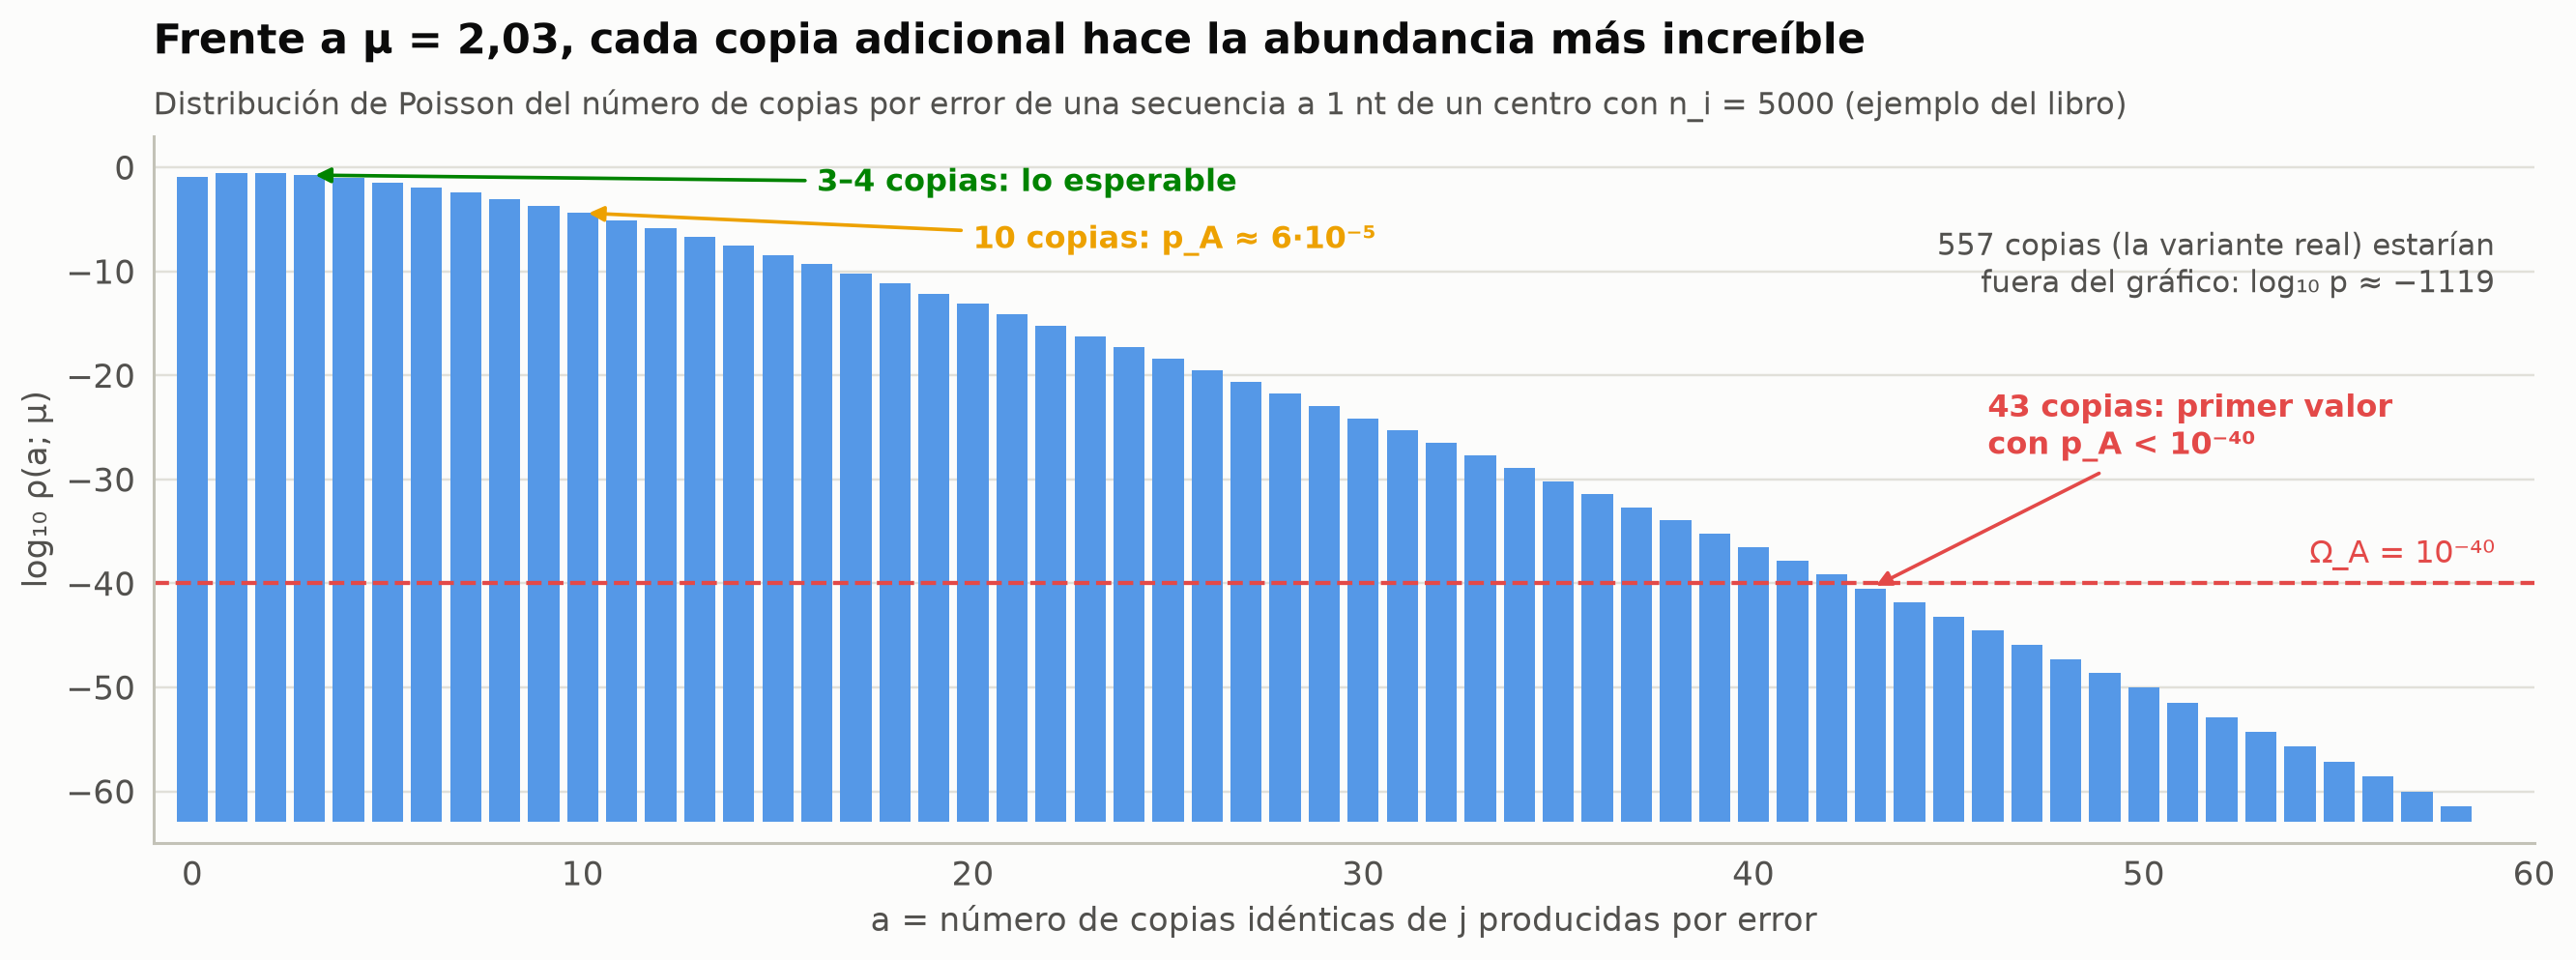

In [15]:
mu1 = n_dom * lam1
aa = np.arange(0, 60)
logpmf = stats.poisson.logpmf(aa, mu1) / np.log(10)
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.bar(aa, logpmf - logpmf.min() + 0, bottom=logpmf.min(), color=ec.SEQ_BLUE[5], width=0.8)
ax.axhline(-40, color=ec.RED, ls="--", lw=1.4)
ax.text(59, -38, "Ω_A = 10⁻⁴⁰", color=ec.RED, ha="right", fontsize=10.5)
for a_mark, txt, col, xyt in ((3, "3–4 copias: lo esperable", ec.GREEN, (16, -1.5)),
                              (10, "10 copias: p_A ≈ 6·10⁻⁵", ec.YELLOW, (20, -7)),
                              (43, "43 copias: primer valor\ncon p_A < 10⁻⁴⁰", ec.RED, (46, -25))):
    ax.annotate(txt, (a_mark, stats.poisson.logpmf(a_mark, mu1) / np.log(10)), xytext=xyt, textcoords="data",
                fontsize=10.5, color=col, fontweight="bold", va="center",
                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.2))
ax.set_xlabel("a = número de copias idénticas de j producidas por error")
ax.set_ylabel("log₁₀ ρ(a; μ)")
ax.set_xlim(-1, 60); ax.set_ylim(logpmf.min() - 2, 3)
ax.text(59, -12, "557 copias (la variante real) estarían\nfuera del gráfico: log₁₀ p ≈ −1119",
        ha="right", fontsize=10, color=ec.INK_2)
ec.title(ax, "Frente a μ = 2,03, cada copia adicional hace la abundancia más increíble",
         "Distribución de Poisson del número de copias por error de una secuencia a 1 nt de un centro con n_i = 5000 (ejemplo del libro)")
plt.show()

### 6.4 La simulación del libro: seis variantes y miles de errores

El libro simula un amplicón de 250 pb con **seis variantes reales** (a 0, 1, 4, 9, 15 y 22 nucleótidos de la dominante)
y abundancias de 5000, 900, 2000, 400, 150 y 60 moléculas, con errores de sustitución a una tasa de $0{,}002$ por base.
Reproducimos exactamente su código y su semilla (`1977`, el año de Woese y Fox), de modo que obtendremos las mismas
cifras: **8510** lecturas, **2179** secuencias únicas y un **38 %** de lecturas con errores.

In [16]:
# === Simulación de la figura 14.3 del libro (figuras/cap14/generar.py), misma semilla y mismo orden de llamadas ===
rng_libro = np.random.default_rng(1977)          # año de Woese y Fox
L = 250
ref = rng_libro.choice(4, L)

def mutar(seq, k):
    s = seq.copy()
    pos = rng_libro.choice(L, k, replace=False)
    for p in pos:
        s[p] = (s[p] + rng_libro.integers(1, 4)) % 4
    return s

# seis variantes reales: la 2 difiere de la 1 en un único nucleótido
centros = [ref, mutar(ref, 1), mutar(ref, 4), mutar(ref, 9), mutar(ref, 15), mutar(ref, 22)]
abund = np.array([5000, 900, 2000, 400, 150, 60])
e = 0.002                                         # tasa de sustitución por base
lecturas, origen = {}, {}
for c, (sq, n) in enumerate(zip(centros, abund)):
    for _ in range(n):
        s = sq.copy()
        m = rng_libro.random(L) < e
        if m.any():
            s[m] = (s[m] + rng_libro.integers(1, 4, m.sum())) % 4
        key = s.tobytes()
        lecturas[key] = lecturas.get(key, 0) + 1
        origen.setdefault(key, c)
claves_centros = {sq.tobytes(): i for i, sq in enumerate(centros)}
C = np.array(centros)
filas_v, filas_e = [], []
for key, a in lecturas.items():
    s = np.frombuffer(key, dtype=ref.dtype)
    if key in claves_centros:
        i = claves_centros[key]
        otros = [j for j in range(len(C)) if abund[j] > abund[i]]
        d = min((C[j] != s).sum() for j in otros) if otros else 0
        filas_v.append((int(d), a, i))
    else:
        dist = (C != s).sum(axis=1)
        d = dist.min()
        filas_e.append((d + rng_libro.uniform(-0.28, 0.28), a, int(d), int(dist.argmin())))
n_err = sum(a for k, a in lecturas.items() if k not in claves_centros)
print(f"lecturas = {abund.sum()} · únicas = {len(lecturas)} · lecturas con error = {n_err} ({n_err/abund.sum():.1%})")
print("variantes reales (d, lecturas sin error, índice):", sorted(filas_v))
print("error más abundante:", max(f[1] for f in filas_e), "copias")

lecturas = 8510 · únicas = 2179 · lecturas con error = 3264 (38.4%)
variantes reales (d, lecturas sin error, índice): [(0, 3075, 0), (1, 557, 1), (4, 1237, 2), (9, 256, 3), (15, 86, 4), (22, 35, 5)]
error más abundante: 9 copias


El gráfico interactivo siguiente es la figura 14.3 del libro. Cada punto gris es una secuencia única con al menos un
error, situada según su distancia de Hamming al centro real más cercano (con una pequeña dispersión horizontal para que
se vean) y su abundancia. Los rombos azules son las variantes reales. La línea roja es la abundancia mínima que resulta
"sorprendente" frente a la variante dominante ($n_i = 5000$). **Pase el cursor** por los puntos: verá $\mu = n_i\lambda$
y el valor $p$ que tendría cada secuencia si se la comparara con la dominante.

a =  10, d = 1: libro     -4.23 · vectorizada     -4.23
a =  43, d = 1: libro    -40.40 · vectorizada    -40.40
a = 557, d = 1: libro  -1119.47 · vectorizada  -1119.47
a =   6, d = 4: libro    -48.95 · vectorizada    -48.95


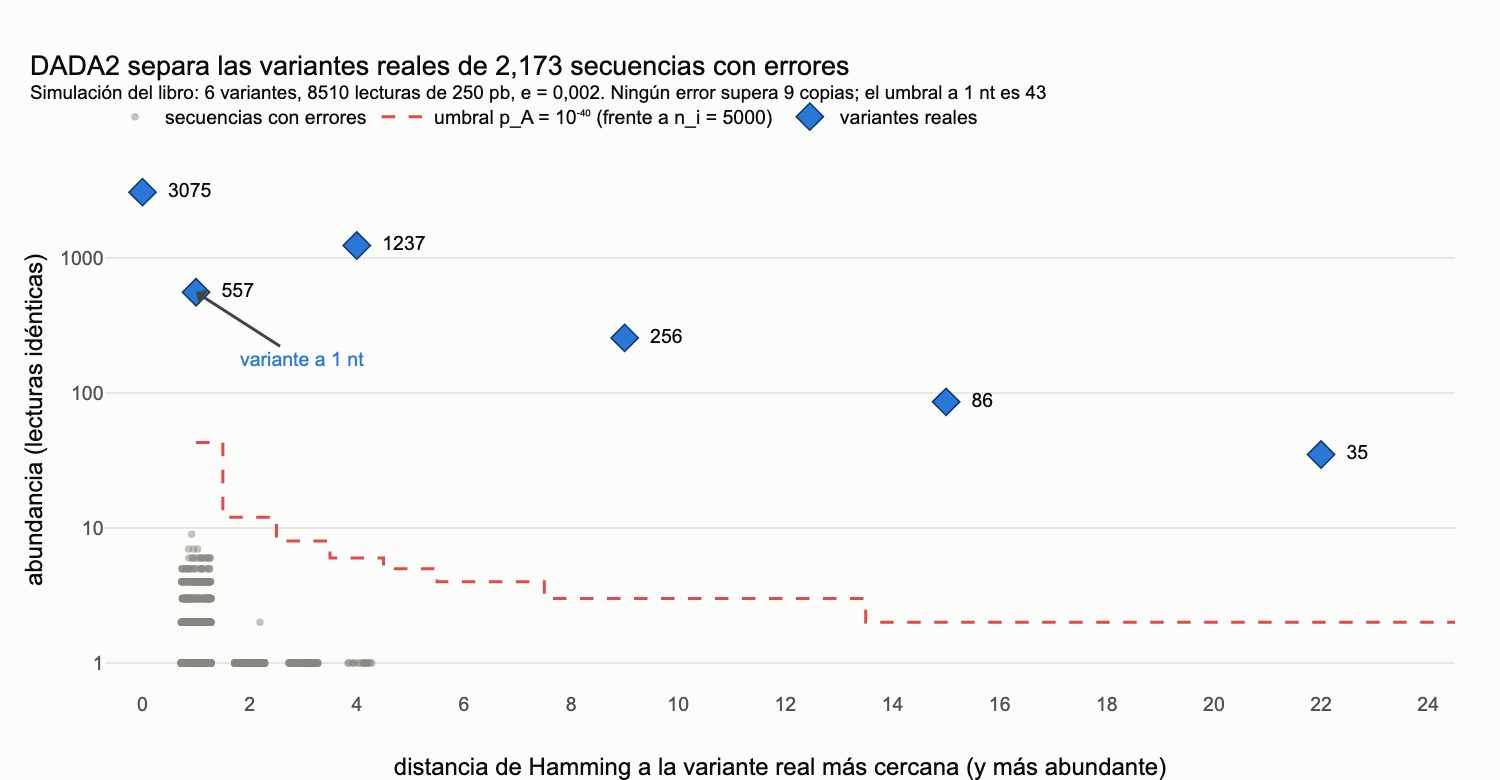

In [17]:
def log10_pA_fast(a, logmu):
    """Versión vectorizada de la ec. 14.2 en escala logarítmica (no se desborda con μ minúsculos).
    Usa la función gamma incompleta P(a, μ) = P(X ≥ a) y, cuando es menor que 1e-280, el término dominante
    de la cola: log ρ(a; μ) − log(1 − μ/(a+1))."""
    a = np.asarray(a, float); logmu = np.asarray(logmu, float); mu = np.exp(logmu)
    with np.errstate(divide="ignore", invalid="ignore"):
        lden = np.where(mu > 1e-8, np.log(-np.expm1(-mu)), logmu)
        tail = gammainc(a, mu)
        lt = np.where(tail > 1e-280, np.log(np.maximum(tail, 1e-300)),
                      a * logmu - mu - gammaln(a + 1) - np.log1p(-np.minimum(mu / (a + 1), 0.999)))
    out = np.minimum((lt - lden) / np.log(10), 0.0)
    return np.where(a <= 1, 0.0, out)              # un singleton nunca es sorprendente

# comprobación contra el código del libro
for a_, d_ in ((10, 1), (43, 1), (557, 1), (6, 4)):
    lm = np.log(n_dom) + d_ * np.log(e_sim / 3) + (L_sim - d_) * np.log(1 - e_sim)
    print(f"a = {a_:>3}, d = {d_}: libro {log10_pA(a_, n_dom, d_):9.2f} · vectorizada {float(log10_pA_fast(a_, lm)):9.2f}")

err = pd.DataFrame(filas_e, columns=["x", "a", "d", "centro"])
lmu = np.log(abund[0]) + err.d * np.log(e / 3) + (L - err.d) * np.log(1 - e)
err["mu"] = np.exp(lmu); err["lp"] = log10_pA_fast(err.a, lmu)
real = pd.DataFrame(sorted(filas_v), columns=["d", "a", "i"])
real["lp"] = [float(log10_pA(a_, 5000, d_)) if d_ > 0 else 0.0 for d_, a_ in zip(real.d, real.a)]
thr_curve = [(d, threshold_abundance(5000, d)) for d in range(1, 26)]

figd = go.Figure()
figd.add_trace(go.Scatter(
    x=err.x, y=err.a, mode="markers", name="secuencias con errores",
    marker=dict(color=ec.MUTED, size=5, opacity=0.5),
    customdata=np.stack([err.d, err.centro + 1, err.mu, err.lp], axis=1),
    hovertemplate=("<b>secuencia con errores</b><br>%{y} copias idénticas · a %{customdata[0]} nt de la variante "
                   "%{customdata[1]}<br>μ = n_i·λ = %{customdata[2]:.2e} copias esperadas por error"
                   "<br>log₁₀ p_A = %{customdata[3]:.1f} → no sorprende<extra></extra>")))
figd.add_trace(go.Scatter(
    x=[d for d, _ in thr_curve], y=[a for _, a in thr_curve], mode="lines", line=dict(color=ec.RED, dash="dash", shape="hvh"),
    name="umbral p_A = 10⁻⁴⁰ (frente a n_i = 5000)",
    hovertemplate="a %{x} nt de la dominante hacen falta <b>%{y}</b> copias idénticas<extra></extra>"))
figd.add_trace(go.Scatter(
    x=real.d, y=real.a, mode="markers+text", name="variantes reales",
    marker=dict(symbol="diamond", size=14, color=ec.BLUE, line=dict(color="#0d366b", width=1)),
    text=[f"  {a}" for a in real.a], textposition="middle right",
    customdata=np.stack([real.i + 1, abund[real.i], real.lp], axis=1),
    hovertemplate=("<b>variante real %{customdata[0]}</b> (%{customdata[1]} moléculas)<br>%{y} lecturas sin error, "
                   "a %{x} nt de una variante más abundante<br>log₁₀ p_A frente a la dominante = %{customdata[2]:.0f}"
                   "<extra></extra>")))
figd.add_annotation(x=1, y=np.log10(557), text="variante a 1 nt", showarrow=True, ax=70, ay=45, font=dict(color=ec.BLUE))
figd.update_layout(
    title=(f"DADA2 separa las variantes reales de {len(err):,} secuencias con errores<br><sup>Simulación del libro: "
           "6 variantes, 8510 lecturas de 250 pb, e = 0,002. Ningún error supera 9 copias; el umbral a 1 nt es 43</sup>"),
    xaxis=dict(title="distancia de Hamming a la variante real más cercana (y más abundante)", range=[-0.7, 24.5], dtick=2),
    yaxis=dict(title="abundancia (lecturas idénticas)", type="log", range=[-0.2, 3.8], tickvals=[1, 10, 100, 1000]),
    height=520, margin=dict(t=100, l=70, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.0))
figd.show()

> 🔎 **Qué observamos.** Los errores forman una nube que decae con la distancia: casi todos están a 1–3 nucleótidos de su
> variante de origen y ninguno supera 9 copias. La línea roja baja en escalones (43, 12, 8, 6 copias…) y a partir de
> cuatro nucleótidos se estabiliza: más lejos, casi cualquier secuencia repetida es real. Las seis variantes, incluida la
> que difiere en **un solo** nucleótido de la dominante, quedan muy por encima del umbral. Un agrupamiento al 97 % (hasta
> 7 diferencias en 250 nt) habría fundido las variantes a distancias 1 y 4 con la dominante.

> ✅ **Compruebe su comprensión.** Un error a 2 nt de la dominante aparece 11 veces. ¿Es una variante? ¿Y si la dominante
> tuviera 50 000 lecturas en lugar de 5000? *(Con $n_i = 5000$ el umbral a 2 nt es 12 copias: 11 no basta. Con 50 000,
> $\mu$ se multiplica por 10 y el umbral sube: 11 copias serían todavía menos sorprendentes.)*

## 7. Filtrado previo: errores esperados

Antes de la inferencia conviene descartar lecturas cuya calidad hace inútil cualquier modelo. DADA2 y QIIME 2 usan el
número de **errores esperados**, que se deduce directamente de la escala Phred ($P_{\text{error}} = 10^{-q/10}$,
Lección 2.1):

$$\mathrm{EE} = \sum_{\ell=1}^{L} 10^{-q(\ell)/10}.$$

| Símbolo | Significado |
|---|---|
| $\mathrm{EE}$ | número esperado de errores en la lectura (suma de las probabilidades de error por posición) |
| $q(\ell)$ | calidad Phred de la base $\ell$ |
| $L$ | longitud de la lectura tras el recorte |

Por **linealidad de la esperanza**, la suma no requiere suponer independencia entre posiciones. Ejemplos resueltos:

* 250 bases con $Q = 30$ en todas sus posiciones: $\mathrm{EE} = 250 \times 10^{-3} = 0{,}25$.
* 250 bases con $Q = 25$: $\mathrm{EE} = 250 \times 10^{-2{,}5} = 0{,}79$.
* 250 bases con $Q = 20$: $\mathrm{EE} = 250 \times 10^{-2} = 2{,}5$.

Un filtro habitual descarta lecturas con $\mathrm{EE} > 2$. Es preferible a filtrar por **calidad media**, porque la media
en escala Phred oculta las pocas bases malas que dominan la suma. Compruébelo: una lectura de 250 bases con 240 bases a
Q38 y 10 bases a Q5 tiene calidad media $(240\times38 + 10\times5)/250 = 36{,}7$ (¡excelente!), pero
$\mathrm{EE} = 240\times10^{-3{,}8} + 10\times10^{-0{,}5} = 0{,}04 + 3{,}16 = 3{,}2$ errores esperados: casi todos
vienen de esas diez bases.

In [18]:
def expected_errors(Q):
    return (10.0 ** (-Q / 10)).sum(axis=-1)

for q in (30, 25, 20):
    print(f"250 pb a Q{q}: EE = {expected_errors(np.full(250, q)):.2f}")
qprof = np.concatenate([np.full(150, 36), np.linspace(36, 18, 100)])
print(f"Perfil realista (150 bases a Q36 y caída lineal hasta Q18): EE = {expected_errors(qprof):.2f}")
trap = np.array([38] * 240 + [5] * 10)
print(f"Lectura trampa: calidad media = {trap.mean():.1f}, EE = {expected_errors(trap):.2f}")

250 pb a Q30: EE = 0.25
250 pb a Q25: EE = 0.79
250 pb a Q20: EE = 2.50
Perfil realista (150 bases a Q36 y caída lineal hasta Q18): EE = 0.42
Lectura trampa: calidad media = 36.7, EE = 3.20


Ahora aplicamos a los datos reales el filtro que usa el tutorial de DADA2 con este conjunto: recortar R1 a 240 y R2 a
160 bases; descartar pares con alguna `N`, con alguna base de calidad $\le 2$ (la "bandera" de Illumina) o con
$\mathrm{EE} > 2$ en **cualquiera** de las dos lecturas. El par se conserva o se descarta entero.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué lectura perderá más pares por errores esperados, R1 recortada a 240 o R2
> recortada a 160? ¿Y si no recortáramos R2?

Pares con N: 246 · con alguna base Q ≤ 2: 246 · EE(R1) > 2: 2089 · EE(R2) > 2: 648
Sin recortar, EE > 2 en R1: 8.4% · en R2: 38.8%
Pares que pasan el filtro: 27,448 de 30,000 (91.5%)


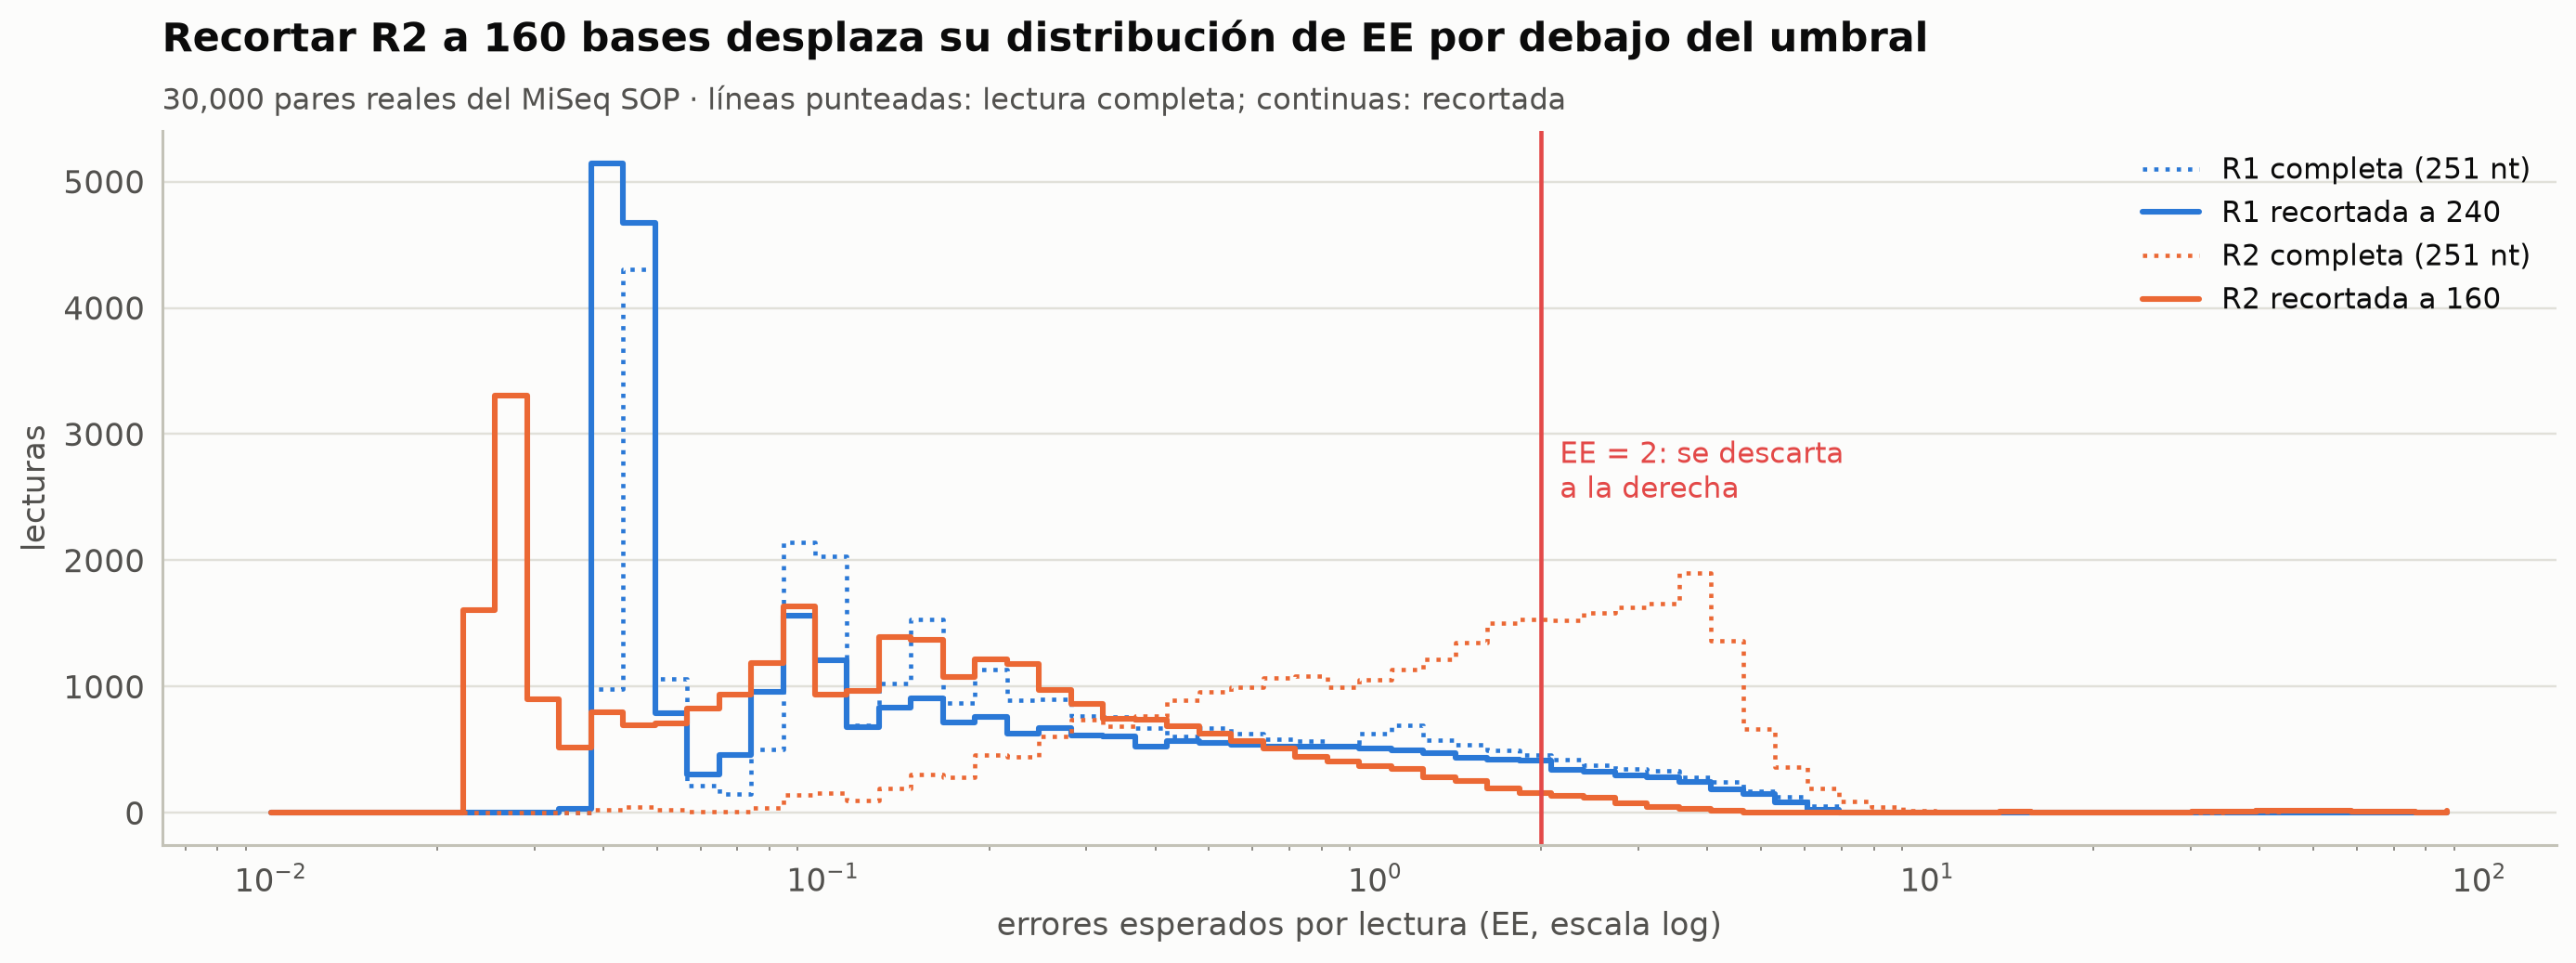

          F3D0  F3D1  F3D2  F3D3  F3D5  F3D6  F3D7  F3D8  F3D9  F3D141  F3D142  F3D143  F3D144  F3D145  F3D146  F3D147  F3D148  F3D149  F3D150  Mock
input     1500  1500  1500  1500  1500  1500  1500  1500  1500    1500    1500    1500    1500    1500    1500    1500    1500    1500    1500  1500
filtered  1363  1354  1387  1392  1364  1390  1398  1378  1396    1363    1373    1385    1346    1357    1366    1372    1375    1381    1360  1348


In [19]:
TRUNC_F, TRUNC_R, MAX_EE = 240, 160, 2.0
ee1_full, ee2_full = expected_errors(Q1), expected_errors(Q2)
ee1, ee2 = expected_errors(Q1[:, :TRUNC_F]), expected_errors(Q2[:, :TRUNC_R])
has_n = (S1[:, :TRUNC_F] == 4).any(1) | (S2[:, :TRUNC_R] == 4).any(1)
has_q2 = (Q1[:, :TRUNC_F] <= 2).any(1) | (Q2[:, :TRUNC_R] <= 2).any(1)
keep = ~has_n & ~has_q2 & (ee1 <= MAX_EE) & (ee2 <= MAX_EE)
print(f"Pares con N: {has_n.sum()} · con alguna base Q ≤ 2: {has_q2.sum()} · EE(R1) > 2: {(ee1 > MAX_EE).sum()} · "
      f"EE(R2) > 2: {(ee2 > MAX_EE).sum()}")
print(f"Sin recortar, EE > 2 en R1: {(ee1_full > MAX_EE).mean():.1%} · en R2: {(ee2_full > MAX_EE).mean():.1%}")
print(f"Pares que pasan el filtro: {keep.sum():,} de {len(keep):,} ({keep.mean():.1%})")

fig, ax = plt.subplots(figsize=(12.5, 4.6))
bins = np.logspace(-2, 2, 70)
for vals, lab, col, ls in ((ee1_full, "R1 completa (251 nt)", ec.BLUE, ":"), (ee1, "R1 recortada a 240", ec.BLUE, "-"),
                           (ee2_full, "R2 completa (251 nt)", ec.ORANGE, ":"), (ee2, "R2 recortada a 160", ec.ORANGE, "-")):
    h, _ = np.histogram(np.clip(vals, 0.011, 99), bins=bins)
    ax.step(bins[:-1], h, where="post", color=col, ls=ls, lw=2 if ls == "-" else 1.5)
    ax.plot([], [], color=col, ls=ls, lw=2 if ls == "-" else 1.5, label=lab)
ax.axvline(MAX_EE, color=ec.RED, lw=1.5)
ax.text(MAX_EE * 1.08, ax.get_ylim()[1] * 0.55, "EE = 2: se descarta\na la derecha", color=ec.RED, fontsize=10, va="top")
ax.set_xscale("log"); ax.set_xlabel("errores esperados por lectura (EE, escala log)"); ax.set_ylabel("lecturas")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Recortar R2 a 160 bases desplaza su distribución de EE por debajo del umbral",
         f"{len(Q1):,} pares reales del MiSeq SOP · líneas punteadas: lectura completa; continuas: recortada")
plt.show()

track = pd.DataFrame({"input": pd.Series(read_sample).value_counts(),
                      "filtered": pd.Series(read_sample[keep]).value_counts()}).loc[SAMPLES]
print(track.T.to_string())

> 🔎 **Qué observamos.** Sin recortar, una fracción grande de R2 supera los dos errores esperados por culpa de su cola;
> recortada a 160 bases, su distribución se desplaza a la izquierda del umbral. Tras el filtro conservamos alrededor del
> 90 % de los pares en todas las muestras (unos 1350 por muestra): una pérdida uniforme, que no sesga la comparación entre
> muestras. El recorte se elige a la vista del perfil de calidad, dejando solapamiento suficiente para unir los dos
> extremos de cada par.

## 8. *Denoising* real desde cero

Ya tenemos todas las piezas. El flujo de DADA2, que ahora programaremos, es:

1. **Desreplicar**: por muestra y por extremo, reunir las lecturas idénticas en **secuencias únicas** con su abundancia
   $a_j$ y la calidad media de cada posición $q_j(\ell)$.
2. **Inferir las ASVs** con el algoritmo divisivo de la sección 6, usando un modelo de error $p(b\mid a,q)$.
3. **Aprender el modelo de error** de los propios datos: empezar con las probabilidades nominales de Phred, inferir,
   contar las transiciones observadas entre cada secuencia y su centro, ajustar una curva suave por transición y repetir.
4. **Unir** las ASVs directas y reversas de cada par por su solapamiento.
5. **Eliminar quimeras** (sección 9).

### 8.1 Desreplicar

Desreplicar es barato y reduce muchísimo el trabajo: el algoritmo opera sobre secuencias únicas, no sobre lecturas.

In [20]:
F = S1[keep, :TRUNC_F]; QF = Q1[keep, :TRUNC_F]
R = S2[keep, :TRUNC_R]; QR = Q2[keep, :TRUNC_R]
smp = read_sample[keep]
derep = {"F": {}, "R": {}}
for s in SAMPLES:
    m = smp == s
    derep["F"][s] = dereplicate(F[m], QF[m])
    derep["R"][s] = dereplicate(R[m], QR[m])
dtab = pd.DataFrame({s: {"lecturas": int((smp == s).sum()),
                         "únicas R1": len(derep["F"][s][0]), "únicas R2": len(derep["R"][s][0]),
                         "singletons R1": int((derep["F"][s][1] == 1).sum())} for s in SAMPLES})
print(dtab.to_string())
U, cnt, Qm, _ = derep["F"]["Mock"]
print(f"\nMock, R1: la secuencia única más abundante aparece {cnt[0]} veces; "
      f"{(cnt == 1).mean():.0%} de las únicas son singletons")

               F3D0  F3D1  F3D2  F3D3  F3D5  F3D6  F3D7  F3D8  F3D9  F3D141  F3D142  F3D143  F3D144  F3D145  F3D146  F3D147  F3D148  F3D149  F3D150  Mock
lecturas       1363  1354  1387  1392  1364  1390  1398  1378  1396    1363    1373    1385    1346    1357    1366    1372    1375    1381    1360  1348
únicas R1       508   537   444   434   500   487   408   498   506     442     493     501     455     450     547     487     471     522     531   300
únicas R2       462   444   423   415   482   429   396   454   452     428     453     474     468     471     482     488     456     516     518   266
singletons R1   405   433   347   364   391   388   323   395   399     363     417     407     385     377     444     417     388     421     434   261

Mock, R1: la secuencia única más abundante aparece 144 veces; 87% de las únicas son singletons


> 🔎 **Qué observamos.** De ~1350 lecturas por muestra quedan varios cientos de secuencias únicas, y la mayoría son
> **singletons** (una sola lectura). Casi todos son errores: con una tasa de un error cada ~500 bases, una lectura de 240
> bases tiene un error con probabilidad cercana al 40 %, y cada error concreto es casi irrepetible.

### 8.2 El algoritmo divisivo

Para cada centro $i$ calculamos $\log\lambda_{ji}$ de **todas** las secuencias únicas $j$ de una vez, sumando en la
matriz de error los logaritmos de $p(j(\ell)\mid i(\ell), q_j(\ell))$ (una "consulta con índices" de NumPy de tamaño
$U\times L$). Trabajar en logaritmos evita que el producto de 240 probabilidades se desborde a cero.

In [21]:
QMAX = 41
def phred_error_matrix():
    """Modelo inicial: la calidad nominal. p(b|a,q) = 10^(-q/10)/3 si b ≠ a; 1 - 10^(-q/10) si b = a."""
    q = np.arange(QMAX + 1); perr = 10.0 ** (-q / 10)
    E = np.empty((4, 4, QMAX + 1))
    for a in range(4):
        for b in range(4):
            E[a, b] = 1 - perr if a == b else perr / 3
    return E

def log_lambda(center, U, Qm, logE):
    """log λ_ji para todas las únicas j (filas de U) frente a un centro i (ec. 14.1, en logaritmos)."""
    return logE[center[None, :], U, np.minimum(Qm, QMAX)].sum(axis=1)

OMEGA_A = -40            # log10 del umbral Ω_A = 1e-40

def dada(U, cnt, Qm, E, trace=False):
    """Inferencia divisiva de ASVs (idea de DADA2). Devuelve índices de los centros, partición de cada única,
    log10 p_A final de cada única y, si trace=True, la historia de cada iteración."""
    with np.errstate(divide="ignore"):
        logE = np.log(E)
    n = len(U)
    centers = [0]                                  # la más abundante es el primer centro
    LL = [log_lambda(U[0], U, Qm, logE)]
    assign = np.zeros(n, int); history = []
    while True:
        LLm = np.array(LL)                         # K x n
        for _ in range(5):                         # reasignar al centro con mayor n_i·λ_ji
            nk = np.bincount(assign, weights=cnt, minlength=len(centers))
            score = np.log(np.maximum(nk, 1))[:, None] + LLm
            new = np.argmax(score, axis=0); new[centers] = np.arange(len(centers))
            if (new == assign).all():
                break
            assign = new
        nk = np.bincount(assign, weights=cnt, minlength=len(centers))
        logmu = np.log(nk[assign]) + LLm[assign, np.arange(n)]
        lp = log10_pA_fast(cnt, logmu); lp[centers] = 0.0
        j = int(np.argmin(lp))
        if trace:
            history.append({"centers": list(centers), "assign": assign.copy(), "lp": lp.copy(), "next": j})
        if lp[j] >= OMEGA_A:
            break
        centers.append(j); LL.append(log_lambda(U[j], U, Qm, logE)); assign[j] = len(centers) - 1
    return np.array(centers), assign, lp, history

E0 = phred_error_matrix()
U, cnt, Qm, _ = derep["F"]["Mock"]
t0 = time.time()
c0, a0, lp0, _ = dada(U, cnt, Qm, E0)
print(f"Mock, R1, modelo de error nominal (Phred): {len(c0)} ASVs a partir de {len(U)} únicas ({time.time()-t0:.2f} s)")
print("abundancia de los centros:", cnt[c0].tolist())

Mock, R1, modelo de error nominal (Phred): 19 ASVs a partir de 300 únicas (0.02 s)
abundancia de los centros: [144, 58, 122, 94, 68, 77, 71, 37, 40, 26, 25, 28, 89, 43, 15, 19, 23, 39, 4]


### 8.3 Aprender el modelo de error de los datos

La calidad que reporta el secuenciador es sólo aproximadamente calibrada, y cada corrida tiene su propio perfil de
errores. DADA2 **aprende** $p(b\mid a,q)$ alternando dos pasos, como un algoritmo EM:

1. con la matriz actual, inferir las particiones en todas las muestras;
2. contar, para cada posición de cada lectura, la transición observada $a\to b$ entre el centro y la secuencia, con la
   calidad $q$ de esa posición: $T_{ab}(q)$;
3. estimar $\hat p(b\mid a,q) = T_{ab}(q)/\sum_{b'}T_{ab'}(q)$ y suavizarla (DADA2 usa una regresión *loess*; aquí, un
   polinomio de grado 2 de $\log_{10}\hat p$ frente a $q$, ponderado por el número de observaciones y forzado a no
   crecer con la calidad);
4. repetir hasta que el número de ASVs y la matriz se estabilicen.

Una precaución propia de nuestra versión simplificada: como comparamos posición a posición, una lectura con una
inserción o deleción, una quimera o una variante rara no significativa que quedó en la partición de otro centro
aparecería como decenas de "sustituciones" e inflaría las tasas. Por eso, al **contar** transiciones sólo usamos las
secuencias a $\le 10$ nucleótidos de su centro (DADA2, que alinea, no necesita este atajo).

Ejemplo a mano: si en todas las muestras hay $T_{AA}(35) = 1\,200\,000$ posiciones con A en el centro, A en la lectura y
$Q = 35$, y $T_{AG}(35) = 1500$ en las que se leyó G, entonces
$\hat p(G\mid A, 35) = 1500/(1\,200\,000 + 1500 + T_{AC} + T_{AT}) \approx 1{,}2\times10^{-3}$, unas once veces más de lo
que promete la calidad nominal para una base incorrecta concreta ($10^{-3{,}5}/3 = 1{,}05\times10^{-4}$). La matriz
aprendida corrige esas discrepancias.

In [22]:
D_ERR_MAX = 10          # secuencias a más de 10 nt de su centro no se cuentan como errores de sustitución

def count_transitions(results):
    """T[a, b, q]: transiciones centro→lectura ponderadas por abundancia, sobre todas las muestras."""
    T = np.zeros((4, 4, QMAX + 1))
    for U, cnt, Qm, centers, assign in results:
        Cs = U[centers][assign]
        ok = (Cs != U).sum(1) <= D_ERR_MAX
        np.add.at(T, (Cs[ok].ravel(), U[ok].ravel(), np.minimum(Qm[ok], QMAX).ravel()),
                  np.repeat(cnt[ok], U.shape[1]))
    return T

def fit_error_matrix(T, deg=2, min_obs=200):
    """Ajuste suave de log10 p(b|a,q) frente a q (polinomio ponderado). Fuera del rango de calidades con datos
    se prolonga el valor del borde, y se impone que la tasa no aumente al subir la calidad."""
    q = np.arange(QMAX + 1); E = np.zeros_like(T)
    for a in range(4):
        tot = T[a].sum(0); w = tot >= min_obs
        qlo, qhi = q[w].min(), q[w].max()
        for b in range(4):
            if a == b:
                continue
            rate = (T[a, b, w] + 0.5) / tot[w]
            coef = np.polyfit(q[w], np.log10(rate), deg, w=np.sqrt(tot[w]))
            fit = 10 ** np.polyval(coef, np.clip(q, qlo, qhi))
            E[a, b] = np.clip(np.minimum.accumulate(fit), 1e-7, 0.25)
        E[a, a] = 1 - E[a].sum(0)
    return E

def denoise_all(end, E, trace_sample=None):
    out = {}
    for s in SAMPLES:
        U, cnt, Qm, rank = derep[end][s]
        c, a, lp, h = dada(U, cnt, Qm, E, trace=(s == trace_sample))
        out[s] = {"U": U, "cnt": cnt, "Qm": Qm, "centers": c, "assign": a, "lp": lp, "rank": rank, "history": h}
    return out

t0 = time.time()
ERR, DEN, TRANS, LEARN_LOG = {}, {}, {}, []
for end in ("F", "R"):
    E = phred_error_matrix()
    for it in range(4):
        den = denoise_all(end, E)
        n_asv = sum(len(v["centers"]) for v in den.values())
        T = count_transitions([(v["U"], v["cnt"], v["Qm"], v["centers"], v["assign"]) for v in den.values()])
        LEARN_LOG.append({"extremo": "R1" if end == "F" else "R2", "ronda": it + 1,
                          "ASVs (suma sobre muestras)": n_asv,
                          "p(G|A,35)": E[0, 2, 35], "p(C|T,35)": E[3, 1, 35]})
        E_new = fit_error_matrix(T)
        E = E_new
    ERR[end], TRANS[end] = E, T
    DEN[end] = denoise_all(end, E)
print(pd.DataFrame(LEARN_LOG).to_string(index=False, formatters={"p(G|A,35)": "{:.2e}".format, "p(C|T,35)": "{:.2e}".format}))
print(f"Tiempo total del aprendizaje y la inferencia (R1 y R2, 20 muestras): {time.time() - t0:.1f} s")

extremo  ronda  ASVs (suma sobre muestras) p(G|A,35) p(C|T,35)
     R1      1                        1154  1.05e-04  1.05e-04
     R1      2                        1076  1.52e-03  1.87e-03
     R1      3                        1067  1.66e-03  2.14e-03
     R1      4                        1067  1.66e-03  2.16e-03
     R2      1                        1043  1.05e-04  1.05e-04
     R2      2                         917  2.35e-03  1.56e-03
     R2      3                         913  2.71e-03  1.59e-03
     R2      4                         913  2.69e-03  1.65e-03
Tiempo total del aprendizaje y la inferencia (R1 y R2, 20 muestras): 11.7 s


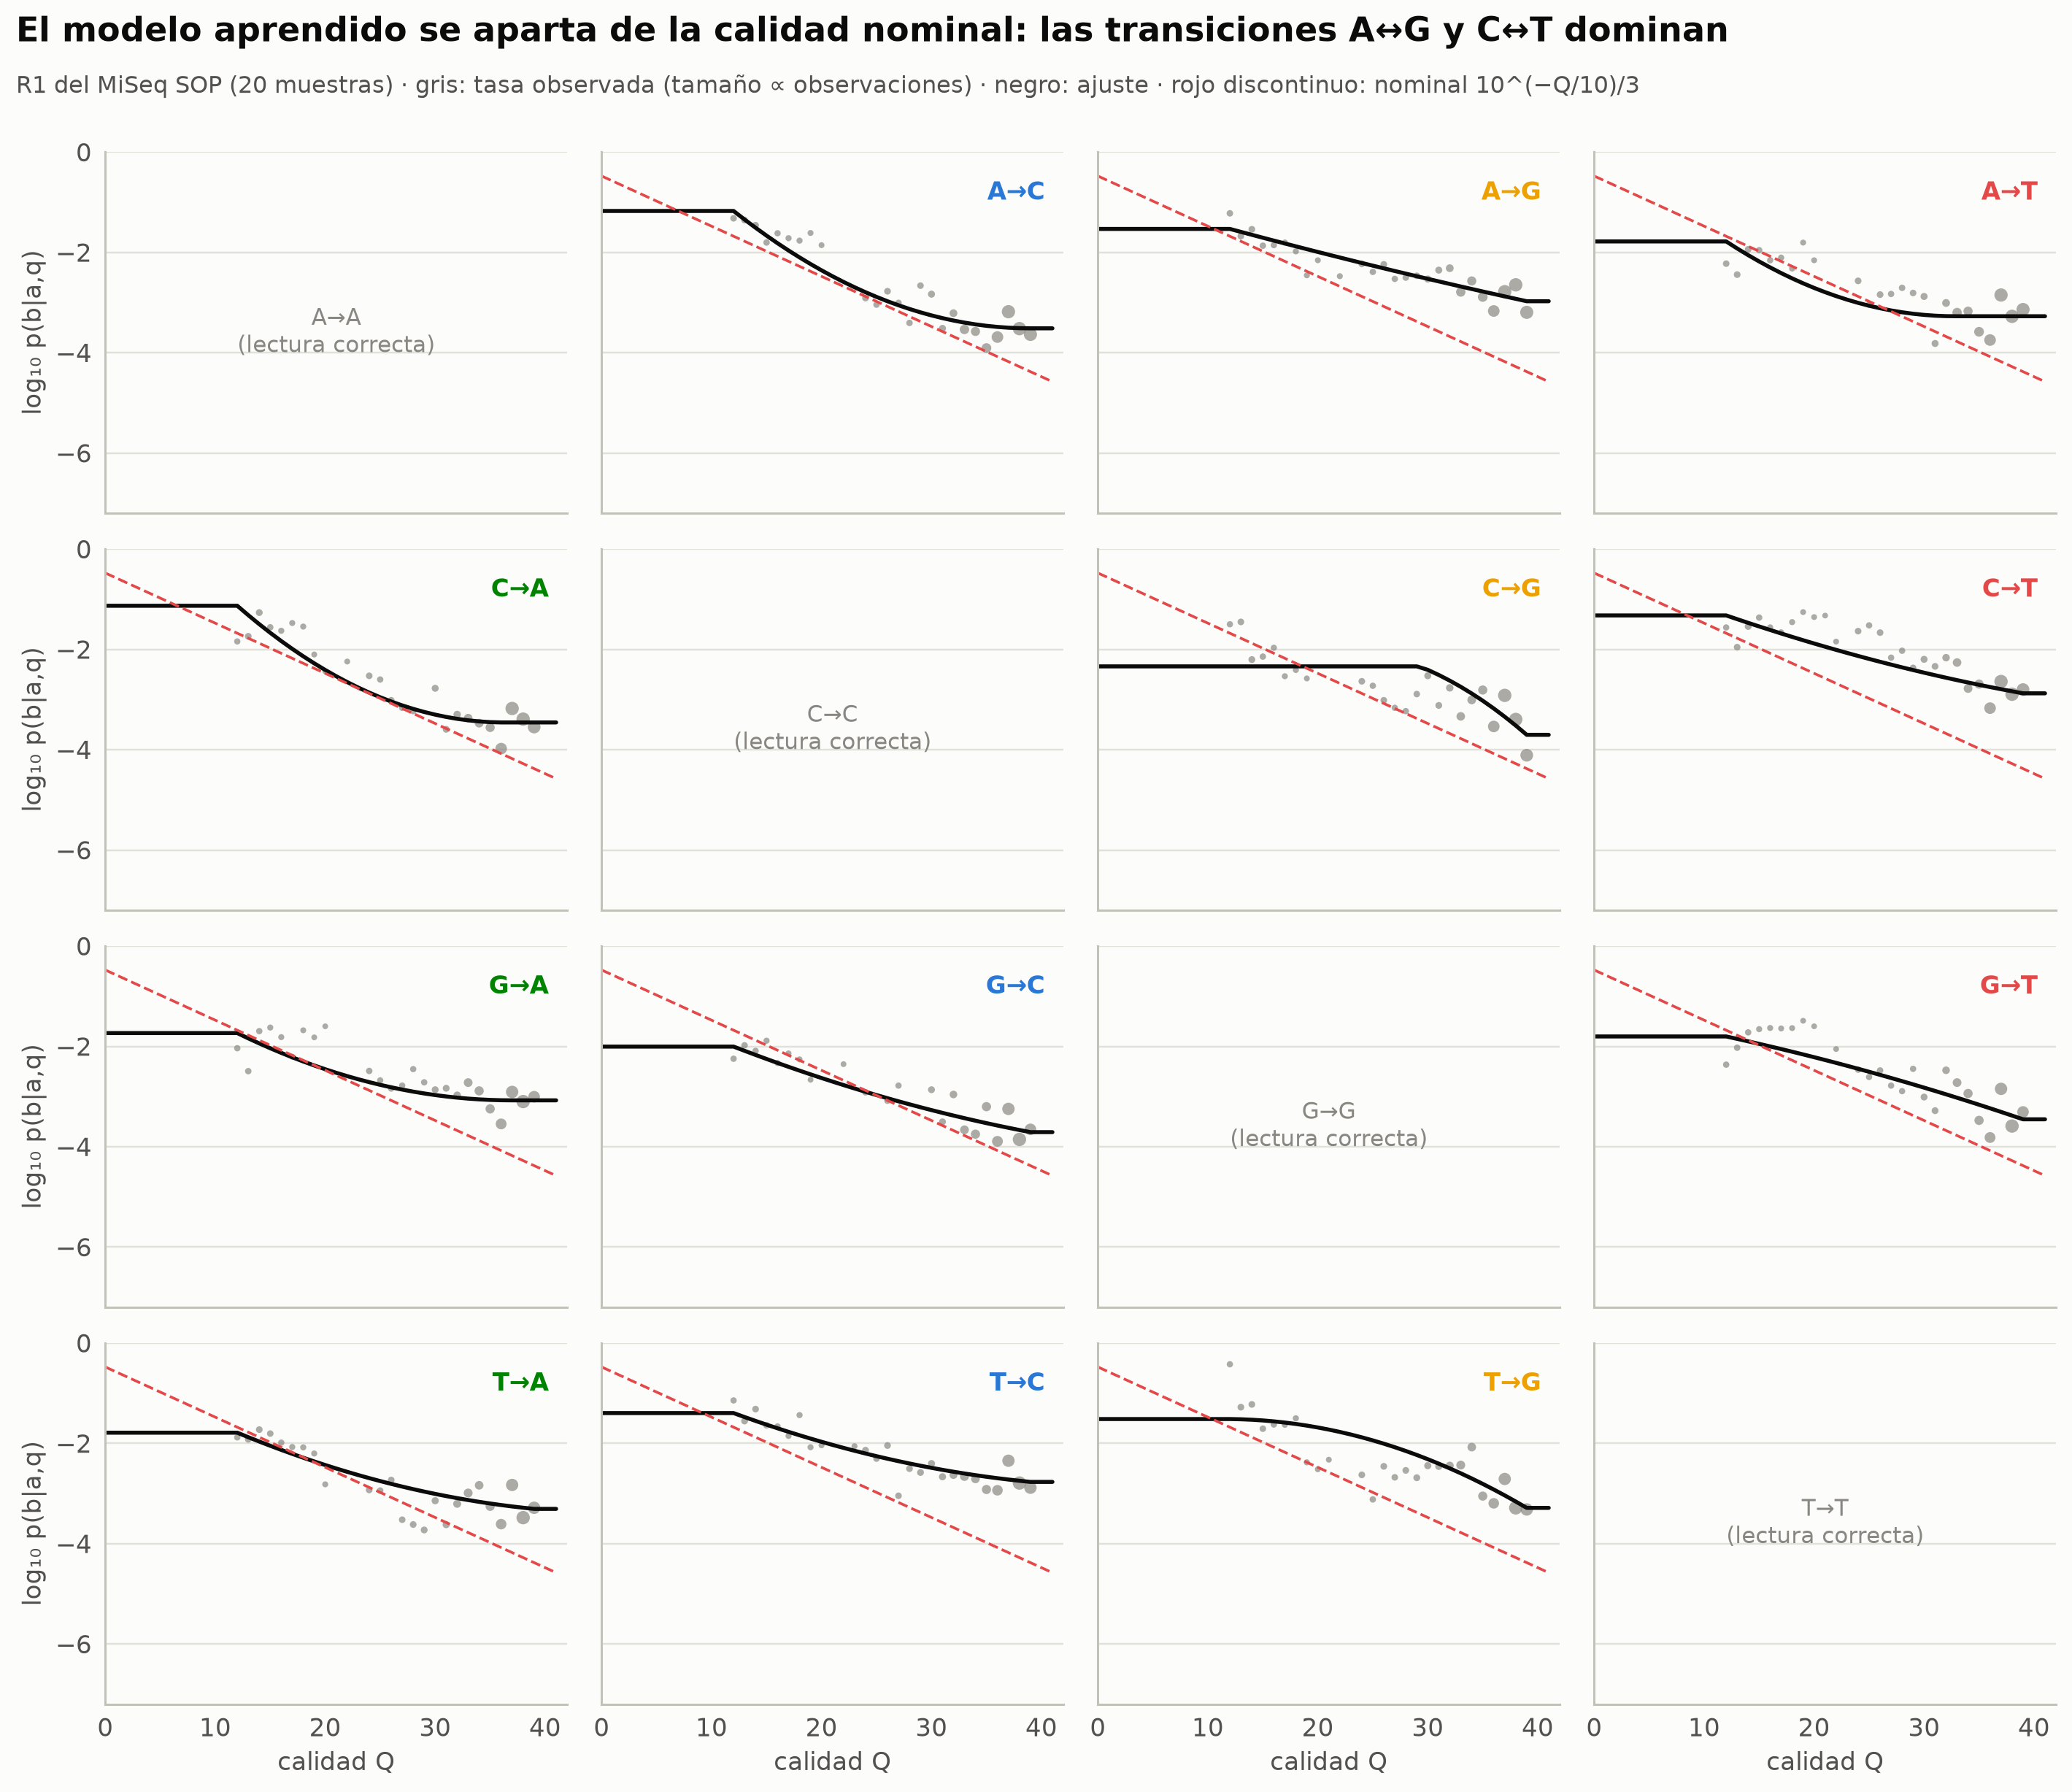

In [23]:
q = np.arange(QMAX + 1)
fig, axes = plt.subplots(4, 4, figsize=(13, 10.5), sharex=True, sharey=True)
T, E = TRANS["F"], ERR["F"]
for a in range(4):
    for b in range(4):
        ax = axes[a, b]
        tot = T[a].sum(0); w = tot > 50
        obs = np.where(w, T[a, b] / np.maximum(tot, 1), np.nan)
        if a == b:
            ax.text(0.5, 0.5, f"{BASES[a]}→{BASES[b]}\n(lectura correcta)", transform=ax.transAxes, ha="center",
                    va="center", color=ec.MUTED, fontsize=10)
        else:
            ok = w & (obs > 0)
            ax.scatter(q[ok], np.log10(obs[ok]), s=6 + 30 * np.sqrt(tot[ok] / tot.max()), color=ec.MUTED, alpha=0.7, lw=0)
            ax.plot(q, np.log10(E[a, b]), color=ec.INK, lw=1.8)
            ax.plot(q, np.log10(10 ** (-q / 10) / 3), color=ec.RED, lw=1.2, ls="--")
            ax.text(0.96, 0.92, f"{BASES[a]}→{BASES[b]}", transform=ax.transAxes, ha="right", va="top",
                    fontweight="bold", color=ec.NUC_COLORS[BASES[b]])
        ax.set_ylim(-7.2, 0); ax.set_xlim(0, 42)
        if a == 3: ax.set_xlabel("calidad Q")
        if b == 0: ax.set_ylabel("log₁₀ p(b|a,q)")
ec.fig_title(fig, "El modelo aprendido se aparta de la calidad nominal: las transiciones A↔G y C↔T dominan",
             "R1 del MiSeq SOP (20 muestras) · gris: tasa observada (tamaño ∝ observaciones) · negro: ajuste · rojo discontinuo: nominal 10^(−Q/10)/3")
fig.tight_layout()
plt.show()

> 🔎 **Qué observamos.** En casi todos los paneles las tasas caen al subir la calidad, como exige cualquier modelo sensato;
> pero no siguen exactamente la línea nominal. Las **transiciones** (A→G, G→A, C→T, T→C) son más frecuentes que las
> transversiones, algo que la calidad Phred ignora (reparte el error por igual entre tres bases). En la zona de calidad
> alta, las tasas observadas quedan por encima de lo nominal: allí se mezclan los errores de la **PCR**, que ocurren antes
> de la secuenciación y no se reflejan en la calidad. Por eso DADA2 aprende la matriz de cada corrida.

### 8.4 🎬 Las particiones crecen: el algoritmo en acción sobre la *mock*

La animación sigue el algoritmo divisivo sobre las lecturas directas de la comunidad *mock*, con el modelo de error ya
aprendido. A la izquierda, cada punto es una secuencia única (tamaño ∝ abundancia) colocada en el plano según sus
distancias de Hamming (escalamiento multidimensional clásico); una línea fina la une con el centro de su partición. En
cada cuadro, la secuencia más sorprendente (menor $p_A$) se convierte en un nuevo centro (estrella naranja). A la
derecha, $-\log_{10} p_A$ de esa secuencia en cada iteración (cuanto más alto, más sorprendente): el algoritmo se
detiene cuando ya ninguna secuencia supera la línea de $\Omega_A = 10^{-40}$.

![El algoritmo divisivo de DADA2 sobre las lecturas reales de la comunidad mock: cada iteración convierte la secuencia más sorprendente en un nuevo centro, hasta que ningún valor p baja de 10⁻⁴⁰](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.1_particiones.gif)

*El algoritmo divisivo de DADA2 sobre las lecturas reales de la comunidad mock: cada iteración convierte la secuencia más sorprendente en un nuevo centro, hasta que ningún valor p baja de 10⁻⁴⁰*

In [24]:
U, cnt, Qm, _ = derep["F"]["Mock"]
cM, aM, lpM, hist = dada(U, cnt, Qm, ERR["F"], trace=True)
# Escalamiento multidimensional clásico (PCoA) de las distancias de Hamming entre únicas
D = (U[:, None, :] != U[None, :, :]).sum(2).astype(float)
n = len(D); J = np.eye(n) - 1 / n
Bm = -0.5 * J @ (D ** 2) @ J
w_, v_ = np.linalg.eigh(Bm); idx = np.argsort(w_)[::-1][:2]
XY = v_[:, idx] * np.sqrt(np.maximum(w_[idx], 0))
sizes = 8 + 3 * cnt
min_lp = [-h["lp"][h["next"]] for h in hist]          # −log10 p_A (positivo)
print(f"{len(hist)} iteraciones · {len(cM)} ASVs · p_A mínimo en la última iteración: 10^{hist[-1]['lp'][hist[-1]['next']]:.1f}")

frames = [0] * 3 + list(range(len(hist))) + [len(hist) - 1] * 5
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw=dict(width_ratios=[1.35, 1]))

def update(f):
    k = frames[f]; h = hist[k]
    axL.clear(); axR.clear()
    cen = h["centers"]; asg = h["assign"]
    for j in range(n):                          # líneas secuencia -> centro
        c = cen[asg[j]]
        if c != j:
            axL.plot([XY[j, 0], XY[c, 0]], [XY[j, 1], XY[c, 1]], color=ec.GRID, lw=0.6, zorder=1)
    axL.scatter(XY[:, 0], XY[:, 1], s=sizes, color=ec.MUTED, alpha=0.55, lw=0, zorder=2)
    axL.scatter(XY[cen, 0], XY[cen, 1], s=sizes[cen] + 80, marker="*", color=ec.BLUE, zorder=3)
    nxt = h["next"]; lpn = h["lp"][nxt]
    last = lpn >= OMEGA_A
    if not last:
        axL.scatter(XY[nxt, 0], XY[nxt, 1], s=sizes[nxt] + 260, marker="*", color=ec.ORANGE, edgecolor=ec.INK, zorder=4)
    axL.set_xticks([]); axL.set_yticks([])
    for sp in axL.spines.values(): sp.set_visible(False)
    axL.set_title(f"Iteración {k + 1}: {len(cen)} partición(es)" + ("  ·  fin" if last else ""), loc="left", fontsize=12)
    axL.text(0.0, -0.06, ("siguiente centro: secuencia con a_j = %d, log₁₀ p_A = %.0f" % (cnt[nxt], lpn))
             if not last else f"ninguna secuencia baja de 10⁻⁴⁰ → {len(cen)} ASVs",
             transform=axL.transAxes, fontsize=10.5, color=ec.ORANGE if not last else ec.BLUE)
    xs = np.arange(1, k + 2)
    axR.plot(np.arange(1, len(min_lp) + 1), min_lp, color=ec.GRID, lw=1)
    axR.plot(xs, min_lp[:k + 1], "o-", color=ec.BLUE, ms=5)
    axR.axhline(-OMEGA_A, color=ec.RED, ls="--"); axR.text(len(min_lp), -OMEGA_A * 0.72, "Ω_A = 10⁻⁴⁰", color=ec.RED,
                                                           ha="right", va="top", fontsize=10)
    axR.set_yscale("log")
    axR.set_xlim(0.5, len(min_lp) + 0.5); axR.set_ylim(8, max(min_lp) * 3)
    axR.set_xlabel("iteración"); axR.set_ylabel("−log₁₀ p_A de la secuencia más sorprendente")
    axR.set_title("Cuán sorprendente es el nuevo centro (escala log)", loc="left", fontsize=12)
    return []

ec.animate(fig, update, frames=len(frames), interval=450, name="14.1_particiones")

19 iteraciones · 19 ASVs · p_A mínimo en la última iteración: 10^-16.4


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio todas las secuencias cuelgan del centro más abundante, y hay cepas enteras de la
> *mock* "mal explicadas": su $p_A$ es astronómicamente pequeño. En las primeras iteraciones se separan las cepas más
> abundantes (valores $p$ del orden de $10^{-10\,000}$: una cepa entera a decenas de nucleótidos es imposible como
> error); a medida que avanzan, los nuevos centros son cada vez menos abundantes y sus valores $p$ se acercan al umbral
> (la última ASV aún tiene $p_A \approx 10^{-120}$). Cuando la secuencia más sorprendente ya no lo es lo suficiente (aquí,
> $10^{-16}$), el algoritmo se detiene: la nube de errores queda colgando de sus centros como satélites.

### 8.5 La figura del libro, ahora con datos reales

Repetimos la figura 14.3 para la *mock*: cada secuencia única de R1 según su distancia al centro de su partición y su
abundancia. Los rombos son las ASVs inferidas.

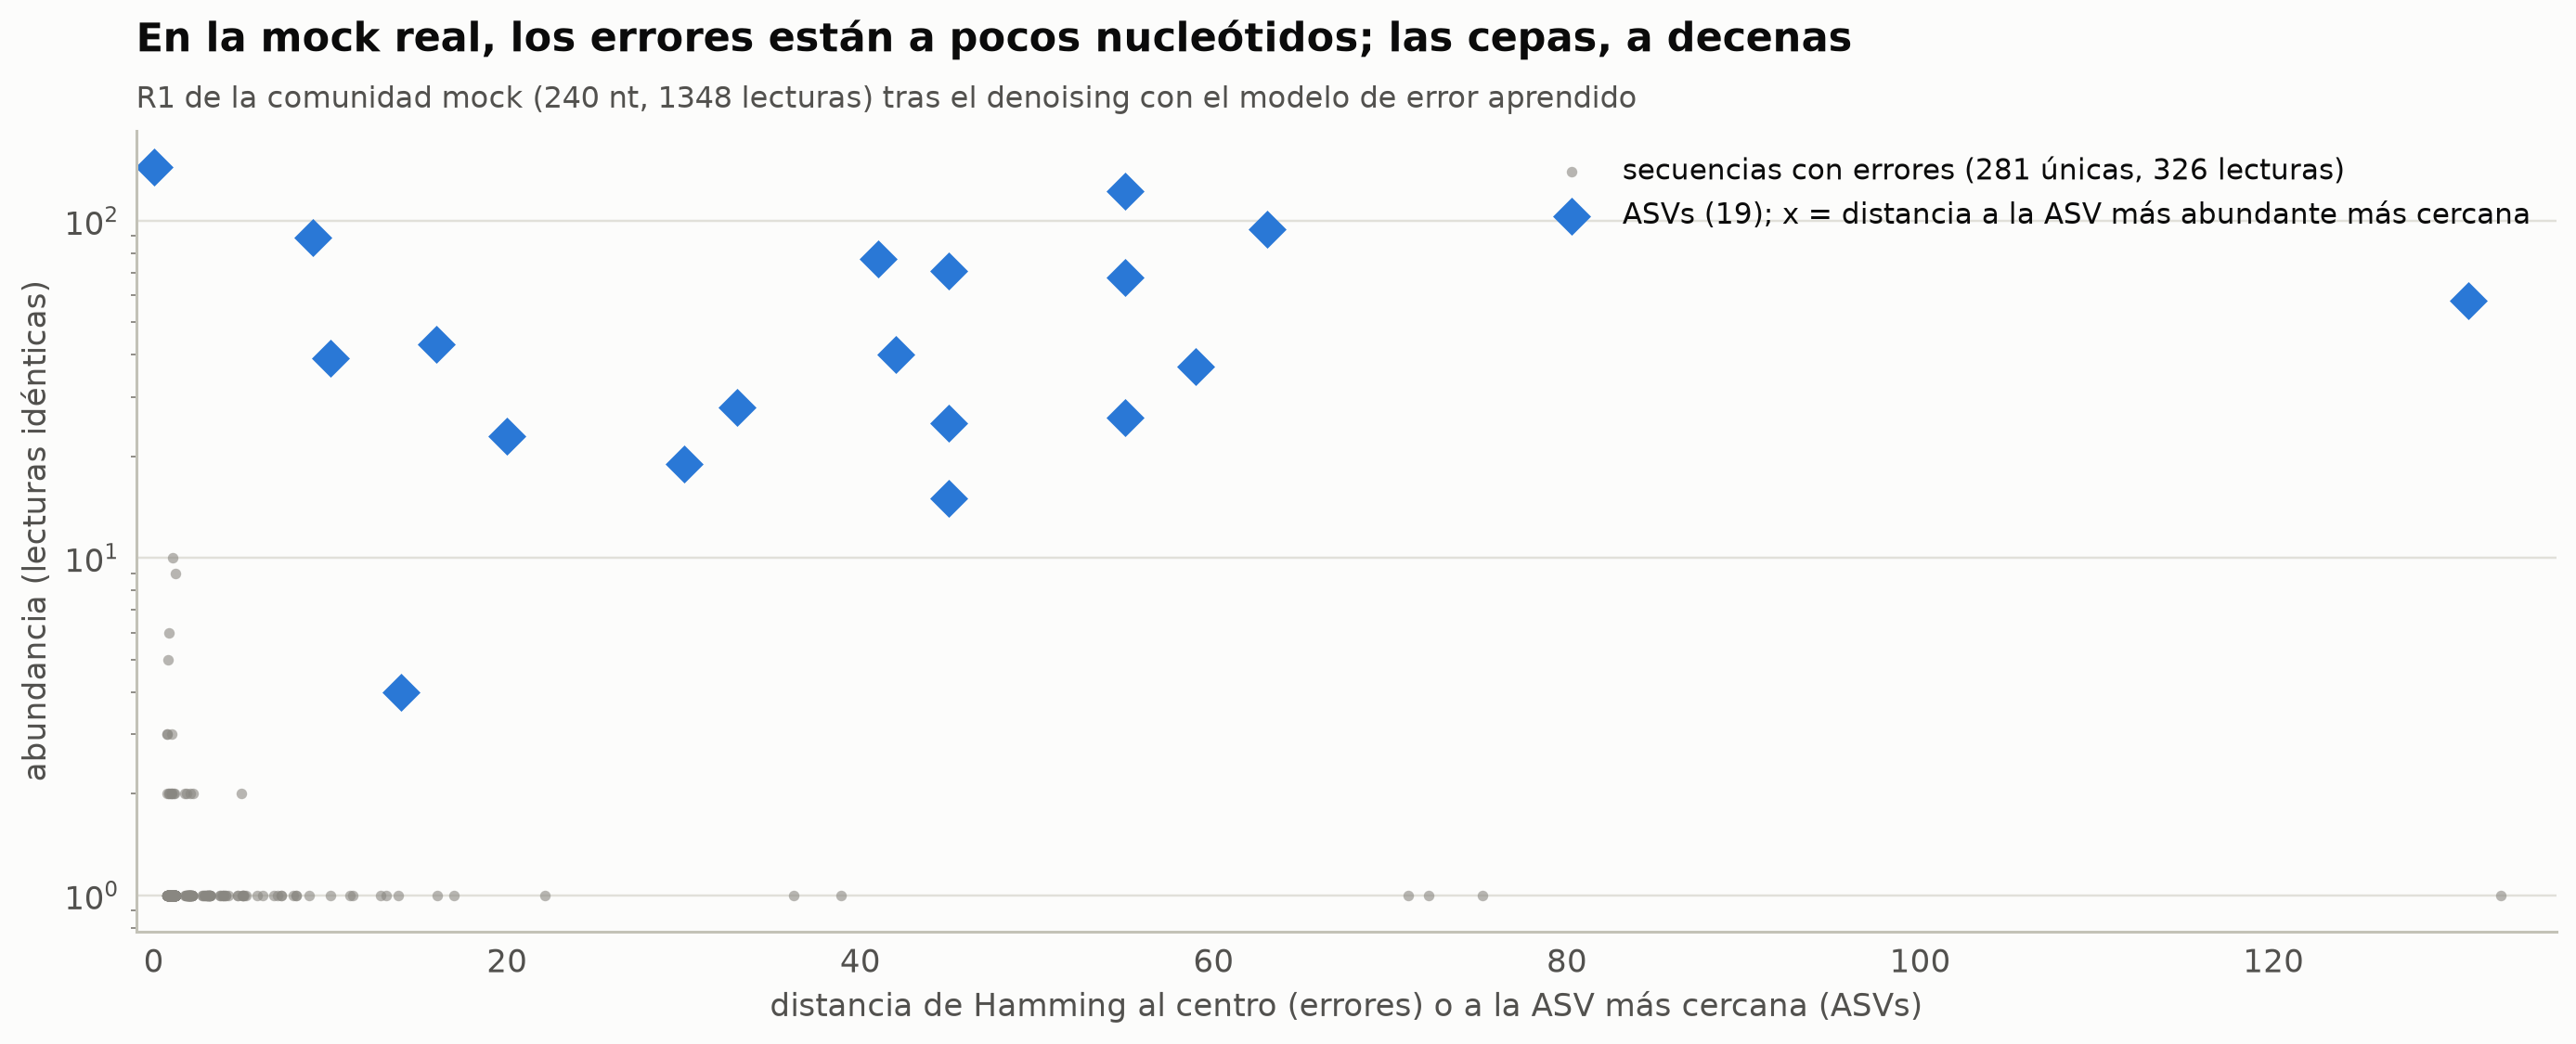

Error más abundante: 10 copias · distancia mínima entre dos ASVs: 9 nt


In [25]:
dist_c = np.array([(U[j] != U[cM[aM[j]]]).sum() for j in range(len(U))])
is_c = np.zeros(len(U), bool); is_c[cM] = True
dist_nn = np.array([min((U[j] != U[c]).sum() for c in cM[:list(cM).index(j)]) if j != cM[0] else 0 for j in cM])
jit = np.random.default_rng(7).uniform(-0.25, 0.25, len(U))
fig, ax = plt.subplots(figsize=(12.5, 5))
ax.scatter(dist_c[~is_c] + jit[~is_c], cnt[~is_c], s=14, color=ec.MUTED, alpha=0.6, lw=0,
           label=f"secuencias con errores ({(~is_c).sum()} únicas, {cnt[~is_c].sum()} lecturas)")
ax.scatter(dist_nn, cnt[cM], s=90, marker="D", color=ec.BLUE, edgecolor="#0d366b",
           label=f"ASVs ({len(cM)}); x = distancia a la ASV más abundante más cercana")
ax.set_yscale("log"); ax.set_xlabel("distancia de Hamming al centro (errores) o a la ASV más cercana (ASVs)")
ax.set_ylabel("abundancia (lecturas idénticas)")
ax.legend(loc="upper right", frameon=False)
ax.set_xlim(-1, max(dist_nn.max(), dist_c.max()) + 3)
ec.title(ax, "En la mock real, los errores están a pocos nucleótidos; las cepas, a decenas",
         f"R1 de la comunidad mock (240 nt, {cnt.sum()} lecturas) tras el denoising con el modelo de error aprendido")
plt.show()
print(f"Error más abundante: {cnt[~is_c].max()} copias · distancia mínima entre dos ASVs: {dist_nn[1:].min()} nt")

> 🔎 **Qué observamos.** A diferencia de la simulación, en la *mock* real las cepas están separadas por decenas de
> nucleótidos (géneros distintos), y la nube de errores se concentra a 1–5 nucleótidos de su centro, con abundancias de
> una o dos copias. La separación es nítida: la dificultad real aparece en muestras naturales, donde hay variantes a uno
> o dos nucleótidos de distancia (cepas de la misma especie, copias del operón).

### 8.6 Unir los pares

Ahora cada lectura directa pertenece a una ASV de R1 y cada lectura reversa a una ASV de R2. Para cada par de ASVs
observado, tomamos el **reverso complementario** de la ASV de R2 y buscamos el mayor solapamiento exacto (al menos 12
nucleótidos, sin desajustes: son los parámetros de este cuaderno) entre el final de R1 y el principio de R2
reverso-complementada. Como ambos extremos ya están corregidos, un desajuste en el solapamiento delata un par mal
explicado (por ejemplo, una ASV de R1 con una ASV espuria de R2) y el par se descarta.

In [26]:
def merge_pair(f, r, min_overlap=12):
    rr = revcomp(r)
    for ov in range(min(len(f), len(rr)), min_overlap - 1, -1):     # el mayor solapamiento primero
        if f[-ov:] == rr[:ov]:
            return f + rr[ov:], ov
    return None, 0

merged_counts = {}; overlaps = collections.Counter()
for s in SAMPLES:
    dF, dR = DEN["F"][s], DEN["R"][s]
    asvF = dF["assign"][dF["rank"]]; asvR = dR["assign"][dR["rank"]]     # ASV de cada lectura
    ctr = collections.Counter()
    for (i, j), npairs in collections.Counter(zip(asvF, asvR)).items():
        seq, ov = merge_pair(decode(dF["U"][dF["centers"][i]]), decode(dR["U"][dR["centers"][j]]))
        if seq:
            ctr[seq] += npairs; overlaps[ov] += npairs
    merged_counts[s] = ctr
seqtab = pd.DataFrame(merged_counts).fillna(0).astype(int)
seqtab = seqtab.loc[seqtab.sum(axis=1).sort_values(ascending=False).index]
track["denoisedF"] = [len(DEN["F"][s]["centers"]) for s in SAMPLES]
track["denoisedR"] = [len(DEN["R"][s]["centers"]) for s in SAMPLES]
track["merged"] = seqtab.sum()[SAMPLES].values
lens = seqtab.index.str.len()
print(f"Tabla de secuencias unidas: {seqtab.shape[0]} secuencias × {seqtab.shape[1]} muestras")
print("Longitudes (nt → nº de secuencias):", dict(sorted(collections.Counter(lens).items())))
len_reads = seqtab.groupby(lens).sum().sum(axis=1)
print("Lecturas por longitud del amplicón unido:", {int(k): int(v) for k, v in len_reads.items()})
print("Pares por solapamiento:", dict(sorted(overlaps.items())))
print(f"Solapamiento más frecuente: {overlaps.most_common(1)[0][0]} nt · pares unidos: {track.merged.sum():,} de "
      f"{track.filtered.sum():,} ({track.merged.sum()/track.filtered.sum():.1%})")

Tabla de secuencias unidas: 162 secuencias × 20 muestras


Longitudes (nt → nº de secuencias): {251: 1, 252: 32, 253: 123, 254: 4, 255: 2}
Lecturas por longitud del amplicón unido: {251: 19, 252: 13898, 253: 9857, 254: 275, 255: 41}
Pares por solapamiento: {145: 41, 146: 275, 147: 9857, 148: 13898, 149: 19}
Solapamiento más frecuente: 148 nt · pares unidos: 24,090 de 27,448 (87.8%)


> 🔎 **Qué observamos.** La mayoría de las **secuencias** unidas miden 253 nt, como predice el 16S de *E. coli*
> (solapamiento $240 + 160 - 253 = 147$), con algunas de 252 y 254: linajes con pequeñas inserciones o deleciones en V4.
> Pero si contamos **lecturas**, domina la longitud de 252 (solapamiento de 148 nt): las ASVs más abundantes del ratón
> pertenecen a *Muribaculaceae* (Bacteroidetes), cuyo V4 es un nucleótido más corto que el de *E. coli*. Se une la gran mayoría de los pares; los que no se unen suelen combinar una ASV
> real con otra espuria o con un error no corregido en el solapamiento. Longitudes muy distintas de 253 serían sospechosas
> (productos inespecíficos) y conviene descartarlas.

## 9. Quimeras y el ajuste de cuentas OTU frente a ASV

### 9.1 Cómo nace una quimera

Durante la PCR, una hebra cuya extensión quedó incompleta puede, en el ciclo siguiente, hibridarse con un molde
**distinto** y completarse copiándolo. El producto es una **quimera**: su extremo 5′ procede de un organismo (padre A) y
su extremo 3′ de otro (padre B). Las quimeras **no tienen errores de secuenciación**, así que un modelo de error no las
detecta; pueden ser abundantes y fáciles de confundir con organismos nuevos.

La detección aprovecha una asimetría: una quimera se forma a partir de dos padres que, al estar en la misma PCR, suelen
ser **más abundantes** que ella. UCHIME (Edgar *et al.*, 2011) busca, para cada secuencia candidata, dos secuencias más
abundantes cuya combinación (un segmento izquierdo de una y un segmento derecho de la otra) la explique mejor que
cualquier secuencia individual. DADA2 aplica la versión **exacta** de esta idea sobre las ASVs: marca como **bimera** toda
variante que pueda reconstruirse **sin errores** uniendo un prefijo de un padre más abundante con un sufijo de otro.

Ejemplo a mano con secuencias de 12 nt:

| | secuencia | prefijo común más largo con la candidata | sufijo común más largo |
|---|---|---|---|
| padre A (800 lecturas) | `ACGT`**`T`**`GCA`**`A`**`TGC` | — | — |
| padre B (500 lecturas) | `ACGT`**`C`**`GCA`**`G`**`TGC` | — | — |
| candidata (40 lecturas) | `ACGTTGCAGTGC` | con A: 8 (`ACGTTGCA`); con B: 4 | con B: 7 (`GCAGTGC`); con A: 3 |

Como el prefijo de A cubre las posiciones 1–8 y el sufijo de B cubre las posiciones 6–12, juntos cubren las 12: la
candidata es A hasta la posición 8 y B desde la 9. Es una bimera. La regla general: si $\mathrm{LCP}(s, A) +
\mathrm{LCS}(s, B) \ge |s|$ para dos padres distintos, $s$ es explicable sin ningún error como mezcla de ambos.

Nuestra implementación reúne las ASVs de todas las muestras (con su abundancia total) y exige que cada padre sea al menos
**el doble** de abundante que la candidata (parámetro `fold = 2` de este cuaderno).

In [27]:
def lcp(a, b):
    """Longitud del prefijo común más largo de dos cadenas."""
    n = min(len(a), len(b))
    x = np.frombuffer(a[:n].encode(), np.uint8) != np.frombuffer(b[:n].encode(), np.uint8)
    return int(np.argmax(x)) if x.any() else n

def find_bimera(k, seqs, abundance, fold=2.0):
    """¿Es seqs[k] un prefijo exacto de un padre + un sufijo exacto de otro, ambos ≥ fold veces más abundantes?"""
    s = seqs[k]
    parents = [p for p in range(len(seqs)) if abundance[p] >= fold * abundance[k]]
    if len(parents) < 2:
        return None
    left = [lcp(s, seqs[p]) for p in parents]
    right = [lcp(s[::-1], seqs[p][::-1]) for p in parents]
    if max(left) == len(s) or max(right) == len(s):
        return None
    bl, br = int(np.argmax(left)), int(np.argmax(right))
    if left[bl] + right[br] >= len(s) and parents[bl] != parents[br]:
        return parents[bl], parents[br], left[bl], right[br]
    return None

# el ejemplo a mano
toy = ["ACGTTGCAATGC", "ACGTCGCAGTGC", "ACGTTGCAGTGC"]
print("Ejemplo a mano →", find_bimera(2, toy, [800, 500, 40]),
      "(padre izquierdo, padre derecho, LCP, LCS)")

asv_seqs = list(seqtab.index); asv_tot = seqtab.sum(axis=1).values
bimeras = {k: find_bimera(k, asv_seqs, asv_tot) for k in range(len(asv_seqs))}
bimeras = {k: v for k, v in bimeras.items() if v}
is_bim = np.zeros(len(asv_seqs), bool); is_bim[list(bimeras)] = True
print(f"Bimeras: {is_bim.sum()} de {len(asv_seqs)} secuencias ({is_bim.sum()/len(asv_seqs):.1%}), "
      f"que suman {asv_tot[is_bim].sum()} lecturas ({asv_tot[is_bim].sum()/asv_tot.sum():.2%})")
seqtab_nc = seqtab.loc[~is_bim]
track["nonchim"] = seqtab_nc.sum()[SAMPLES].values
print(track.to_string())

Ejemplo a mano → (0, 1, 8, 7) (padre izquierdo, padre derecho, LCP, LCS)
Bimeras: 8 de 162 secuencias (4.9%), que suman 111 lecturas (0.46%)
        input  filtered  denoisedF  denoisedR  merged  nonchim
F3D0     1500      1363         69         59    1178     1178
F3D1     1500      1354         65         60    1236     1236
F3D2     1500      1387         55         49    1217     1217
F3D3     1500      1392         42         30    1254     1204
F3D5     1500      1364         64         57    1197     1197
F3D6     1500      1390         61         48    1209     1209
F3D7     1500      1398         50         42    1281     1245
F3D8     1500      1378         68         56    1239     1239
F3D9     1500      1396         76         63    1216     1216
F3D141   1500      1363         50         43    1240     1240
F3D142   1500      1373         45         39    1167     1167
F3D143   1500      1385         52         45    1211     1211
F3D144   1500      1346         36      

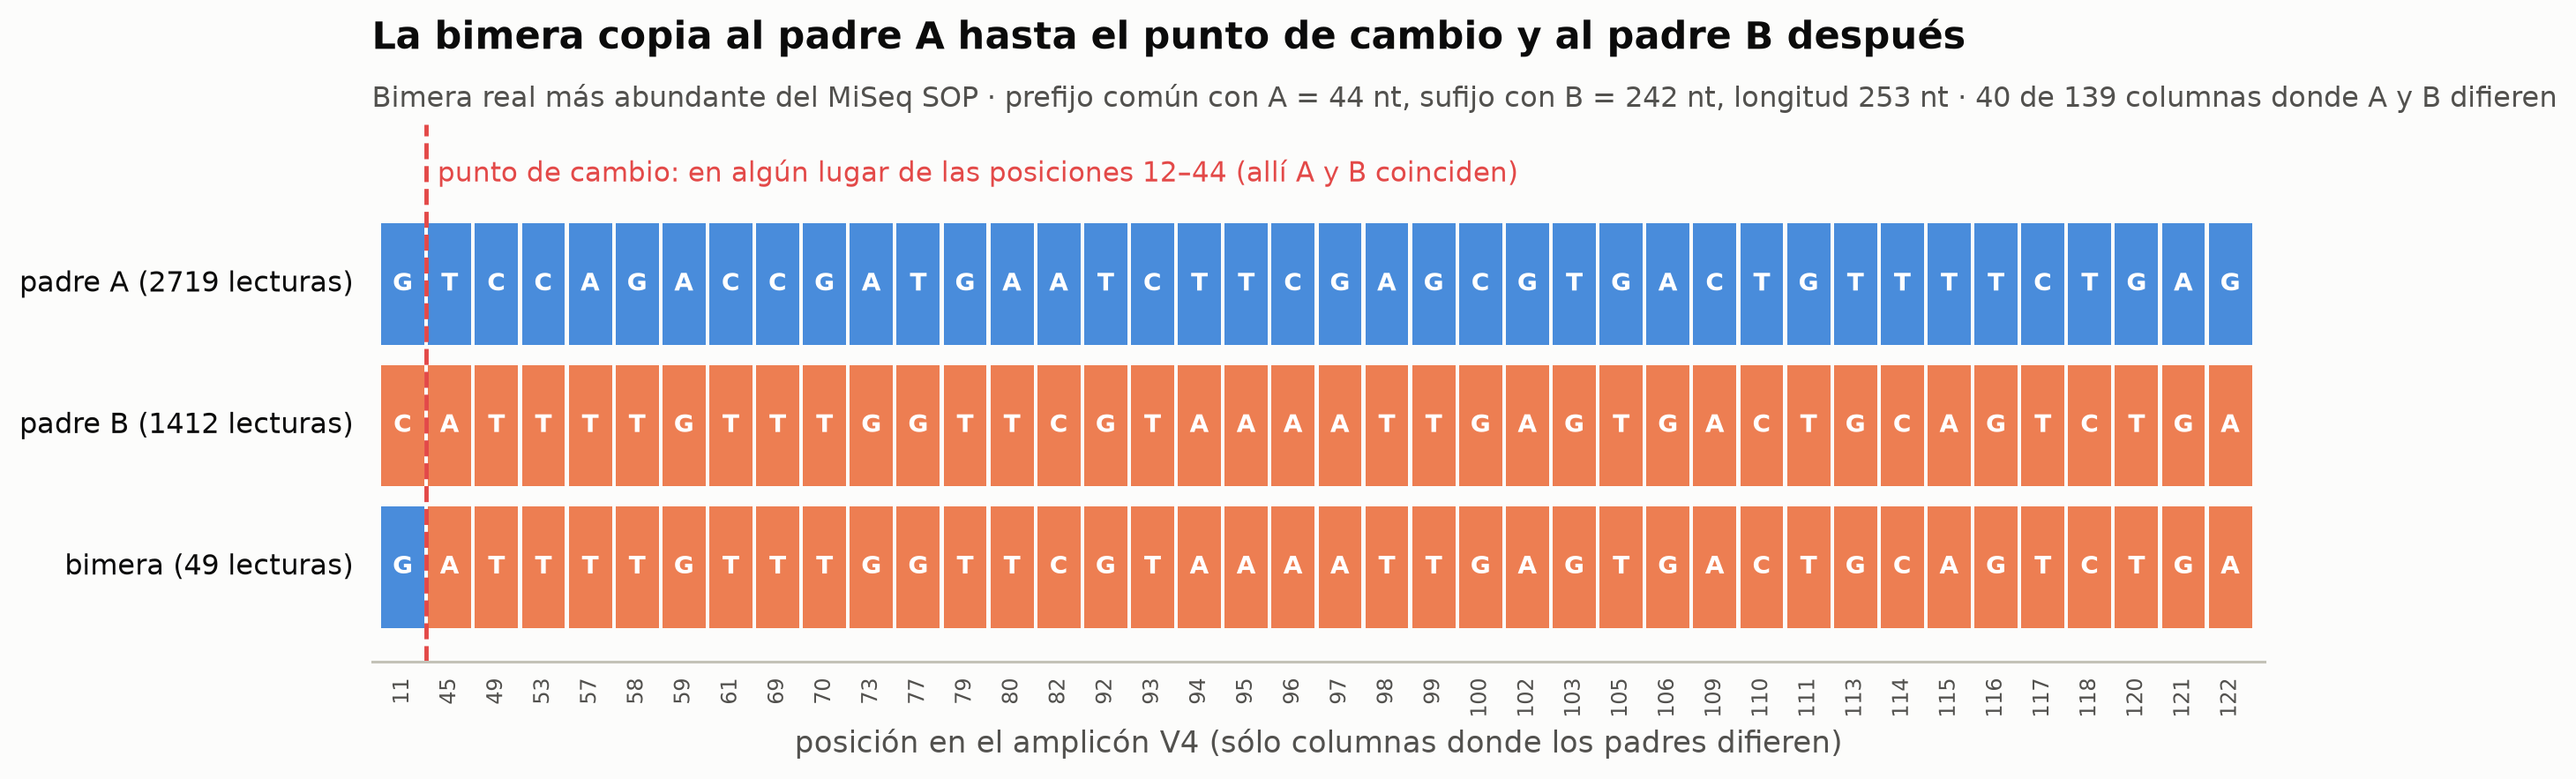

In [28]:
k_show = max(bimeras, key=lambda k: asv_tot[k])
pA, pB, lA, lB = bimeras[k_show]
sA, sB, sC = asv_seqs[pA], asv_seqs[pB], asv_seqs[k_show]
Lc = len(sC)
diff_all = [p for p in range(min(len(sA), len(sB), Lc)) if sA[p] != sB[p]]
diff_cols = diff_all[:40]                         # las primeras 40 columnas informativas (rodean el punto de cambio)
fig, ax = plt.subplots(figsize=(13, 3.9))
rows = [(f"padre A ({asv_tot[pA]} lecturas)", sA, ec.BLUE), (f"padre B ({asv_tot[pB]} lecturas)", sB, ec.ORANGE),
        (f"bimera ({asv_tot[k_show]} lecturas)", sC, None)]
for r, (lab, s, col) in enumerate(rows):
    for k, p in enumerate(diff_cols):
        b = s[p] if p < len(s) else "-"
        if col is None:        # la quimera: color del padre con el que coincide en esa columna
            ccol = ec.BLUE if (p < lA and b == sA[p]) else (ec.ORANGE if b == sB[p] else ec.RED)
        else:
            ccol = col
        ax.add_patch(Rectangle((k, r), 0.92, 0.86, color=ccol, alpha=0.85, lw=0))
        ax.text(k + 0.46, r + 0.43, b, ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(-0.6, r + 0.43, lab, ha="right", va="center", fontsize=10.5)
brk = sum(1 for p in diff_cols if p < lA)
ax.axvline(brk - 0.04, color=ec.RED, ls="--", lw=1.6)
ax.text(brk + 0.2, -0.25, f"punto de cambio: en algún lugar de las posiciones {Lc - lB + 1}–{lA} (allí A y B coinciden)",
        color=ec.RED, fontsize=10, va="bottom")
ax.set_xlim(-0.2, len(diff_cols) + 0.2); ax.set_ylim(3.1, -0.7)
ax.set_xticks(np.arange(len(diff_cols)) + 0.46); ax.set_xticklabels([p + 1 for p in diff_cols], rotation=90, fontsize=8)
ax.set_yticks([])
for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
ax.grid(False)
ax.set_xlabel("posición en el amplicón V4 (sólo columnas donde los padres difieren)")
ec.title(ax, "La bimera copia al padre A hasta el punto de cambio y al padre B después",
         f"Bimera real más abundante del MiSeq SOP · prefijo común con A = {lA} nt, sufijo con B = {lB} nt, longitud {Lc} nt · "
         f"{len(diff_cols)} de {len(diff_all)} columnas donde A y B difieren")
plt.show()

> 🔎 **Qué observamos.** En las columnas donde los padres difieren, la bimera coincide con A (azul) antes del punto de
> cambio y con B (naranja) después, sin una sola base propia: no hay nada que un modelo de error pueda "corregir". En
> estos datos submuestreados las bimeras son pocas y de baja abundancia; en corridas completas pueden representar una
> fracción apreciable de las secuencias únicas, aunque una fracción pequeña de las lecturas.

### 9.2 Ajuste de cuentas: OTUs frente a ASVs en la *mock*

Ya podemos responder la pregunta de la sección 1 con los dos métodos, sobre la misma comunidad de composición conocida.

ASVs en la mock: 19 · coinciden exactamente con la referencia: 19 · cepas detectadas: 20
Cepas no detectadas: P.acnes
ASVs compartidas por varias cepas (V4 idéntica): [['S.aureus', 'S.epidermidis']]

Ratón: 138 ASVs → 115 OTUs al 97 %; 21 OTUs contienen ≥ 2 ASVs (la mayor reúne 3 ASVs)
Mock, lecturas filtradas: 37 OTUs al 97 % (18 espurias; 21 con ≥ 2 lecturas)


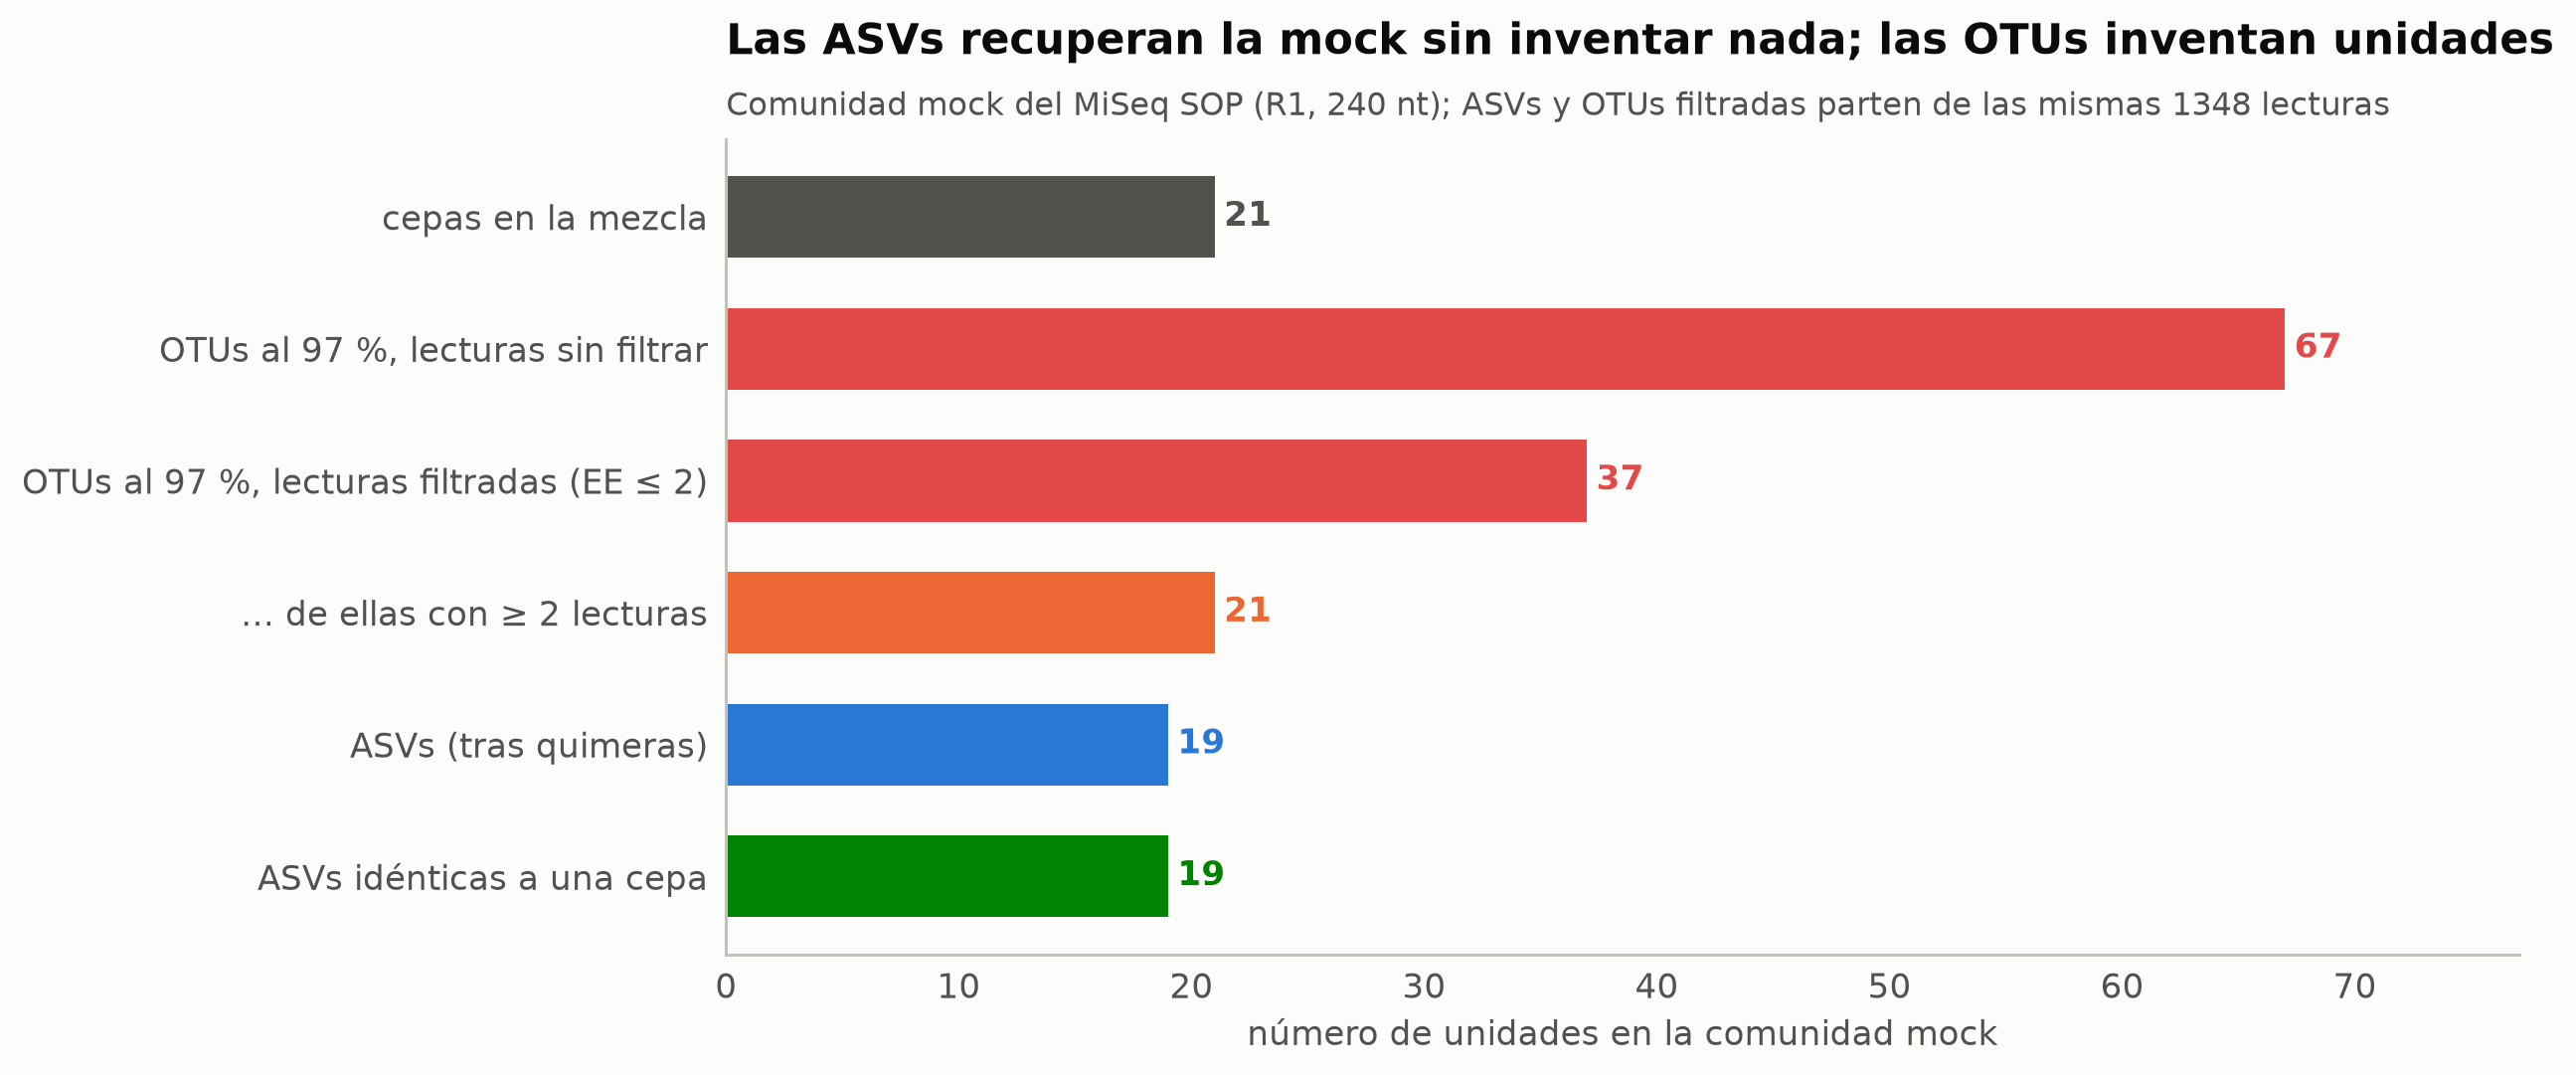

In [29]:
mock_asvs = seqtab_nc["Mock"][seqtab_nc["Mock"] > 0]
mock_hits = {s: mock_match(s) for s in mock_asvs.index}
exact = sum(1 for h in mock_hits.values() if h)
strains_asv = sorted({x for h in mock_hits.values() for x in h})
missing = sorted(set(mock_species) - set(strains_asv))
print(f"ASVs en la mock: {len(mock_asvs)} · coinciden exactamente con la referencia: {exact} · cepas detectadas: {len(strains_asv)}")
print("Cepas no detectadas:", ", ".join(missing) if missing else "ninguna")
shared = [h for h in mock_hits.values() if len(h) > 1]
print("ASVs compartidas por varias cepas (V4 idéntica):", shared)

# OTUs al 97 % sobre las ASVs de las muestras de ratón: ¿cuántas variantes reales se funden?
mouse = seqtab_nc.drop(columns="Mock"); mouse = mouse[mouse.sum(axis=1) > 0]
Uasv = np.array([[BASES.index(c) for c in s[:240]] for s in mouse.index], np.uint8)
c97, l97 = greedy_otus(Uasv, dmax=7)
multi = pd.Series(l97).value_counts()
print(f"\nRatón: {len(mouse)} ASVs → {len(c97)} OTUs al 97 %; {int((multi > 1).sum())} OTUs contienen ≥ 2 ASVs "
      f"(la mayor reúne {multi.max()} ASVs)")

# OTUs con las MISMAS lecturas filtradas (EE ≤ 2) que entraron al denoising
Uf, cf, _, _ = dereplicate(F[smp == "Mock"])
cfo, lfo = greedy_otus(Uf)
sizef = np.bincount(lfo, weights=cf)
realf = np.array([len(mock_match(decode(Uf[c]))) > 0 for c in cfo])
print(f"Mock, lecturas filtradas: {len(cfo)} OTUs al 97 % ({(~realf).sum()} espurias; {(sizef >= 2).sum()} con ≥ 2 lecturas)")

fig, ax = plt.subplots(figsize=(11.5, 4.8))
bars = [("cepas en la mezcla", len(mock_species), ec.INK_2),
        ("OTUs al 97 %, lecturas sin filtrar", len(otu_res["Mock"][2]), ec.RED),
        ("OTUs al 97 %, lecturas filtradas (EE ≤ 2)", len(cfo), ec.RED),
        ("  … de ellas con ≥ 2 lecturas", int((sizef >= 2).sum()), ec.ORANGE),
        ("ASVs (tras quimeras)", len(mock_asvs), ec.BLUE),
        ("ASVs idénticas a una cepa", exact, ec.GREEN)]
for i, (lab, v, col) in enumerate(bars):
    ax.barh(i, v, color=col, height=0.62)
    ax.text(v + 0.4, i, str(v), va="center", fontsize=11, fontweight="bold", color=col)
ax.set_yticks(range(len(bars))); ax.set_yticklabels([b[0] for b in bars]); ax.invert_yaxis()
ax.set_xlabel("número de unidades en la comunidad mock"); ax.set_xlim(0, max(b[1] for b in bars) * 1.15)
ax.grid(axis="y", visible=False)
ec.title(ax, "Las ASVs recuperan la mock sin inventar nada; las OTUs inventan unidades",
         "Comunidad mock del MiSeq SOP (R1, 240 nt); ASVs y OTUs filtradas parten de las mismas 1348 lecturas")
plt.show()

> 🔎 **Qué observamos.** Todas las ASVs de la *mock* coinciden **exactamente**, base por base, con alguna secuencia de la
> referencia: el *denoising* no ha inventado ninguna variante, y esas 19 ASVs representan 20 de las 21 cepas
> (*S. aureus* y *S. epidermidis* comparten V4; falta *P. acnes*, muy poco abundante en la mezcla: con ~1300 lecturas
> queda por debajo de lo que el método puede afirmar). Las OTUs, con las mismas lecturas filtradas, producen casi el doble
> de unidades; el filtro de calidad reduce las espurias (de 67 a menos de 40), pero no las elimina, y descartar las OTUs
> de una lectura es un remiendo que también borraría variantes raras reales. En las muestras de ratón, agrupar al 97 % funde varias ASVs en una sola
> OTU: variantes reales a pocos nucleótidos, quizá cepas distintas con ecologías distintas, que las OTUs no ven.

> ✅ **Compruebe su comprensión.** ¿Por qué una ASV puede corresponder a varias cepas de la *mock* a la vez?
> *(Porque su región V4 es idéntica —como las siete copias de* E. coli *en la sección 2—: la ASV es exacta, pero su
> resolución taxonómica tiene un techo.)*

## 10. Asignación taxonómica: el clasificador bayesiano ingenuo

Una ASV es una secuencia sin nombre. Para darle uno, se compara con una base de datos de referencia curada. La más usada
es **SILVA** (Quast *et al.*, 2013), que mantiene alineamientos y una taxonomía revisada de los ARN ribosómicos de los
tres dominios; aquí usaremos el conjunto de entrenamiento 18 del **RDP**, más pequeño. El método clásico es el
**clasificador bayesiano ingenuo** del RDP (Wang *et al.*, 2007), que QIIME 2 reimplementa con scikit-learn.

La idea es representar cada secuencia por el **conjunto de sus palabras de longitud 8** (8-mers) y preguntar qué género
hace más probable ese conjunto. Una secuencia de 253 nt tiene hasta $253 - 8 + 1 = 246$ palabras distintas, de entre
$4^8 = 65\,536$ posibles. Para un género $G$ con $M$ secuencias de referencia, la probabilidad de que una secuencia de
$G$ contenga la palabra $w_i$ se estima como (ecuación 14.4 del libro)

$$P(w_i\mid G) = \frac{m(w_i) + P_i}{M + 1}, \qquad P_i = \frac{n(w_i) + 0{,}5}{N + 1},$$

y, suponiendo que las palabras son independientes (de ahí lo de "ingenuo"),

$$\log P(S\mid G) = \sum_{w_i \in S} \log P(w_i\mid G), \qquad \hat{G} = \arg\max_G\, P(S\mid G).$$

| Símbolo | Significado |
|---|---|
| $w_i$ | una palabra (8-mer) presente en la secuencia consulta $S$ |
| $m(w_i)$ | número de secuencias de referencia del género $G$ que contienen $w_i$ |
| $M$ | número de secuencias de referencia del género $G$ |
| $n(w_i),\ N$ | número de secuencias de **toda** la base que contienen $w_i$, y número total de secuencias |
| $P_i$ | probabilidad previa de la palabra; actúa como pseudoconteo para que una palabra nunca vista en $G$ no anule el producto |
| $\hat{G}$ | género asignado |

Con una probabilidad previa uniforme sobre géneros, maximizar $P(S\mid G)$ equivale a maximizar la posterior $P(G\mid S)$.
La **confianza** no se obtiene de esa posterior, que suele ser engañosamente cercana a 1, sino por **remuestreo**: se
repite la clasificación con 100 subconjuntos aleatorios de **un octavo** de las palabras y se cuenta en cuántas réplicas se
obtiene el mismo género. Si la confianza cae por debajo de un umbral, habitualmente el **80 %**, la asignación se trunca
al rango superior (familia, orden) en el que sí se alcanza.

### 10.1 Ejemplo del libro: tres géneros y cuatro palabras

Una base de juguete tiene $N = 125$ secuencias: 40 de *Bacteroides*, 25 de *Prevotella* y 60 de *Escherichia*. Una ASV
contiene cuatro palabras $w_1,\dots,w_4$, presentes en $n(w) = 59,\ 37,\ 61,\ 61$ secuencias de la base. Los conteos por
género son:

| Género ($M$) | $m(w_1)$ | $m(w_2)$ | $m(w_3)$ | $m(w_4)$ |
|---|---|---|---|---|
| *Bacteroides* (40) | 38 | 30 | 2 | 35 |
| *Prevotella* (25) | 20 | 3 | 1 | 24 |
| *Escherichia* (60) | 1 | 4 | 58 | 2 |

A mano, para *Bacteroides* y $w_1$: $P_1 = (59 + 0{,}5)/126 = 0{,}472$ y $P(w_1\mid G) = (38 + 0{,}472)/41 = 0{,}938$.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué palabra decidirá la competencia entre *Bacteroides* y *Prevotella*?

In [30]:
M_toy = {"Bacteroides": 40, "Prevotella": 25, "Escherichia": 60}
m_toy = {"Bacteroides": [38, 30, 2, 35], "Prevotella": [20, 3, 1, 24], "Escherichia": [1, 4, 58, 2]}
N_toy, n_w = 125, np.array([59, 37, 61, 61])
P_i = (n_w + 0.5) / (N_toy + 1)
print("P_i =", np.round(P_i, 3))
rows = {}
for g in M_toy:
    pw = (np.array(m_toy[g]) + P_i) / (M_toy[g] + 1)
    rows[g] = list(np.round(pw, 3)) + [np.log(pw).sum()]
toy_tab = pd.DataFrame(rows, index=["P(w1|G)", "P(w2|G)", "P(w3|G)", "P(w4|G)", "log P(S|G)"]).T
lp = toy_tab["log P(S|G)"].values
toy_tab["posterior"] = np.exp(lp - logsumexp(lp))
print(toy_tab.round(3).to_string())

P_i = [0.472 0.298 0.488 0.488]
             P(w1|G)  P(w2|G)  P(w3|G)  P(w4|G)  log P(S|G)  posterior
Bacteroides    0.938    0.739    0.061    0.866      -3.313      0.870
Prevotella     0.787    0.127    0.057    0.942      -5.224      0.129
Escherichia    0.024    0.070    0.959    0.041      -9.618      0.002


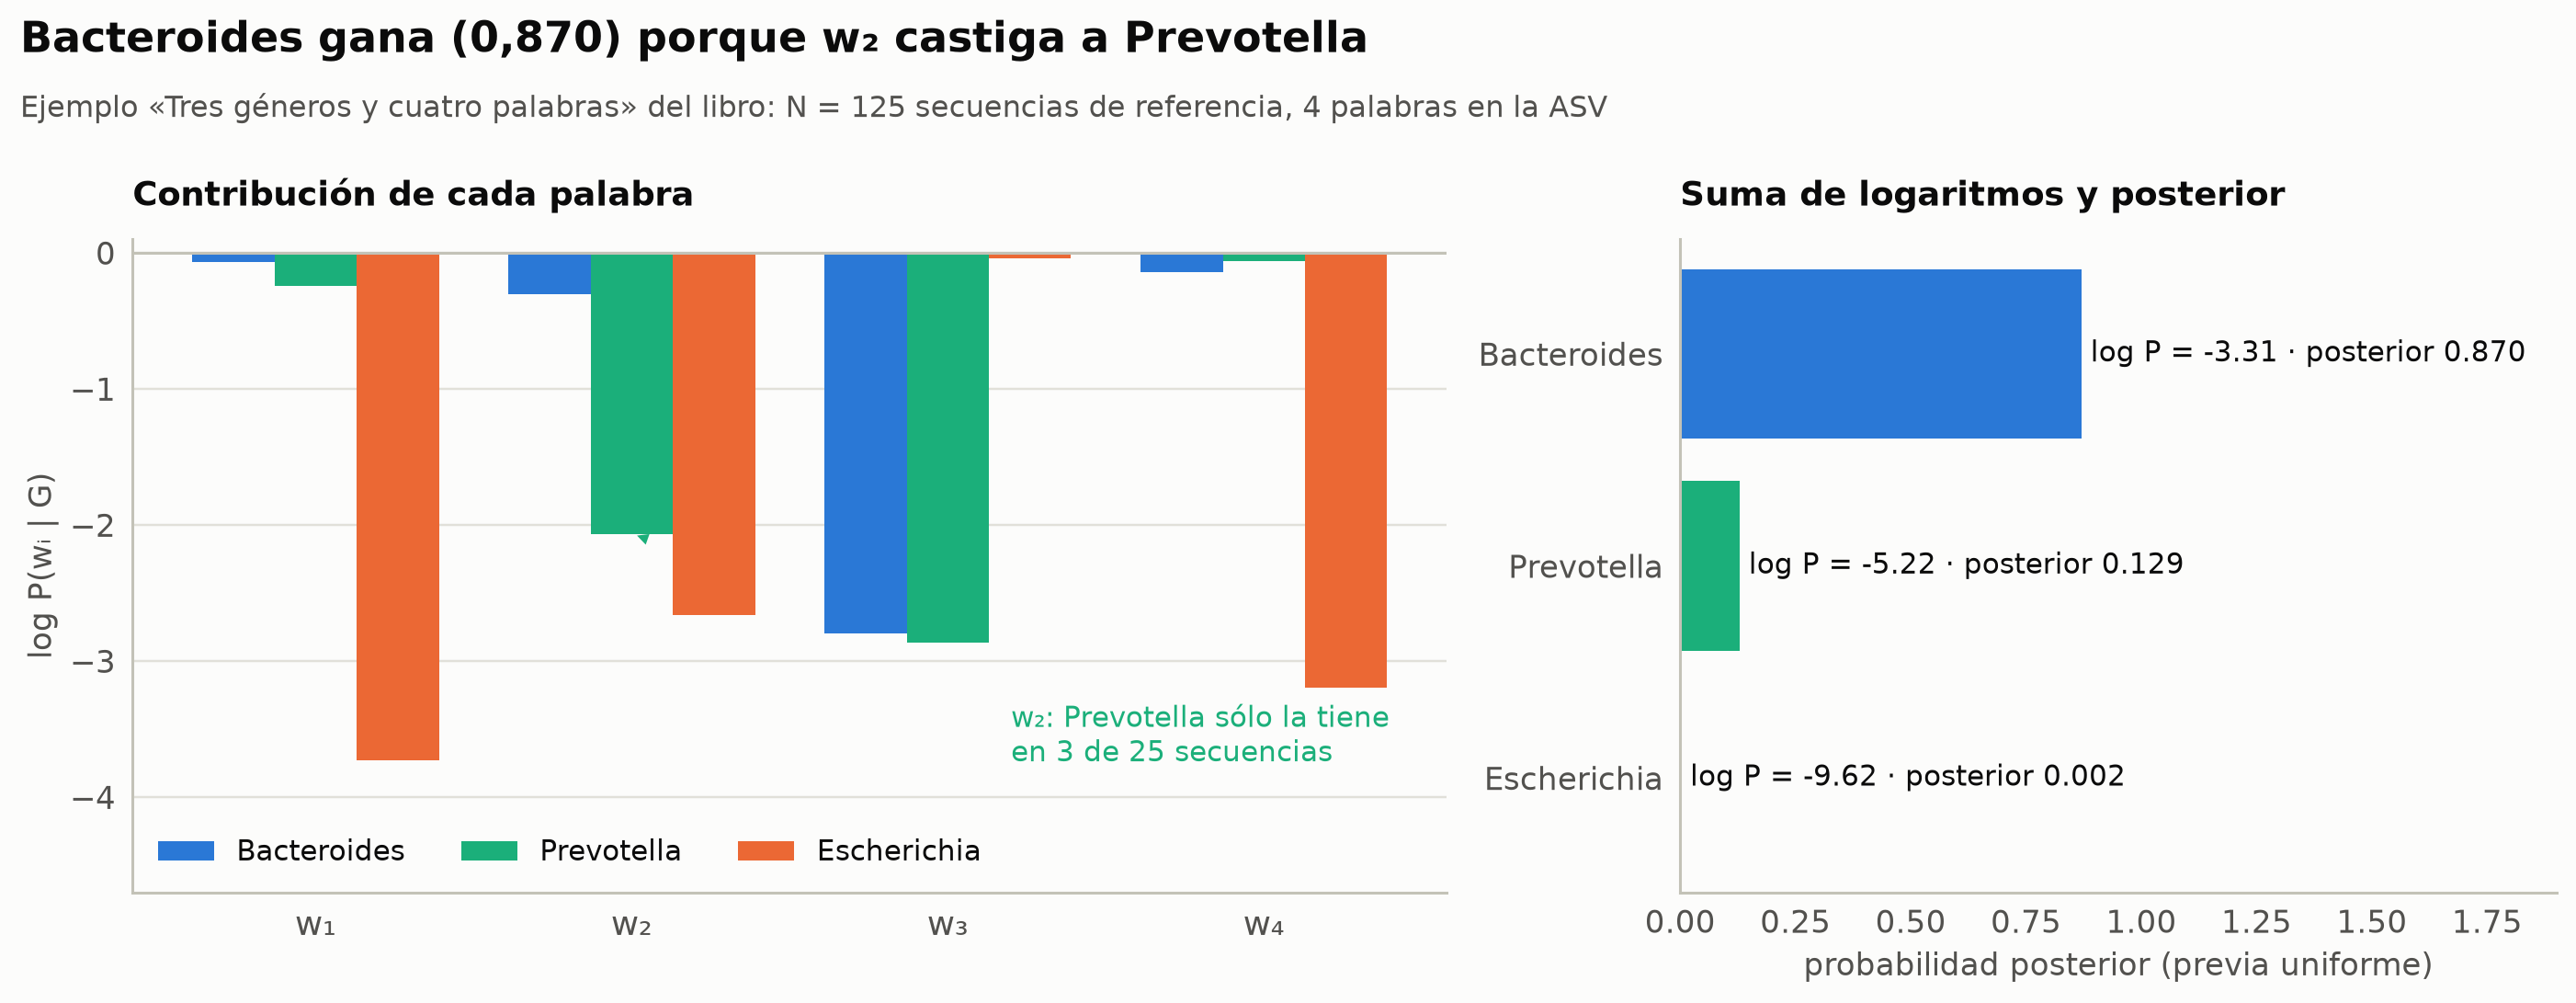

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw=dict(width_ratios=[1.5, 1]))
gen = list(M_toy); cols3 = [ec.BLUE, ec.AQUA, ec.ORANGE]
ax = axes[0]
wbar = 0.26
for k, g in enumerate(gen):
    vals = np.log(toy_tab.loc[g, ["P(w1|G)", "P(w2|G)", "P(w3|G)", "P(w4|G)"]].astype(float).values)
    ax.bar(np.arange(4) + (k - 1) * wbar, vals, width=wbar, color=cols3[k], label=g)
ax.axhline(0, color=ec.BASELINE, lw=1)
ax.set_xticks(range(4)); ax.set_xticklabels(["w₁", "w₂", "w₃", "w₄"], fontsize=12)
ax.set_ylabel("log P(wᵢ | G)")
ax.legend(frameon=False, loc="lower left", ncol=3)
ax.annotate("w₂: Prevotella sólo la tiene\nen 3 de 25 secuencias", (1.0, np.log(0.127)), xytext=(2.2, -3.55),
            textcoords="data", fontsize=10, color=ec.AQUA, va="center", arrowprops=dict(arrowstyle="-|>", color=ec.AQUA))
ax.set_ylim(-4.7, 0.1)
ax.set_title("Contribución de cada palabra", loc="left", fontsize=12)
ax = axes[1]
ax.barh(gen, toy_tab["posterior"], color=cols3)
for i, g in enumerate(gen):
    ax.text(toy_tab.loc[g, "posterior"] + 0.02, i, f"log P = {toy_tab.loc[g, 'log P(S|G)']:.2f} · posterior {toy_tab.loc[g, 'posterior']:.3f}",
            va="center", fontsize=10)
ax.set_xlim(0, 1.9); ax.invert_yaxis(); ax.set_xlabel("probabilidad posterior (previa uniforme)")
ax.grid(axis="y", visible=False)
ax.set_title("Suma de logaritmos y posterior", loc="left", fontsize=12)
ec.fig_title(fig, "Bacteroides gana (0,870) porque w₂ castiga a Prevotella",
             "Ejemplo «Tres géneros y cuatro palabras» del libro: N = 125 secuencias de referencia, 4 palabras en la ASV")
fig.tight_layout()
plt.show()

> 🔎 **Qué observamos.** Se reproducen las cifras del libro: $\log P(S\mid G) = -3{,}31$, $-5{,}22$ y $-9{,}62$, y
> posteriores $0{,}870$, $0{,}129$ y $0{,}002$. *Escherichia* pierde por goleada porque carece de $w_1$, $w_2$ y $w_4$.
> La palabra $w_2$ decide la competencia con *Prevotella*, en la que sólo aparece 3 veces de 25. Con 246 palabras reales
> en lugar de cuatro, las diferencias de log-verosimilitud se vuelven enormes y la posterior es casi siempre ≈ 1: por
> eso la confianza se mide con remuestreo.

### 10.2 El clasificador real

Nuestra referencia es la región V4 (entre 515F y 806R) extraída *in silico* de las ~21 000 secuencias del conjunto de
entrenamiento 18 del RDP, con hasta tres variantes distintas por linaje. Guardamos $m(w, G)$ en una **matriz dispersa**
de $65\,536$ palabras × géneros: la mayoría de las palabras no aparece en la mayoría de los géneros.

In [32]:
refdb = pd.read_csv(io.StringIO(course_text("141_rdp18_v4_reference.tsv.gz")), sep="\t")
K = 8
KLUT = np.full(256, -1, np.int64)
for i, b in enumerate(BASES):
    KLUT[ord(b)] = i

def kmer_set(s, k=K):
    """Índices (0 … 4^k − 1) de las palabras distintas de longitud k de la secuencia s."""
    x = KLUT[np.frombuffer(s.encode(), np.uint8)]
    w = np.zeros(len(x) - k + 1, np.int64)
    for j in range(k):
        w = w * 4 + x[j:len(x) - k + 1 + j]
    return np.unique(w)

lineages = np.array(sorted(refdb.taxonomy.unique())); lin_idx = {g: i for i, g in enumerate(lineages)}
rows_, cols_ = [], []
for tx, s in zip(refdb.taxonomy, refdb.sequence):
    w = kmer_set(s); rows_.append(w); cols_.append(np.full(len(w), lin_idx[tx]))
m_wG = sparse.csr_matrix((np.ones(sum(map(len, rows_))), (np.concatenate(rows_), np.concatenate(cols_))),
                         shape=(4 ** K, len(lineages)))                   # m(w, G)
M_G = np.bincount([lin_idx[t] for t in refdb.taxonomy], minlength=len(lineages)).astype(float)
N_ref = len(refdb); n_wref = np.asarray((m_wG > 0).sum(axis=1)).ravel()
P_w = (n_wref + 0.5) / (N_ref + 1)                                      # P_i de cada palabra
print(f"Referencia: {N_ref:,} secuencias V4 · {len(lineages):,} géneros · matriz m(w,G) con {m_wG.nnz:,} celdas no nulas "
      f"({m_wG.nnz / (m_wG.shape[0] * m_wG.shape[1]):.2%} de la matriz)")

# ¿Cuántas secuencias V4 idénticas comparten géneros distintos? (el techo de resolución)
by_seq = refdb.groupby("sequence").taxonomy.nunique()
print(f"Secuencias V4 presentes en ≥ 2 géneros distintos de la referencia: {(by_seq > 1).sum()}")

rng_boot = np.random.default_rng(2007)     # año de Wang et al.
RANKS = ["domain", "phylum", "class", "order", "family", "genus"]

def classify(seq, nboot=100, return_boot=False):
    w = kmer_set(seq)
    logP = np.log((m_wG[w].toarray() + P_w[w][:, None]) / (M_G + 1)[None, :])   # palabras × géneros
    best = int(np.argmax(logP.sum(0)))
    sub_n = max(1, len(w) // 8)
    boots = np.array([int(np.argmax(logP[rng_boot.choice(len(w), sub_n, replace=False)].sum(0))) for _ in range(nboot)])
    best_lin = lineages[best].split(";")
    boot_lin = [lineages[b].split(";") for b in boots]
    conf = [100 * np.mean([bl[:r + 1] == best_lin[:r + 1] for bl in boot_lin]) for r in range(len(RANKS))]
    out = dict(zip(RANKS, best_lin)); out.update({f"conf_{r}": c for r, c in zip(RANKS, conf)})
    return (out, boots) if return_boot else out

t0 = time.time()
tax_raw = pd.DataFrame([classify(s) for s in seqtab_nc.index], index=seqtab_nc.index)
print(f"Clasificadas {len(tax_raw)} ASVs con 100 réplicas de remuestreo cada una en {time.time() - t0:.1f} s")

Referencia: 5,526 secuencias V4 · 3,041 géneros · matriz m(w,G) con 835,129 celdas no nulas (0.42% de la matriz)
Secuencias V4 presentes en ≥ 2 géneros distintos de la referencia: 103


Clasificadas 154 ASVs con 100 réplicas de remuestreo cada una en 2.6 s


In [33]:
MIN_BOOT = 80
tax = tax_raw.copy()
for r in RANKS:                          # truncar: rango sin confianza suficiente → vacío
    tax.loc[tax[f"conf_{r}"] < MIN_BOOT, r] = ""
for i, r in enumerate(RANKS[1:], 1):     # si un rango superior está vacío, los inferiores también
    tax.loc[tax[RANKS[i - 1]] == "", r] = ""

# Validación con la mock
val = []
for s in mock_asvs.index:
    val.append({"cepa(s) de la mock": ", ".join(mock_hits[s]), "lecturas": int(mock_asvs[s]),
                "género asignado": tax.loc[s, "genus"] or f"(sólo {tax.loc[s, 'family'] or tax.loc[s, 'order']})",
                "mejor género": tax_raw.loc[s, "genus"], "confianza género": round(tax_raw.loc[s, "conf_genus"])})
print(pd.DataFrame(val).to_string(index=False))
print("\nFracción de ASVs asignadas con ≥ 80 % en cada rango:")
print((tax[RANKS] != "").mean().round(2).to_string())
mouse_asv = seqtab_nc.drop(columns="Mock").sum(axis=1) > 0     # ASVs presentes en alguna muestra de ratón
print(f"\nSólo las {mouse_asv.sum()} ASVs de las muestras de ratón:")
print((tax.loc[mouse_asv, RANKS] != "").mean().round(2).to_string())

     cepa(s) de la mock  lecturas         género asignado              mejor género  confianza género
              L.gasseri        35 (sólo Lactobacillaceae)             Lactobacillus                67
S.aureus, S.epidermidis       170          Staphylococcus            Staphylococcus               100
            A.baumannii       140           Acinetobacter             Acinetobacter               100
               H.pylori       119            Helicobacter              Helicobacter               100
        A.odontolyticus       110                Schaalia                  Schaalia                99
         C.beijerinckii       106 (sólo Clostridiaceae_1) Clostridium_sensu_stricto                59
               B.cereus       105       (sólo Bacillales)            Viridibacillus                34
         N.meningitidis        87               Neisseria                 Neisseria                95
             B.vulgatus        73             Bacteroides               Bacteroide

> 🔎 **Qué observamos.** Catorce de las 19 ASVs de la *mock* reciben el género correcto con confianza
> ≥ 80 %. Algunos nombres parecen errores, pero son **cambios de nomenclatura** del RDP 18: *Actinomyces odontolyticus*
> es hoy *Schaalia*, *Rhodobacter sphaeroides* pasó a *Luteovulum*, *Escherichia* y *Shigella* se tratan como un solo
> género (sus V4 son idénticas) y *Clostridium sensu stricto* es el núcleo del antiguo *Clostridium*. Donde la confianza
> baja del 80 % el clasificador **se abstiene** y se queda en un rango superior: *Pseudomonas* comparte casi toda su V4
> con *Azotobacter*, *Bacillus cereus* se confunde con otros Bacillales y *Streptococcus mutans* o *Lactobacillus
> gasseri* tienen vecinos casi idénticos. Prefiere no afirmar a equivocarse: ninguna asignación con ≥ 80 % es incorrecta.
> En las muestras de ratón sólo una cuarta parte de las ASVs llega a género, aunque casi el 90 % llega a familia: el intestino
> murino está lleno de linajes poco representados en las bases de referencia (la familia *Muribaculaceae*, antes "S24-7",
> y muchos *Lachnospiraceae*).

### 10.3 🎬 La confianza por remuestreo, réplica a réplica

Veamos cómo se construye la confianza de una ASV ambigua de la *mock*: en cada réplica se sortea un octavo de sus
palabras (unas 30) y se anota el género ganador.

![Confianza por remuestreo del clasificador bayesiano ingenuo: 100 réplicas con un octavo de las palabras; el porcentaje de votos del género ganador es la confianza](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.1_bootstrap.gif)

*Confianza por remuestreo del clasificador bayesiano ingenuo: 100 réplicas con un octavo de las palabras; el porcentaje de votos del género ganador es la confianza*

In [34]:
amb = min(mock_asvs.index, key=lambda s: tax_raw.loc[s, "conf_genus"])
_, boots = classify(amb, return_boot=True)
names_b = [lineages[b].split(";")[-1] for b in boots]
top = [g for g, _ in collections.Counter(names_b).most_common(5)]
print(f"ASV de la mock ({', '.join(mock_hits[amb])}) · mejor género: {tax_raw.loc[amb, 'genus']} · votos:",
      dict(collections.Counter(names_b).most_common(5)))
steps = list(range(4, 101, 4))
frames_b = steps + [100] * 6
fig, ax = plt.subplots(figsize=(11.5, 4.6))

def update_b(f):
    k = frames_b[f]; ax.clear()
    cnts = collections.Counter(names_b[:k])
    vals = [cnts.get(g, 0) / k * 100 for g in top]
    colors = [ec.BLUE if g == tax_raw.loc[amb, "genus"] else ec.MUTED for g in top]
    ax.barh(top, vals, color=colors, height=0.6)
    for i, v in enumerate(vals):
        ax.text(v + 1, i, f"{v:.0f} %", va="center", fontsize=11)
    ax.axvline(MIN_BOOT, color=ec.RED, ls="--"); ax.text(MIN_BOOT + 1, len(top) - 0.55, "umbral 80 %", color=ec.RED, fontsize=10)
    ax.set_xlim(0, 110); ax.invert_yaxis(); ax.set_xlabel("% de réplicas que votan por el género")
    ax.grid(axis="y", visible=False)
    ax.set_title(f"Réplica {k} de 100 · ASV de la mock ({', '.join(mock_hits[amb])})", loc="left", fontsize=12)
    return []

ec.animate(fig, update_b, frames=len(frames_b), interval=250, name="14.1_bootstrap")

ASV de la mock (B.cereus) · mejor género: Viridibacillus · votos: {'Viridibacillus': 44, 'Lysinibacillus': 22, 'Staphylococcus': 11, 'Peribacillus': 10, 'Planococcus': 8}


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con todas sus palabras, la ASV se asigna a un género concreto; pero cuando sólo se usa un octavo
> de ellas, una fracción apreciable de réplicas vota por otros géneros de Bacillales. El porcentaje se estabiliza tras
> unas pocas decenas de réplicas y queda muy por debajo del 80 %: la asignación se trunca al rango superior en el que sí
> se alcanza (aquí, el orden Bacillales). Observe además que el "mejor" género con todas las palabras ni siquiera es
> *Bacillus*: con una región de 253 nt, la señal que separa géneros vecinos es escasa. Para lecturas cortas, Wang *et al.*
> (2007) observaron que un umbral del 50 % ya da asignaciones fiables a género, y es el valor que usa DADA2 por defecto
> (`minBoot = 50`); el 80 % es la opción conservadora del libro.

### 10.4 ¿Qué cambia en el intestino del ratón tras el destete?

Resumimos la tabla a nivel de **familia** (el rango con mejor asignación en estos datos) y comparamos las muestras
tempranas con las tardías. El gráfico es interactivo: pase el cursor por cada segmento para ver la familia, su
porcentaje, las lecturas y cuántas ASVs la componen.

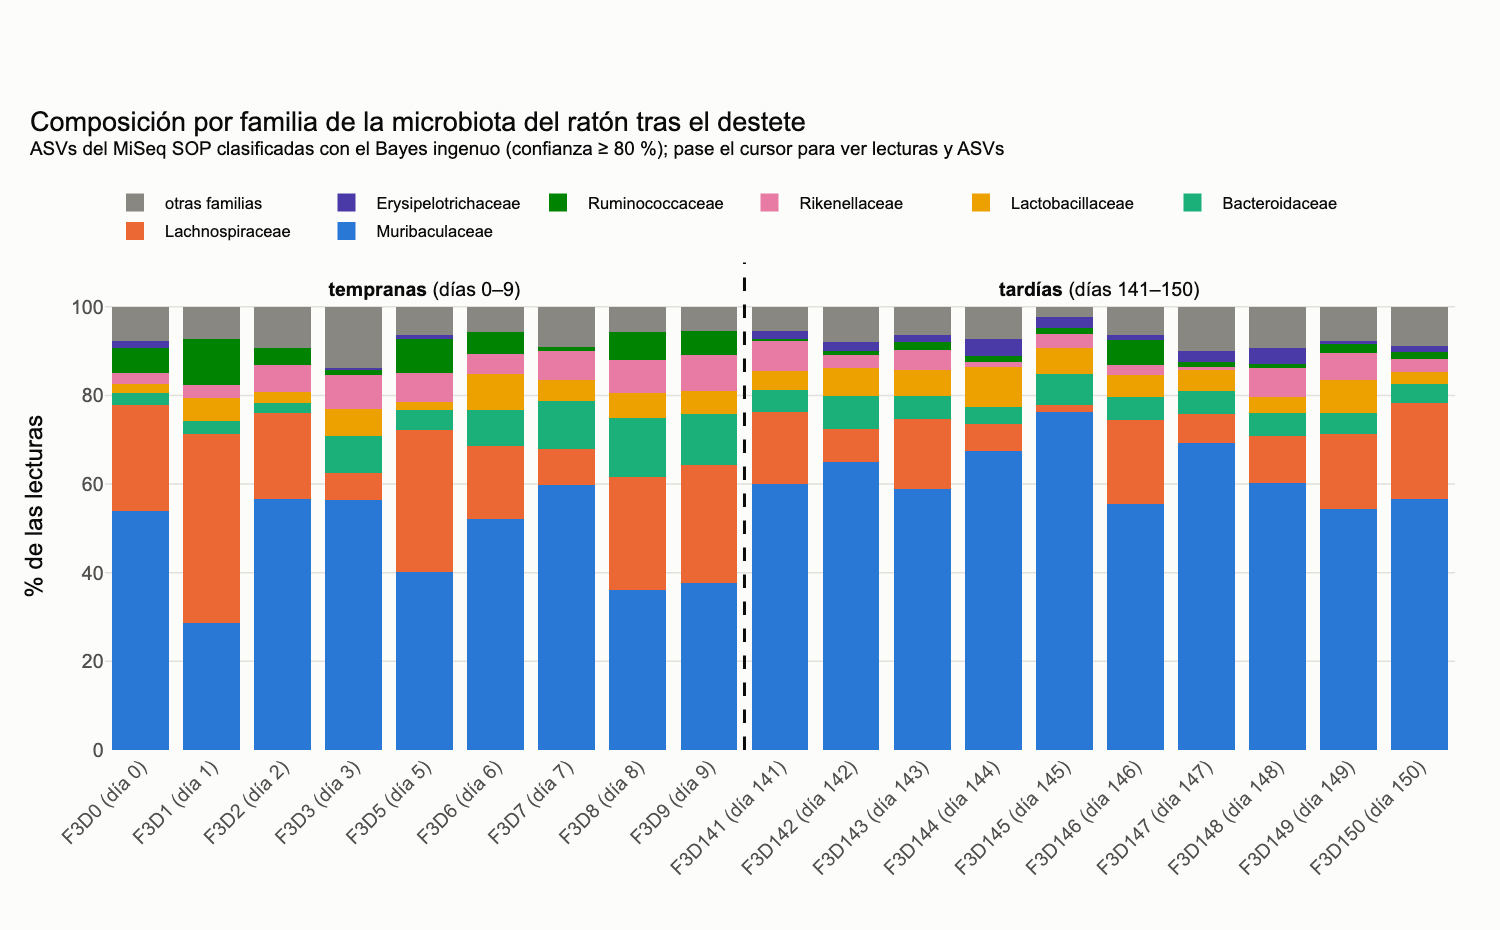

                     temprana (%)  tardía (%)
family                                       
Muribaculaceae               46.8        62.4
Lachnospiraceae              22.4        12.1
Bacteroidaceae                7.2         5.3
Lactobacillaceae              4.6         5.5
Rikenellaceae                 5.8         3.7
Ruminococcaceae               5.1         1.7
Erysipelotrichaceae           0.3         2.1


In [35]:
fam = tax["family"].replace("", np.nan).fillna("sin asignar (< 80 %)")
rel = seqtab_nc.div(seqtab_nc.sum(), axis=1)
fam_rel = rel.groupby(fam).sum()
fam_cnt = seqtab_nc.groupby(fam).sum()
fam_nasv = (seqtab_nc > 0).groupby(fam).sum()
order_s = [s for s in SAMPLES if s != "Mock"]
topfam = fam_rel[order_s].mean(axis=1).sort_values(ascending=False)
keep_f = [f for f in topfam.index if f != "sin asignar (< 80 %)"][:7]
other = [f for f in fam_rel.index if f not in keep_f]
plot_rel = pd.concat([fam_rel.loc[keep_f], fam_rel.loc[other].sum().to_frame("otras familias").T])
plot_cnt = pd.concat([fam_cnt.loc[keep_f], fam_cnt.loc[other].sum().to_frame("otras familias").T])
plot_nasv = pd.concat([fam_nasv.loc[keep_f], fam_nasv.loc[other].sum().to_frame("otras familias").T])
palette = ec.CATEGORICAL[:7] + [ec.MUTED]
labels_x = [f"{s} (día {int(meta.set_index('sample').loc[s, 'dpw'])})" for s in order_s]
figc = go.Figure()
for k, f in enumerate(plot_rel.index):
    figc.add_trace(go.Bar(
        x=labels_x, y=plot_rel.loc[f, order_s] * 100, name=f, marker_color=palette[k],
        customdata=np.stack([plot_cnt.loc[f, order_s], plot_nasv.loc[f, order_s],
                             meta.set_index("sample").loc[order_s, "time"].map({"Early": "temprana", "Late": "tardía"})], axis=1),
        hovertemplate=("<b>" + f + "</b><br>%{x} · muestra %{customdata[2]}<br>%{y:.1f} % de las lecturas "
                       "(%{customdata[0]} lecturas, %{customdata[1]} ASVs)<extra></extra>")))
figc.add_vline(x=8.5, line=dict(color=ec.INK, dash="dash"))
figc.add_annotation(x=4, y=104, text="<b>tempranas</b> (días 0–9)", showarrow=False)
figc.add_annotation(x=13.5, y=104, text="<b>tardías</b> (días 141–150)", showarrow=False)
figc.update_layout(barmode="stack", height=620, margin=dict(t=175, l=70, r=30, b=120),
                   title="Composición por familia de la microbiota del ratón tras el destete<br><sup>ASVs del MiSeq SOP "
                         "clasificadas con el Bayes ingenuo (confianza ≥ 80 %); pase el cursor para ver lecturas y ASVs</sup>",
                   yaxis=dict(title="% de las lecturas", range=[0, 110]), xaxis=dict(tickangle=-45),
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, font=dict(size=11)))
figc.show()
early = [s for s in order_s if meta.set_index("sample").loc[s, "time"] == "Early"]
late = [s for s in order_s if meta.set_index("sample").loc[s, "time"] == "Late"]
cmp_ = pd.DataFrame({"temprana (%)": fam_rel.loc[keep_f, early].mean(axis=1) * 100,
                     "tardía (%)": fam_rel.loc[keep_f, late].mean(axis=1) * 100}).round(1)
print(cmp_.to_string())

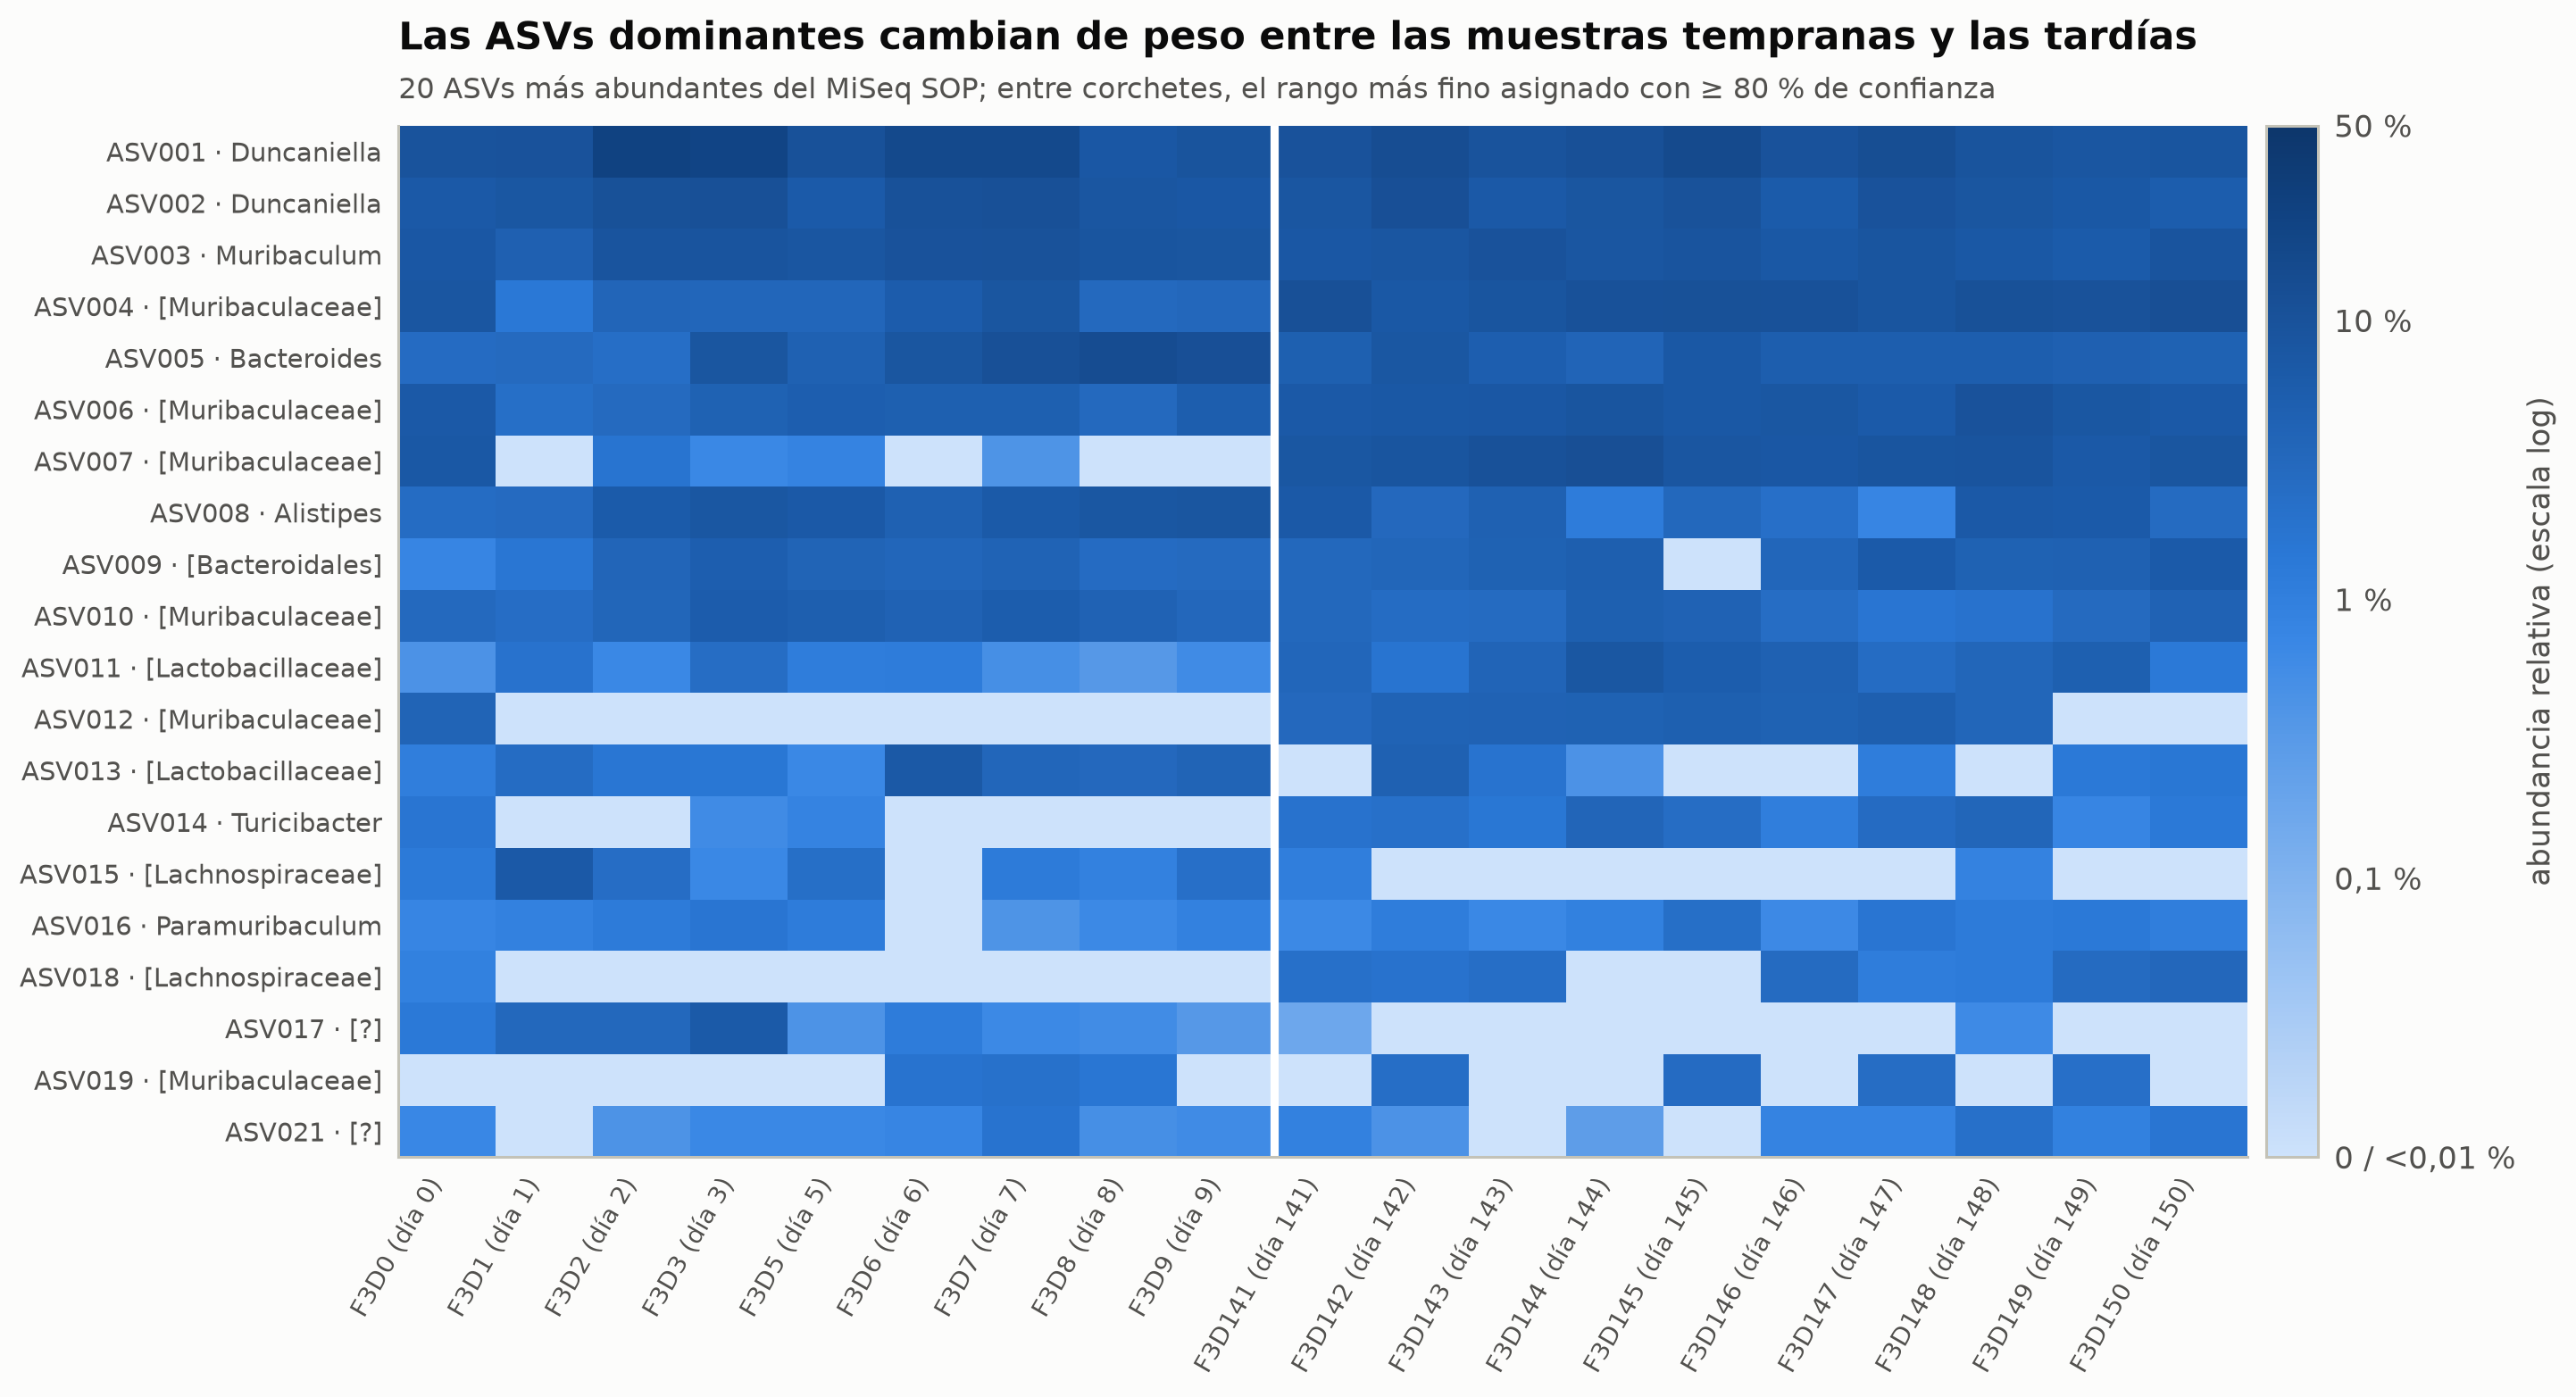

In [36]:
top_asv = seqtab_nc[order_s].div(seqtab_nc[order_s].sum(), axis=1)
top_asv = top_asv.loc[top_asv.mean(axis=1).sort_values(ascending=False).index[:20]]
lab_asv = []
for s in top_asv.index:
    g = tax.loc[s, "genus"] or ("[" + (tax.loc[s, "family"] or tax.loc[s, "order"] or "?") + "]")
    lab_asv.append(f"ASV{list(seqtab_nc.index).index(s) + 1:03d} · {g}")
fig, ax = plt.subplots(figsize=(13, 7))
Z = np.log10(top_asv.values + 1e-4)
im = ax.imshow(Z, aspect="auto", cmap=ec.CMAP_SEQ, vmin=-4, vmax=np.log10(0.5))
ax.set_yticks(range(len(lab_asv))); ax.set_yticklabels(lab_asv, fontsize=9.5)
ax.set_xticks(range(len(order_s))); ax.set_xticklabels(labels_x, rotation=60, ha="right", fontsize=9)
ax.axvline(len(early) - 0.5, color="white", lw=3)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cb.set_ticks([-4, -3, -2, -1, np.log10(0.5)]); cb.set_ticklabels(["0 / <0,01 %", "0,1 %", "1 %", "10 %", "50 %"])
cb.set_label("abundancia relativa (escala log)")
ec.title(ax, "Las ASVs dominantes cambian de peso entre las muestras tempranas y las tardías",
         "20 ASVs más abundantes del MiSeq SOP; entre corchetes, el rango más fino asignado con ≥ 80 % de confianza")
plt.show()

> 🔎 **Qué observamos.** Las dos familias dominantes, *Muribaculaceae* y *Lachnospiraceae*, están en todas las
> muestras, pero su balance cambia: en las muestras tempranas *Muribaculaceae* aporta en promedio menos de la mitad de las
> lecturas y *Lachnospiraceae* alrededor de una quinta parte, con mucha variación de un día a otro (F3D1, F3D8, F3D9);
> en las tardías *Muribaculaceae* supera el 60 %, *Lachnospiraceae* y *Ruminococcaceae* retroceden, y las muestras se
> parecen más entre sí. En el mapa de calor se ven ASVs concretas que aparecen o desaparecen entre periodos (ASV012,
> ASV015, ASV018). ¿Es ese cambio mayor de lo que cabría esperar por azar? Responderlo con rigor exige medidas de
> diversidad y distancias entre
comunidades (Bray-Curtis, UniFrac) y una prueba como PERMANOVA: es el tema de la **Lección 14.2**, que construye su propia
> tabla a partir de todo el corrido y usa la que exportamos a continuación para validarla.

La resolución tiene un techo: una región de 250 nucleótidos contiene pocas docenas de sitios variables entre especies de
un género, y muchas especies (por ejemplo, de *Escherichia*/*Shigella*) comparten secuencias V4 idénticas. La ASV es
exacta, pero un nombre de especie asignado a partir de ella rara vez lo es; para eso hacen falta el gen completo o la
metagenómica *shotgun* (Lección 14.3).

## 11. QIIME 2 y la tabla final para la Lección 14.2

### 11.1 QIIME 2: reproducibilidad por diseño

Todo lo que hemos programado existe, optimizado y probado, en herramientas estándar. **QIIME 2** (Bolyen *et al.*, 2019)
no es un algoritmo sino una plataforma que envuelve decenas de métodos (DADA2, clasificadores, métricas de diversidad,
pruebas estadísticas) bajo una interfaz común. Su rasgo más distintivo es el **registro automático de procedencia**: cada
archivo `.qza` (artefacto) guarda, además de los datos, el historial completo de comandos, parámetros y versiones que lo
produjeron, de modo que cualquier resultado puede rastrearse hasta los FASTQ originales. Los artefactos llevan **tipos
semánticos** que impiden, por ejemplo, pasar una tabla de proporciones (`FeatureTable[RelativeFrequency]`) a un método
que espera conteos enteros (`FeatureTable[Frequency]`).

El flujo equivalente al de esta lección (texto de referencia: instalar QIIME 2 en Colab es lento y no forma parte de la
clase) sería:

```bash
qiime tools import \
  --type 'SampleData[PairedEndSequencesWithQuality]' \
  --input-path manifiesto.tsv \
  --input-format PairedEndFastqManifestPhred33V2 \
  --output-path demux.qza
qiime dada2 denoise-paired \
  --i-demultiplexed-seqs demux.qza \
  --p-trunc-len-f 240 --p-trunc-len-r 160 \
  --p-max-ee-f 2 --p-max-ee-r 2 \
  --o-table tabla.qza \
  --o-representative-sequences asv.qza \
  --o-denoising-stats estadisticas.qza
qiime feature-classifier classify-sklearn \
  --i-classifier silva-515-806-nb-classifier.qza \
  --i-reads asv.qza --o-classification taxonomia.qza
```

| Paso de QIIME 2 | Lo que programamos en esta lección |
|---|---|
| `--p-trunc-len-f/r`, `--p-max-ee-f/r` | sección 7: recorte 240/160 y $\mathrm{EE}\le 2$ |
| `dada2 denoise-paired` (modelo de error, inferencia, unión, quimeras) | secciones 8 y 9 |
| `--o-denoising-stats` | la tabla `track` (lecturas que sobreviven a cada paso) |
| `feature-classifier classify-sklearn` (Bokulich *et al.*, 2018) | sección 10: Bayes ingenuo de 8-mers con confianza |

Elija `--p-trunc-len` mirando el perfil de calidad de **sus** datos y revise las estadísticas de *denoising*: si la unión
de extremos pierde más de la mitad de las lecturas, el recorte fue demasiado agresivo.

### 11.2 Estadísticas de *denoising* y exportación

Guardamos tres archivos que la Lección 14.2 usará como punto de comparación: la **tabla de conteos** ASV × muestra, la **taxonomía**
(con la secuencia exacta de cada ASV y la confianza por rango) y los **metadatos** de las muestras. Los identificadores
`ASV001`, `ASV002`, … siguen el orden de abundancia total. En Colab se escriben en `resultados_141/`; en una copia local
del repositorio, en `data/`. La Lección 14.2 no parte de esta tabla, sino que construye otra a partir del corrido
completo (sólo la lectura 1 recortada a 150 pb, $\mathrm{EE}\le 1$ y una regla de abundancia tipo UNOISE, con unas
2 500–16 000 lecturas por muestra); aquí usamos 1500 pares por muestra y amplicones unidos de 253 nt, por eso las dos
tablas difieren en el número de ASVs aunque ordenan las muestras de forma muy parecida.

        input  filtered  asvs_R1  asvs_R2  merged  nonchim
sample                                                    
F3D0     1500      1363       69       59    1178     1178
F3D1     1500      1354       65       60    1236     1236
F3D2     1500      1387       55       49    1217     1217
F3D3     1500      1392       42       30    1254     1204
F3D5     1500      1364       64       57    1197     1197
F3D6     1500      1390       61       48    1209     1209
F3D7     1500      1398       50       42    1281     1245
F3D8     1500      1378       68       56    1239     1239
F3D9     1500      1396       76       63    1216     1216
F3D141   1500      1363       50       43    1240     1240
F3D142   1500      1373       45       39    1167     1167
F3D143   1500      1385       52       45    1211     1211
F3D144   1500      1346       36       35    1186     1182
F3D145   1500      1357       45       36    1117     1110
F3D146   1500      1366       62       54    1130     11

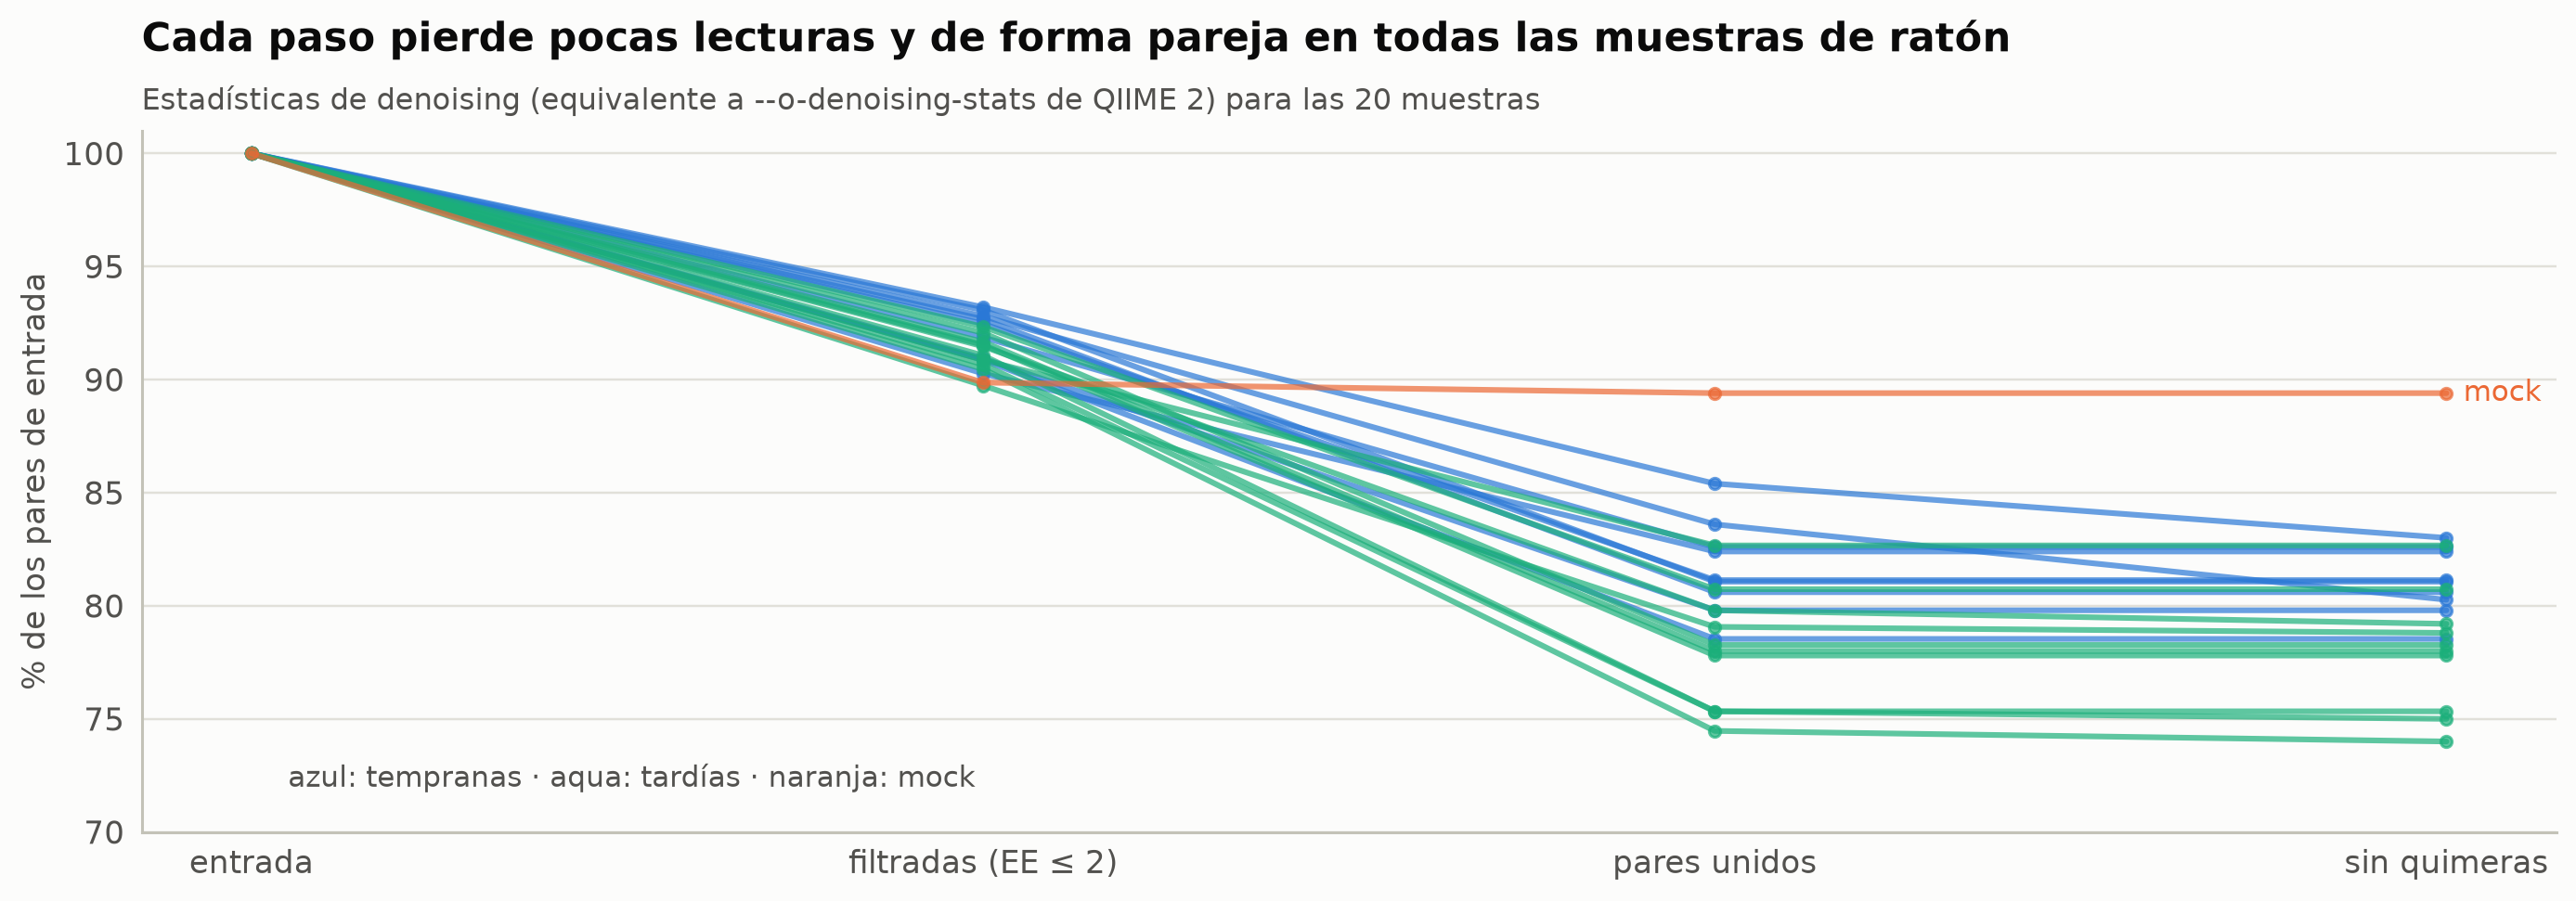

In [37]:
track_out = track.rename(columns={"denoisedF": "asvs_R1", "denoisedR": "asvs_R2"}).copy()
track_out.index.name = "sample"
print(track_out.to_string())
fig, ax = plt.subplots(figsize=(12.5, 4.3))
steps_ = ["input", "filtered", "merged", "nonchim"]
lab_ = {"input": "entrada", "filtered": "filtradas (EE ≤ 2)", "merged": "pares unidos", "nonchim": "sin quimeras"}
for s in SAMPLES:
    col = ec.ORANGE if s == "Mock" else (ec.BLUE if meta.set_index("sample").loc[s, "time"] == "Early" else ec.AQUA)
    ax.plot(range(4), track.loc[s, steps_] / track.loc[s, "input"] * 100, "-o", color=col, alpha=0.7, ms=4)
ax.set_xticks(range(4)); ax.set_xticklabels([lab_[s] for s in steps_])
ax.set_ylabel("% de los pares de entrada"); ax.set_ylim(70, 101)
ec.label_end(ax, 3, track.loc["Mock", "nonchim"] / track.loc["Mock", "input"] * 100, "mock", ec.ORANGE)
ax.text(0.05, 72, "azul: tempranas · aqua: tardías · naranja: mock", color=ec.INK_2, fontsize=10)
ec.title(ax, "Cada paso pierde pocas lecturas y de forma pareja en todas las muestras de ratón",
         "Estadísticas de denoising (equivalente a --o-denoising-stats de QIIME 2) para las 20 muestras")
plt.show()

In [38]:
asv_ids = [f"ASV{k:03d}" for k in range(1, len(seqtab_nc) + 1)]
counts_out = seqtab_nc.copy(); counts_out.index = asv_ids; counts_out.index.name = "asv_id"
counts_out = counts_out[SAMPLES]
tax_out = pd.DataFrame({"asv_id": asv_ids, "sequence": seqtab_nc.index, "length": seqtab_nc.index.str.len(),
                        "total_reads": seqtab_nc.sum(axis=1).values})
for r in RANKS:
    tax_out[r] = tax[r].values
for r in RANKS:
    tax_out[f"conf_{r}"] = tax_raw[f"conf_{r}"].round(0).astype(int).values
tax_out["best_genus"] = tax_raw["genus"].values
tax_out["mock_strain"] = [", ".join(mock_match(s)) for s in seqtab_nc.index]
meta_out = meta.copy()

outdir = os.path.join("..", "data") if os.path.isdir(os.path.join("..", "data")) else "resultados_141"
os.makedirs(outdir, exist_ok=True)
files = {"141_miseqsop_asv_counts.tsv": counts_out, "141_miseqsop_asv_taxonomy.tsv": tax_out.set_index("asv_id"),
         "141_miseqsop_samples.tsv": meta_out.set_index("sample"), "141_miseqsop_track.tsv": track_out}
for fname, df in files.items():
    path = os.path.join(outdir, fname)
    text = df.to_csv(sep="\t")
    status = "nuevo"
    if os.path.exists(path):
        status = "idéntico a la copia del curso" if open(path).read() == text else "actualizado"
    with open(path, "w") as fh:
        fh.write(text)
    print(f"{path:45s} {df.shape[0]:>4} filas × {df.shape[1]:>2} columnas · {status}")
print(counts_out.iloc[:5, :6].to_string())

../data/141_miseqsop_asv_counts.tsv            154 filas × 20 columnas · idéntico a la copia del curso
../data/141_miseqsop_asv_taxonomy.tsv          154 filas × 17 columnas · idéntico a la copia del curso
../data/141_miseqsop_samples.tsv                20 filas ×  2 columnas · idéntico a la copia del curso
../data/141_miseqsop_track.tsv                  20 filas ×  6 columnas · idéntico a la copia del curso
        F3D0  F3D1  F3D2  F3D3  F3D5  F3D6
asv_id                                    
ASV001   109   117   292   253   125   190
ASV002    79    95   131   131    74   124
ASV003    86    58   107   106    94   116
ASV004    92    17    44    41    41    69
ASV005    31    36    28    99    54    99


> 🔎 **Qué observamos.** La tabla final tiene 154 ASVs no quiméricas en 20 muestras (incluida la *mock*, identificable
> con la columna `time` de los metadatos). Cada ASV lleva su secuencia exacta: si otro estudio usa
> los mismos cebadores, sus ASVs se pueden comparar con las nuestras **por identidad de secuencia**, sin reagrupar nada.
> Esa es la ventaja de reutilización que defendían Callahan, McMurdie y Holmes (2017).

> 💡 **Idea clave.** Una OTU es un promedio de secuencias parecidas; una ASV es una secuencia exacta que un modelo de error
> no puede explicar como ruido. La segunda es más precisa, reproducible entre estudios y reutilizable.

## ✍️ Ejercicios

**Ejercicio 1 — El umbral depende del padre.** Con la función `log10_pA` del libro, calcule la abundancia umbral a 1, 2
y 3 nucleótidos para centros de $n_i = 500$, $5000$ y $50\,000$ lecturas ($L = 250$, $e = 0{,}002$). ¿Qué regla simple
describe cómo cambia el umbral a 1 nt con $n_i$? Explique por qué una variante real a 1 nt de un taxón dominante es mucho
más difícil de detectar que una a 1 nt de un taxón raro.

**Ejercicio 2 — OTUs al 99 %.** Repita el agrupamiento voraz de la *mock* con $d_{\max} = \lfloor 0{,}01 \times 240
\rfloor = 2$. ¿Cuántas OTUs obtiene? ¿Cuántas son espurias? ¿Mejora o empeora respecto al 97 %?

**Ejercicio 3 — Sensibilidad a $\Omega_A$.** Cambie `OMEGA_A` a $-10$ y a $-80$ (en $\log_{10}$) y vuelva a inferir las ASVs
de R1 en la *mock* y en `F3D0` con el modelo de error aprendido. ¿Cuántas ASVs aparecen en cada caso? ¿Cuál de las dos
muestras es más sensible al umbral y por qué?

**Ejercicio 4 — Número de copias.** Suponga que las tres familias más abundantes de las muestras tardías tienen, en
promedio, 5, 2 y 7 copias del operón ribosómico. Corrija las abundancias relativas medias por el número de copias y
renormalice. ¿Cambia el orden de las familias?

In [39]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
res1 = pd.DataFrame({n_i: [threshold_abundance(n_i, d) for d in (1, 2, 3)] for n_i in (500, 5000, 50000)},
                    index=["d = 1", "d = 2", "d = 3"])
res1.columns = [f"n_i = {c:,}" for c in res1.columns]
print(res1.to_string())
print("\nA 1 nt, μ = n_i·λ crece proporcionalmente a n_i: el umbral crece aproximadamente como μ + algo más que")
print("unas pocas desviaciones típicas. Una variante a 1 nt de un taxón dominante compite con muchas copias de error")
print("esperadas; la misma variante junto a un taxón raro se distingue con pocas lecturas.")

       n_i = 500  n_i = 5,000  n_i = 50,000
d = 1         25           43           106
d = 2         10           12            16
d = 3          7            8             9

A 1 nt, μ = n_i·λ crece proporcionalmente a n_i: el umbral crece aproximadamente como μ + algo más que
unas pocas desviaciones típicas. Una variante a 1 nt de un taxón dominante compite con muchas copias de error
esperadas; la misma variante junto a un taxón raro se distingue con pocas lecturas.


In [40]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
U_, cnt_, _, _, _ = otu_res["Mock"]
c99, l99 = greedy_otus(U_, dmax=2)
size99 = np.bincount(l99, weights=cnt_).astype(int)
real99 = np.array([len(mock_match(decode(U_[c]))) > 0 for c in c99])
print(f"99 %: {len(c99)} OTUs · {real99.sum()} con centroide de una cepa real · {(~real99).sum()} espurias "
      f"({(size99[~real99] == 1).sum()} de una sola lectura)")
print(f"97 %: {len(otu_res['Mock'][2])} OTUs")
print("Al 99 % el radio es menor: los errores a 3–7 nt ya no se absorben y aparecen aún más OTUs espurias.")

99 %: 168 OTUs · 19 con centroide de una cepa real · 149 espurias (146 de una sola lectura)
97 %: 67 OTUs
Al 99 % el radio es menor: los errores a 3–7 nt ya no se absorben y aparecen aún más OTUs espurias.


In [41]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
OMEGA_SAVE = OMEGA_A
rows3 = []
for om in (-10, -40, -80):
    OMEGA_A = om
    for s in ("Mock", "F3D0"):
        U_, cnt_, Qm_, _ = derep["F"][s]
        rows3.append({"log10 Ω_A": om, "muestra": s, "ASVs": len(dada(U_, cnt_, Qm_, ERR["F"])[0])})
OMEGA_A = OMEGA_SAVE
print(pd.DataFrame(rows3).pivot(index="muestra", columns="log10 Ω_A", values="ASVs").to_string())
print("La mock apenas cambia: sus cepas son muy abundantes y distantes entre sí. F3D0 tiene muchas variantes raras")
print("y cercanas, cuyo valor p está cerca del umbral: es la muestra natural la que depende de Ω_A.")

log10 Ω_A  -80  -40  -10
muestra                 
F3D0        58   69   80
Mock        19   19   22
La mock apenas cambia: sus cepas son muy abundantes y distantes entre sí. F3D0 tiene muchas variantes raras
y cercanas, cuyo valor p está cerca del umbral: es la muestra natural la que depende de Ω_A.


In [42]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
top3 = cmp_["tardía (%)"].sort_values(ascending=False).index[:3]
copies_ = pd.Series([5, 2, 7], index=top3)
raw = cmp_.loc[top3, "tardía (%)"]
corr = (raw / copies_) / (raw / copies_).sum() * 100
print(pd.DataFrame({"copias": copies_, "% de genes": raw.round(1),
                    "% de células (renormalizado entre las 3)": corr.round(1)}).to_string())
print("La familia con 2 copias casi triplica su peso y la de 7 lo pierde; aquí el orden se mantiene, pero las")
print("distancias entre familias cambian mucho: con otros números de copias el orden podría invertirse.")

                  copias  % de genes  % de células (renormalizado entre las 3)
family                                                                        
Muribaculaceae         5        62.4                                      64.6
Lachnospiraceae        2        12.1                                      31.3
Lactobacillaceae       7         5.5                                       4.1
La familia con 2 copias casi triplica su peso y la de 7 lo pierde; aquí el orden se mantiene, pero las
distancias entre familias cambian mucho: con otros números de copias el orden podría invertirse.


## 📌 Resumen

* El **ARNr 16S** combina regiones conservadas (donde se unen los cebadores) con nueve regiones **hipervariables**
  (V1–V9) que distinguen linajes. Lo medimos: la entropía real de 200 familias tiene picos exactamente en V1–V9.
* **Ningún cebador es universal**: el 515F original no reconoce a Thaumarchaeota; 515F-Y sí. Nunca compare abundancias
  obtenidas con cebadores distintos.
* El genoma de *E. coli* K-12 tiene **7 copias** del 16S que difieren en V1–V2 y V6 pero son idénticas en V4: las
  abundancias 16S son de **genes**, no de células, y un organismo puede aportar más de una variante.
* Las **OTUs al 97 %** ($\lfloor 0{,}03 \times 253 \rfloor = 7$ diferencias) funden variantes reales e inventan unidades
  espurias: en la *mock*, casi el doble de OTUs que cepas con lecturas filtradas, y el triple sin filtrar.
* DADA2 modela los errores: $\lambda_{ji} = \prod_\ell p(j(\ell)\mid i(\ell), q_j(\ell))$ y declara real una secuencia
  si su abundancia es increíble bajo Poisson($n_i\lambda_{ji}$): $p_A < \Omega_A = 10^{-40}$. A 1 nt de un centro de
  5000 lecturas hacen falta **43** copias; a 4 nt, sólo **6**.
* Antes de inferir se filtra por **errores esperados** $\mathrm{EE} = \sum 10^{-q/10} \le 2$, tras recortar las colas
  según el perfil de calidad (240/160 en MiSeq 2 × 250, V4).
* El modelo de error se **aprende** de los datos (transiciones A↔G y C↔T más frecuentes que lo nominal); las ASVs de R1
  y R2 se **unen** por su solapamiento (147 nt = 240 + 160 − 253), y las **bimeras** se eliminan buscando un prefijo y un
  sufijo exactos de dos padres más abundantes.
* En la *mock*, todas nuestras ASVs coinciden **exactamente** con secuencias de la referencia.
* El **Bayes ingenuo de 8-mers** asigna el género que maximiza $\sum \log P(w_i\mid G)$ y mide la confianza con 100
  réplicas de un octavo de las palabras; por debajo del 80 % se trunca al rango superior.
* **QIIME 2** empaqueta este flujo con procedencia registrada; nuestra tabla ASV × muestra, la taxonomía y los
  metadatos sirven a la Lección 14.2 para validar la tabla que construye con el corrido completo.

## 📚 Para profundizar

* Woese, C. R. & Fox, G. E. (1977). Phylogenetic structure of the prokaryotic domain: The primary kingdoms. *PNAS* 74(11):
  5088–5090. https://doi.org/10.1073/pnas.74.11.5088
* Caporaso, J. G. *et al.* (2011). Global patterns of 16S rRNA diversity at a depth of millions of sequences per sample.
  *PNAS* 108(suppl. 1): 4516–4522. https://doi.org/10.1073/pnas.1000080107
* Kozich, J. J., Westcott, S. L., Baxter, N. T., Highlander, S. K. & Schloss, P. D. (2013). Development of a dual-index
  sequencing strategy and curation pipeline for analyzing amplicon sequence data on the MiSeq Illumina sequencing
  platform. *Applied and Environmental Microbiology* 79(17): 5112–5120. https://doi.org/10.1128/AEM.01043-13 (origen de los datos)
* Callahan, B. J. *et al.* (2016). DADA2: High-resolution sample inference from Illumina amplicon data. *Nature Methods*
  13(7): 581–583. https://doi.org/10.1038/nmeth.3869
* Callahan, B. J., McMurdie, P. J. & Holmes, S. P. (2017). Exact sequence variants should replace operational taxonomic
  units in marker-gene data analysis. *The ISME Journal* 11(12): 2639–2643. https://doi.org/10.1038/ismej.2017.119
* Edgar, R. C., Haas, B. J., Clemente, J. C., Quince, C. & Knight, R. (2011). UCHIME improves sensitivity and speed of
  chimera detection. *Bioinformatics* 27(16): 2194–2200. https://doi.org/10.1093/bioinformatics/btr381
* Wang, Q., Garrity, G. M., Tiedje, J. M. & Cole, J. R. (2007). Naïve Bayesian classifier for rapid assignment of rRNA
  sequences into the new bacterial taxonomy. *Applied and Environmental Microbiology* 73(16): 5261–5267.
  https://doi.org/10.1128/AEM.00062-07
* Cole, J. R. *et al.* (2014). Ribosomal Database Project: data and tools for high throughput rRNA analysis. *Nucleic
  Acids Research* 42(D1): D633–D642. https://doi.org/10.1093/nar/gkt1244
* Quast, C. *et al.* (2013). The SILVA ribosomal RNA gene database project: Improved data processing and web-based tools.
  *Nucleic Acids Research* 41(D1): D590–D596. https://doi.org/10.1093/nar/gks1219
* Parada, A. E., Needham, D. M. & Fuhrman, J. A. (2016). Every base matters: assessing small subunit rRNA primers for
  marine microbiomes with mock communities, time series and global field samples. *Environmental Microbiology* 18(5):
  1403–1414. https://doi.org/10.1111/1462-2920.13023
* Apprill, A., McNally, S., Parsons, R. & Weber, L. (2015). Minor revision to V4 region SSU rRNA 806R gene primer greatly
  increases detection of SAR11 bacterioplankton. *Aquatic Microbial Ecology* 75(2): 129–137. https://doi.org/10.3354/ame01753
* Walters, W. *et al.* (2016). Improved bacterial 16S rRNA gene (V4 and V4-5) and fungal internal transcribed spacer
  marker gene primers for microbial community surveys. *mSystems* 1(1): e00009-15. https://doi.org/10.1128/mSystems.00009-15
* Bolyen, E. *et al.* (2019). Reproducible, interactive, scalable and extensible microbiome data science using QIIME 2.
  *Nature Biotechnology* 37(8): 852–857. https://doi.org/10.1038/s41587-019-0209-9
* Bokulich, N. A. *et al.* (2018). Optimizing taxonomic classification of marker-gene amplicon sequences with QIIME 2's
  q2-feature-classifier plugin. *Microbiome* 6: 90. https://doi.org/10.1186/s40168-018-0470-z

In [43]:
print(f"⏱️ Tiempo total de la lección: {time.time() - T_START:.0f} s")

⏱️ Tiempo total de la lección: 80 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)